# MVS-MCMC $\chi_\text{dis}$ susceptibility collapse with bootstrap

本 notebook 仅处理 $\chi_\text{dis}$：由 disorder-level $\langle |m| \rangle_{\mathrm{th}, i}$ 数据按 $\chi_\text{dis} = L^D\left(\overline{\langle |m| \rangle^2} - \overline{\langle |m| \rangle}^2\right)$ 重建，jackknife 估计单点误差，非参数 bootstrap 误差分析，NSA 数据坍缩与临界指数估计。


In [1]:
import ast
import math
import os
import random
import warnings
from pathlib import Path

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.ticker import MaxNLocator

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
except Exception as exc:
    raise RuntimeError(
        '无法导入 torch。请切换到支持 PyTorch 的 Python 内核后再运行本 notebook。'
    ) from exc

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning)
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

FIGURES_DIR = Path('./MIS-graph/mvs-mcmc-order-parameter-bootstrap')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.major.size'] = 6.0
plt.rcParams['ytick.major.size'] = 6.0
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2
plt.rcParams['xtick.minor.size'] = 3.0
plt.rcParams['ytick.minor.size'] = 3.0
plt.rcParams['xtick.minor.width'] = 0.8
plt.rcParams['ytick.minor.width'] = 0.8
plt.rcParams['legend.frameon'] = False

def build_dimensioned_figure_filename(filename):
    filename = str(filename)
    base_name, ext = os.path.splitext(filename)
    dimension_token = f'd-{DIMENSION}'
    if dimension_token not in Path(base_name).name:
        base_name = f'{base_name}_{dimension_token}'
    return f'{base_name}{ext}'

def save_fig(fig, filename, output_dir=FIGURES_DIR):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    resolved_filename = build_dimensioned_figure_filename(filename)
    base_name, ext = os.path.splitext(resolved_filename)
    valid_extensions = {'.png', '.pdf', '.svg', '.jpg', '.jpeg', '.eps', '.tif', '.tiff'}

    if ext.lower() not in valid_extensions:
        fig.savefig(output_dir / f'{base_name}.pdf', bbox_inches='tight', dpi=plt.rcParams['figure.dpi'])
        fig.savefig(output_dir / f'{base_name}.png', bbox_inches='tight', dpi=plt.rcParams['figure.dpi'])
    else:
        fig.savefig(output_dir / resolved_filename, bbox_inches='tight', dpi=plt.rcParams['figure.dpi'])

print('Imports and plotting config ready.')

Imports and plotting config ready.


## User Parameters

如果自动窗口不理想，可以分别在 `FIT_RHO_WINDOWS` 和 `PLOT_RHO_WINDOWS` 中为 `|R|` 与 $\chi_\text{dis}$ 手动指定区间 `[rho_min, rho_max]`。

- `FIT_RHO_WINDOWS`: 控制真正参与拟合的数据范围。
- `PLOT_RHO_WINDOWS`: 控制原始图和坍缩图显示的数据范围。
- 两者写成 `None` 时，仍然使用自动找峰值再加半宽度的方式。

In [2]:
DIMENSION = 3
DATA_ROOT = Path('./data/MVS-MCMC')
PARAMETER_FILE = DATA_ROOT / f'parameter-d-{DIMENSION}.txt'
STAT_FILE = DATA_ROOT / f'R_mcmc_stat-d-{DIMENSION}.txt'
ABSR_FILE = DATA_ROOT / f'absR_thermal-d-{DIMENSION}.txt'


SEED = 1234
PREFERRED_TORCH_DEVICE = 'auto'

FULL_FIT_EPOCHS = 3000
FULL_FIT_STARTS = 3
BOOTSTRAP_REPEATS = 500
BOOTSTRAP_FIT_EPOCHS = FULL_FIT_EPOCHS
BOOTSTRAP_FIT_STARTS = 2
BOOTSTRAP_POINT_SAMPLE_SIZE = None

MODEL_LR = 1e-3
TRANSFORM_LR = 1e-2
USE_STEP_LR_DECAY = False
LR_DECAY_GAMMA = 0.5
LR_DECAY_STEP_SIZE = None
MLP_HIDDEN_SIZES = [4, 4]
LOSS_MODE = 'gaussian_nll'
SHOW_TQDM = True
TQDM_LEAVE = False

L_VALUES_FOR_FIT = None
L_MIN = None
L_MAX = None

NSA_CACHE_FILE_TEMPLATE = DATA_ROOT / f'nsa-chi-best-fit-{{tag}}-d={DIMENSION}-cache.pt'
LOSS_PREVIEW_CACHE_FILE_TEMPLATE = DATA_ROOT / f'nsa-chi-loss-preview-{{tag}}-d={DIMENSION}-cache.pt'
ABSR_LOOKUP_CACHE_FILE = DATA_ROOT / f'nsa-chi-bootstrap-lookup-d={DIMENSION}-cache.pt'
FORCE_RECOMPUTE_NSA = False
FORCE_RECOMPUTE_LOSS_PREVIEW = False
FORCE_REBUILD_ABSR_LOOKUP_CACHE = False

FONT_SIZE_TITLE = 16
FONT_SIZE_AXIS_LABEL = 20
FONT_SIZE_TICK_LABEL = 14
FONT_SIZE_LEGEND = 12
LINE_WIDTH = 2
MARKER_SIZE = 4
CAP_SIZE = 3
SHOW_LEGEND_FRAME = False
USE_COLLAPSE_COLORBAR = False

plt.rcParams['xtick.labelsize'] = FONT_SIZE_TICK_LABEL
plt.rcParams['ytick.labelsize'] = FONT_SIZE_TICK_LABEL
plt.rcParams['axes.labelsize'] = FONT_SIZE_AXIS_LABEL
plt.rcParams['legend.fontsize'] = FONT_SIZE_LEGEND
plt.rcParams['legend.frameon'] = SHOW_LEGEND_FRAME

FIT_WINDOW_HALF_WIDTH = {
    'chi_dis': 0.010,
}
PLOT_WINDOW_HALF_WIDTH = {
    'chi_dis': 0.015,
}
if DIMENSION == 2:
    FIT_RHO_WINDOWS = {
        'chi_dis': (0.08, 0.16),
    }
    PLOT_RHO_WINDOWS = {
        'chi_dis': (0.08, 0.16),
    }
if DIMENSION == 3:
    FIT_RHO_WINDOWS = {
        'chi_dis': (0.12, 0.2),
    }
    PLOT_RHO_WINDOWS = {
        'chi_dis': (0.12, 0.2),
    }


OBSERVABLE_SPECS = {
    'chi_dis': {
        'column': 'chi_dis_abs',
        'error_column': 'chi_dis_abs_sem',
        'sign': 'negative',
        'ratio_label': r'\gamma/\nu',
        'physical_label': r'\gamma',
        'raw_label': r'\chi_{\mathrm{dis}}',
        'collapse_label': r'\chi_{\mathrm{dis}}L^{-\gamma/\nu}',
        'save_tag': 'chi_dis',
    },
}

if PREFERRED_TORCH_DEVICE == 'auto':
    resolved_device = 'cuda' if torch.cuda.is_available() else 'cpu'
elif PREFERRED_TORCH_DEVICE == 'cuda' and (not torch.cuda.is_available()):
    resolved_device = 'cpu'
else:
    resolved_device = PREFERRED_TORCH_DEVICE
TORCH_DEVICE = torch.device(resolved_device)
torch.set_num_threads(max(1, min(4, torch.get_num_threads())))

display({
    'device': str(TORCH_DEVICE),
    'full_fit_epochs': FULL_FIT_EPOCHS,
    'full_fit_starts': FULL_FIT_STARTS,
    'bootstrap_repeats': BOOTSTRAP_REPEATS,
    'bootstrap_fit_epochs': BOOTSTRAP_FIT_EPOCHS,
    'bootstrap_fit_starts': BOOTSTRAP_FIT_STARTS,
    'loss_mode': LOSS_MODE,
    'fit_rho_windows': FIT_RHO_WINDOWS,
    'plot_rho_windows': PLOT_RHO_WINDOWS,
    'force_recompute_nsa': FORCE_RECOMPUTE_NSA,
    'force_recompute_loss_preview': FORCE_RECOMPUTE_LOSS_PREVIEW,
    'force_rebuild_absr_lookup_cache': FORCE_REBUILD_ABSR_LOOKUP_CACHE,
})

{'device': 'cuda',
 'full_fit_epochs': 3000,
 'full_fit_starts': 3,
 'bootstrap_repeats': 500,
 'bootstrap_fit_epochs': 3000,
 'bootstrap_fit_starts': 2,
 'loss_mode': 'gaussian_nll',
 'fit_rho_windows': {'chi_dis': (0.12, 0.2)},
 'plot_rho_windows': {'chi_dis': (0.12, 0.2)},
 'force_recompute_nsa': False,
 'force_recompute_loss_preview': False,
 'force_rebuild_absr_lookup_cache': False}

## 参数设置2

In [3]:
DEFAULT_OBSERVABLE_TRAINING_CONFIG = {
    'model_lr': MODEL_LR,
    'transform_lr': TRANSFORM_LR,
    'mlp_hidden_sizes': list(MLP_HIDDEN_SIZES),
    'loss_mode': LOSS_MODE,
    'use_step_lr_decay': USE_STEP_LR_DECAY,
    'lr_decay_gamma': LR_DECAY_GAMMA,
    'lr_decay_step_size': LR_DECAY_STEP_SIZE,
    'full_fit_epochs': FULL_FIT_EPOCHS,
    'full_fit_starts': FULL_FIT_STARTS,
    'bootstrap_repeats': BOOTSTRAP_REPEATS,
    'bootstrap_fit_epochs': BOOTSTRAP_FIT_EPOCHS,
    'bootstrap_fit_starts': BOOTSTRAP_FIT_STARTS,
    'preview_fit_epochs': None,
}

OBSERVABLE_TRAINING_CONFIGS = {
    'chi_dis': {
        'model_lr': 1e-3,
        'transform_lr': 1e-2,
        'mlp_hidden_sizes': [16,16,16,16],
    },
}

COLLAPSE_INSET_WIDTH_RATIO = {
    'chi_dis': 0.45,
}
COLLAPSE_INSET_HEIGHT_RATIO = {
    'chi_dis': 0.55,
}
COLLAPSE_INSET_RIGHT_MARGIN = {
    'chi_dis': 0.0,
}
COLLAPSE_INSET_TOP_MARGIN = {
    'chi_dis': 0.0,
}

display({
    'default_observable_training_config': DEFAULT_OBSERVABLE_TRAINING_CONFIG,
    'observable_training_configs': OBSERVABLE_TRAINING_CONFIGS,
    'collapse_inset_layout': {
        observable: {
            'width_ratio': COLLAPSE_INSET_WIDTH_RATIO[observable],
            'height_ratio': COLLAPSE_INSET_HEIGHT_RATIO[observable],
            'right_margin': COLLAPSE_INSET_RIGHT_MARGIN[observable],
            'top_margin': COLLAPSE_INSET_TOP_MARGIN[observable],
        }
        for observable in OBSERVABLE_SPECS
    },
})

{'default_observable_training_config': {'model_lr': 0.001,
  'transform_lr': 0.01,
  'mlp_hidden_sizes': [4, 4],
  'loss_mode': 'gaussian_nll',
  'use_step_lr_decay': False,
  'lr_decay_gamma': 0.5,
  'lr_decay_step_size': None,
  'full_fit_epochs': 3000,
  'full_fit_starts': 3,
  'bootstrap_repeats': 500,
  'bootstrap_fit_epochs': 3000,
  'bootstrap_fit_starts': 2,
  'preview_fit_epochs': None},
 'observable_training_configs': {'chi_dis': {'model_lr': 0.001,
   'transform_lr': 0.01,
   'mlp_hidden_sizes': [16, 16, 16, 16]}},
 'collapse_inset_layout': {'chi_dis': {'width_ratio': 0.45,
   'height_ratio': 0.55,
   'right_margin': 0.0,
   'top_margin': 0.0}}}

In [4]:
import hashlib
import json
from datetime import datetime, timezone
from typing import Any

CACHE_VERSION = 2
BASE_COLUMNS_NO_SEM = [
    'd', 'L', 'W', 'rho', 'N_samples', 'N_thermal', 'mean_sweeps', 'sweeps_std',
    'dis_mR', 'dis_mAbsR', 'dis_mR2', 'dis_mR3', 'dis_mAbsR3', 'dis_mR4', 'q_EA',
    'dis_mAbsR_sq', 'dis_mR_p4', 'dis_mAbsR_p4', 'dis_mR2_sq',
    'chi_th_abs', 'chi_dis_abs', 'chi_tot_abs', 'chi_th_R', 'chi_dis_R', 'chi_tot_R',
    'U4', 'U_EA', 'U_EA_abs', 'U22', 'acf_probe_warn_count', 'acf_probe_warn_frac'
]
COLUMNS_WITH_SEM = [
    'd', 'L', 'W', 'rho', 'N_samples', 'N_thermal', 'mean_sweeps', 'sweeps_std',
    'dis_mR', 'dis_mAbsR', 'dis_mR2', 'dis_mR3', 'dis_mAbsR3', 'dis_mR4', 'q_EA',
    'dis_mAbsR_sq', 'dis_mR_p4', 'dis_mAbsR_p4', 'dis_mR2_sq',
    'chi_th_abs', 'chi_dis_abs', 'chi_tot_abs', 'chi_tot_abs_sem_jk', 'chi_th_R', 'chi_dis_R',
    'chi_tot_R', 'U4', 'U_EA', 'U_EA_abs', 'U22', 'acf_probe_warn_count', 'acf_probe_warn_frac'
]

FIT_RESULT_SKIP_KEYS = {'dataset', 'model', 'collapsed'}

def _normalize_for_json(value: Any) -> Any:
    if isinstance(value, dict):
        return {
            str(key): _normalize_for_json(val)
            for key, val in sorted(value.items(), key=lambda item: str(item[0]))
        }
    if isinstance(value, (list, tuple, set)):
        return [_normalize_for_json(item) for item in value]
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, pd.DataFrame):
        return [_normalize_for_json(row) for row in value.to_dict(orient='records')]
    if isinstance(value, pd.Series):
        return _normalize_for_json(value.to_dict())
    if isinstance(value, np.ndarray):
        return np.asarray(value)
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    return value


def file_fingerprint(path_like):
    if not path_like:
        return None
    path = Path(path_like)
    if not path.exists():
        return {
            'path': str(path),
            'exists': False,
        }
    stat = path.stat()
    return {
        'path': str(path.resolve()),
        'exists': True,
        'size': int(stat.st_size),
        'mtime_ns': int(stat.st_mtime_ns),
    }


def build_nsa_cache_signature(config, fit_frame):
    signature_frame = fit_frame.copy()
    sort_columns = [column for column in ('L', 'rho') if column in signature_frame.columns]
    if sort_columns:
        signature_frame = signature_frame.sort_values(sort_columns).reset_index(drop=True)
    payload = {
        'cache_version': CACHE_VERSION,
        'config': _normalize_for_json(config),
        'fit_frame': _normalize_for_json(signature_frame),
    }
    raw = json.dumps(payload, ensure_ascii=False, sort_keys=True, separators=(',', ':')).encode('utf-8')
    return hashlib.sha256(raw).hexdigest()


def dataframe_to_records(frame):
    if frame is None or frame.empty:
        return []
    return [_normalize_for_json(row) for row in frame.to_dict(orient='records')]


def records_to_dataframe(records):
    return pd.DataFrame(records or [])


def serialize_fit_result(fit_result):
    serialized = {}
    for key, value in fit_result.items():
        if key in FIT_RESULT_SKIP_KEYS:
            continue
        serialized[key] = _normalize_for_json(value)
    return serialized


def create_nsa_cache_payload(*, signature, observable, fit_result, trial_results_table, bootstrap_results, summary_row, fit_setup):
    return {
        'cache_version': CACHE_VERSION,
        'signature': signature,
        'observable': observable,
        'created_at_utc': datetime.now(timezone.utc).isoformat(),
        'fit_result': serialize_fit_result(fit_result),
        'trial_results_records': dataframe_to_records(trial_results_table),
        'bootstrap_results_records': dataframe_to_records(bootstrap_results),
        'summary_row': _normalize_for_json(summary_row),
        'fit_setup': _normalize_for_json(fit_setup),
    }


def save_nsa_cache(cache_path, payload):
    path = Path(cache_path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(payload, path)
    return path


def load_nsa_cache(cache_path):
    try:
        return torch.load(Path(cache_path), map_location='cpu', weights_only=False)
    except TypeError:
        return torch.load(Path(cache_path), map_location='cpu')


def restore_fit_result_from_cache(payload):
    return dict(payload.get('fit_result') or {})


def observable_cache_path(observable, kind):
    tag = OBSERVABLE_SPECS[observable]['save_tag']
    if kind == 'fit':
        return Path(str(NSA_CACHE_FILE_TEMPLATE).format(tag=tag))
    if kind == 'loss_preview':
        return Path(str(LOSS_PREVIEW_CACHE_FILE_TEMPLATE).format(tag=tag))
    raise ValueError(f'Unsupported cache kind: {kind}')


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def parse_parameter_file(path):
    info = {}
    with open(path, 'r', encoding='utf-8') as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line or '=' not in line:
                continue
            key, value = line.split('=', 1)
            key = key.strip()
            value = value.strip()
            try:
                info[key] = ast.literal_eval(value)
            except Exception:
                info[key] = value
    return info


def load_stat_table(path):
    frame = pd.read_csv(path, comment='#', sep=r'\s+', header=None)
    if frame.shape[1] == len(COLUMNS_WITH_SEM):
        frame.columns = COLUMNS_WITH_SEM
    elif frame.shape[1] == len(BASE_COLUMNS_NO_SEM):
        frame.columns = BASE_COLUMNS_NO_SEM
    else:
        raise ValueError(f'Unexpected number of columns in {path}: {frame.shape[1]}')

    frame['absR_sem_dis'] = np.sqrt(
        np.clip(frame['dis_mAbsR_sq'] - frame['dis_mAbsR'] ** 2, 0.0, None)
        / frame['N_samples'].clip(lower=1)
    )
    if 'chi_tot_abs_sem_jk' in frame.columns:
        frame['chi_tot_abs_sem'] = frame['chi_tot_abs_sem_jk'].astype(float)
    else:
        frame['chi_tot_abs_sem'] = np.nan
    return frame


def rho_to_key(rho, decimals=10):
    return int(round(float(rho) * (10 ** decimals)))


def filter_sizes(size_list, l_min=None, l_max=None):
    out = []
    for size in size_list:
        if l_min is not None and size < l_min:
            continue
        if l_max is not None and size > l_max:
            continue
        out.append(int(size))
    return out


def load_absR_lookup(path, selected_sizes):
    lookup = {}
    selected = set(int(size) for size in selected_sizes)
    with open(path, 'r', encoding='utf-8') as handle:
        for line in handle:
            stripped = line.strip()
            if not stripped or stripped.startswith('#'):
                continue
            values = np.fromstring(stripped, sep=' ')
            if values.size < 5:
                continue
            size = int(values[1])
            if selected and size not in selected:
                continue
            rho_value = float(values[3])
            lookup[(size, rho_to_key(rho_value))] = values[4:].astype(np.float32)
    return lookup


def load_absR_lookup_cached(path, selected_sizes):
    selected_sizes = [int(size) for size in selected_sizes]
    payload = {
        'cache_kind': 'absr_lookup',
        'absr_file': file_fingerprint(path),
        'selected_sizes': selected_sizes,
    }
    signature = build_nsa_cache_signature(payload, pd.DataFrame({'L': selected_sizes, 'rho': np.arange(len(selected_sizes), dtype=float)}))
    cache_info = {
        'cache_source': 'recomputed',
        'cache_file': str(ABSR_LOOKUP_CACHE_FILE.resolve()),
        'cache_signature': signature,
        'message': 'A fresh absR lookup cache will be built.',
    }
    if FORCE_REBUILD_ABSR_LOOKUP_CACHE:
        cache_info['message'] = 'FORCE_REBUILD_ABSR_LOOKUP_CACHE=True, so the existing absR lookup cache was ignored.'
    elif ABSR_LOOKUP_CACHE_FILE.exists():
        try:
            candidate_payload = load_nsa_cache(ABSR_LOOKUP_CACHE_FILE)
            if candidate_payload.get('cache_version') == CACHE_VERSION and candidate_payload.get('signature') == signature:
                raw_lookup = candidate_payload.get('raw_lookup') or {}
                lookup = {
                    (int(key[0]), int(key[1])): np.asarray(value, dtype=np.float32)
                    for key, value in raw_lookup.items()
                }
                cache_info['cache_source'] = 'cache'
                cache_info['message'] = 'Loaded a compatible absR lookup cache.'
                display(Markdown('### absR lookup cache'))
                display(cache_info)
                return lookup
            cache_info['message'] = 'The cached absR lookup does not match the current file or selected sizes.'
        except Exception as exc:
            cache_info['message'] = f'Failed to load the absR lookup cache ({type(exc).__name__}: {exc}).'

    lookup = load_absR_lookup(path, selected_sizes)
    serializable_lookup = {
        (int(key[0]), int(key[1])): np.asarray(value, dtype=np.float32)
        for key, value in lookup.items()
    }
    save_nsa_cache(
        ABSR_LOOKUP_CACHE_FILE,
        {
            'cache_version': CACHE_VERSION,
            'signature': signature,
            'raw_lookup': serializable_lookup,
        },
    )
    cache_info['message'] = f"{cache_info['message']} Saved the refreshed absR lookup cache to {ABSR_LOOKUP_CACHE_FILE.resolve()}."
    display(Markdown('### absR lookup cache'))
    display(cache_info)
    return lookup


def infer_peak_rho(full_frame, selected_sizes):
    largest_size = max(selected_sizes)
    section = full_frame[full_frame['L'] == largest_size].copy()
    if section.empty:
        raise ValueError('Cannot infer peak rho because the largest size is missing.')
    peak_row = section.loc[section['chi_tot_abs'].idxmax()]
    return float(peak_row['rho'])


def resolve_rho_window(full_frame, observable, selected_sizes, width_map, manual_windows=None):
    manual_windows = manual_windows or {}
    requested = manual_windows.get(observable)
    if requested is not None:
        return float(requested[0]), float(requested[1])
    rho_peak = infer_peak_rho(full_frame[full_frame['L'].isin(selected_sizes)], selected_sizes)
    half_width = float(width_map[observable])
    rho_min = max(float(full_frame['rho'].min()), rho_peak - half_width)
    rho_max = min(float(full_frame['rho'].max()), rho_peak + half_width)
    return rho_min, rho_max


def prepare_observable_frame(full_frame, observable, selected_sizes, rho_window):
    spec = OBSERVABLE_SPECS[observable]
    frame = full_frame[
        full_frame['L'].isin(selected_sizes)
        & full_frame['rho'].between(rho_window[0], rho_window[1])
    ].copy().sort_values(['L', 'rho']).reset_index(drop=True)
    frame['mean_obs'] = frame[spec['column']].astype(float)
    frame['std_err_obs'] = frame[spec['error_column']].astype(float)
    frame['std_err_obs'] = np.clip(frame['std_err_obs'], 1e-12, None)
    frame['rho_key'] = frame['rho'].map(rho_to_key)
    return frame


def bootstrap_absR_frame(template_frame, absr_lookup, seed, sample_size=None):
    rng = np.random.default_rng(seed)
    boot = template_frame.copy()
    means = []
    sems = []
    for row in boot.itertuples(index=False):
        samples = absr_lookup.get((int(row.L), int(row.rho_key)))
        if samples is None:
            raise KeyError(f'Missing absR samples for L={row.L}, rho={row.rho}')
        draw_size = len(samples) if sample_size is None else int(sample_size)
        draw = rng.choice(samples, size=draw_size, replace=True)
        means.append(float(np.mean(draw)))
        if draw_size > 1:
            sems.append(float(np.std(draw, ddof=1) / math.sqrt(draw_size)))
        else:
            sems.append(1e-12)
    boot['mean_obs'] = np.asarray(means, dtype=float)
    boot['std_err_obs'] = np.clip(np.asarray(sems, dtype=float), 1e-12, None)
    return boot


def bootstrap_chi_tot_frame(template_frame, seed):
    rng = np.random.default_rng(seed)
    boot = template_frame.copy()
    sampled = rng.normal(boot['mean_obs'].to_numpy(dtype=float), boot['std_err_obs'].to_numpy(dtype=float))
    boot['mean_obs'] = np.clip(sampled, 1e-12, None)
    return boot


def make_progress_iterator(count, show_progress=False, desc=None, leave=False):
    if (not show_progress) or (tqdm is None):
        return range(count)
    return tqdm(range(count), total=count, desc=desc, leave=leave, dynamic_ncols=True, mininterval=0.2)


parameter_info = parse_parameter_file(PARAMETER_FILE)
stat_frame = load_stat_table(STAT_FILE)
sizes_from_file = parameter_info.get('L_list', sorted(int(v) for v in stat_frame['L'].unique()))
selected_sizes = filter_sizes(sizes_from_file, L_MIN, L_MAX)
if L_VALUES_FOR_FIT is not None:
    selected_sizes = [int(size) for size in L_VALUES_FOR_FIT if int(size) in selected_sizes]
if not selected_sizes:
    raise ValueError('No usable system sizes remain after filtering.')
absR_lookup = load_absR_lookup_cached(ABSR_FILE, selected_sizes)

display(Markdown('### Data overview'))
display({
    'selected_sizes': selected_sizes,
    'num_stat_rows': int(len(stat_frame)),
    'num_absR_lookup_points': int(len(absR_lookup)),
    'parameter_file': str(PARAMETER_FILE),
    'nsa_cache_dir': str(DATA_ROOT.resolve()),
})

### absR lookup cache

{'cache_source': 'recomputed',
 'cache_file': 'D:\\KCM\\data\\MVS-MCMC\\nsa-chi-bootstrap-lookup-d=3-cache.pt',
 'cache_signature': 'ccfdd7400f34ab29c2fc9b70543c2e2758c49a4e7f037a37dfd74d6864adcdfb',
 'message': 'The cached absR lookup does not match the current file or selected sizes. Saved the refreshed absR lookup cache to D:\\KCM\\data\\MVS-MCMC\\nsa-chi-bootstrap-lookup-d=3-cache.pt.'}

### Data overview

{'selected_sizes': [60, 70, 80, 90, 100, 110, 120, 130],
 'num_stat_rows': 640,
 'num_absR_lookup_points': 640,
 'parameter_file': 'data\\MVS-MCMC\\parameter-d-3.txt',
 'nsa_cache_dir': 'D:\\KCM\\data\\MVS-MCMC'}

In [5]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, data):
        super().__init__()
        self.data = torch.tensor(data, dtype=torch.float32, device=TORCH_DEVICE)
        self.max_system_size = float(data[:, 0].max())
        idx = data[:, 0] == self.max_system_size
        tmin, tmax = data[idx, 1].min(), data[idx, 1].max()
        self.t_middle = float((tmax + tmin) / 2.0)
        self.t_scale = float((tmax - tmin) / 2.0)
        self.scale = float(data[:, 2].max() - data[:, 2].min())
        if self.t_scale <= 0:
            self.t_scale = 1.0
        if self.scale <= 0:
            self.scale = 1.0
        self.data[:, 0] = self.data[:, 0] / self.max_system_size
        self.data[:, 1] = (self.data[:, 1] - self.t_middle) / self.t_scale
        self.data[:, 2:] = self.data[:, 2:] / self.scale

    def transform_t(self, x):
        return (x - self.t_middle) / self.t_scale

    def inv_transform_t(self, x):
        return x * self.t_scale + self.t_middle


class Transform(nn.Module):
    def _softplus_inv(self, x):
        return x if x > 20 else math.log(math.exp(x) - 1)

    def __init__(self, values):
        super().__init__()
        self.params = nn.Parameter(
            torch.tensor([values[0], self._softplus_inv(values[1]), values[2]], dtype=torch.float32)
        )

    @property
    def tc(self):
        return float(self.params[0].item())

    @property
    def c1(self):
        return float(torch.nn.functional.softplus(self.params[1]).item())

    @property
    def c2(self):
        return float(self.params[2].item())

    def forward(self, data):
        out = torch.zeros((data.size(0), data.size(1) - 1), dtype=data.dtype, device=data.device)
        tc, raw_c1, c2 = self.params
        c1 = torch.nn.functional.softplus(raw_c1)
        out[:, 0] = (data[:, 1] - tc) * data[:, 0].pow(c1) + tc
        out[:, 1] = data[:, 2] * data[:, 0].pow(c2)
        if data.size(1) == 4:
            out[:, 2] = data[:, 3] * data[:, 0].pow(c2)
        return out


class Rational(nn.Module):
    def __init__(self):
        super().__init__()
        self.coeffs = nn.Parameter(
            torch.tensor([[1.1915, 0.0], [1.5957, 2.383], [0.5, 0.0], [0.0218, 1.0]], dtype=torch.float32)
        )

    def forward(self, x):
        self.coeffs.data[0, 1].zero_()
        exp = torch.tensor([3.0, 2.0, 1.0, 0.0], device=x.device, dtype=x.dtype)
        X = torch.pow(x.unsqueeze(-1), exp)
        pq = X @ self.coeffs
        return pq[..., 0] / pq[..., 1]


class MLP(nn.Module):
    def __init__(self, hidden_sizes=None):
        super().__init__()
        hidden_sizes = hidden_sizes or [16, 16]
        layers = [nn.Linear(1, hidden_sizes[0]), Rational()]
        for idx in range(len(hidden_sizes) - 1):
            layers += [nn.Linear(hidden_sizes[idx], hidden_sizes[idx + 1]), Rational()]
        layers += [nn.Linear(hidden_sizes[-1], 1)]
        self.layer = nn.ModuleList(layers)

    def forward(self, x):
        for layer in self.layer:
            x = layer(x)
        return x


def get_column(data, index):
    return data[:, index].view(-1, 1)


def build_dataset_from_frame(frame, use_error):
    if use_error:
        data = frame[['L', 'rho', 'mean_obs', 'std_err_obs']].copy()
        data['std_err_obs'] = np.clip(data['std_err_obs'].astype(float), 1e-12, None)
        return Dataset(data.to_numpy(np.float32))
    return Dataset(frame[['L', 'rho', 'mean_obs']].to_numpy(np.float32))


def build_optimizer(model, transform):
    optimizer = optim.Adam(model.parameters(), lr=MODEL_LR)
    optimizer.add_param_group({'params': transform.parameters(), 'lr': TRANSFORM_LR})
    return optimizer


def resolve_lr_decay_step_size(num_epochs):
    if LR_DECAY_STEP_SIZE is not None:
        return max(1, int(LR_DECAY_STEP_SIZE))
    return max(1, int(math.ceil(float(num_epochs) / 4.0)))


def build_scheduler(optimizer, num_epochs):
    if not USE_STEP_LR_DECAY:
        return None
    return optim.lr_scheduler.StepLR(
        optimizer,
        step_size=resolve_lr_decay_step_size(num_epochs),
        gamma=float(LR_DECAY_GAMMA),
    )


def build_loss_function(use_error):
    if LOSS_MODE == 'gaussian_nll' and use_error:
        return nn.GaussianNLLLoss(), True
    return nn.MSELoss(), False


def compute_training_loss(dataset, model, transform, loss_fn, with_error):
    transformed = transform(dataset.data)
    X = get_column(transformed, 0)
    Y = get_column(transformed, 1)
    if with_error:
        E = get_column(transformed, 2)
        loss = loss_fn(model(X), Y, E * E)
    else:
        loss = loss_fn(model(X), Y)
    return loss, transformed


def nsa_train(dataset, model, optimizer, transform, num_epochs, use_error, show_progress=False, progress_desc=None):
    loss_fn, with_error = build_loss_function(use_error)
    scheduler = build_scheduler(optimizer, num_epochs)
    iterator = make_progress_iterator(num_epochs, show_progress=show_progress, desc=progress_desc, leave=TQDM_LEAVE)
    for _ in iterator:
        optimizer.zero_grad()
        loss, _ = compute_training_loss(dataset, model, transform, loss_fn, with_error)
        loss.backward()
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        if hasattr(iterator, 'set_postfix_str'):
            iterator.set_postfix_str(f'loss={loss.item():.4g}', refresh=False)
    return transform.tc, transform.c1, transform.c2


def slope_loglog(system_sizes, values):
    x = np.log(np.asarray(system_sizes, dtype=float))
    y = np.log(np.asarray(values, dtype=float))
    xm = float(x.mean())
    ym = float(y.mean())
    denom = float(((x - xm) ** 2).sum())
    return 0.0 if denom <= 0 else float(((x - xm) * (y - ym)).sum() / denom)


def infer_initial_guess(frame, observable):
    spec = OBSERVABLE_SPECS[observable]
    if 'chi_tot_abs' in frame.columns:
        rho_peaks = []
        for size in sorted(frame['L'].unique()):
            section = frame[frame['L'] == size]
            peak_row = section.loc[section['chi_tot_abs'].idxmax()]
            rho_peaks.append(float(peak_row['rho']))
        rho_guess = float(np.mean(rho_peaks))
    else:
        rho_guess = float(frame['rho'].mean())

    nearest_rows = []
    for size in sorted(frame['L'].unique()):
        section = frame[frame['L'] == size].copy()
        section['dr'] = (section['rho'] - rho_guess).abs()
        row = section.sort_values('dr').iloc[0]
        nearest_rows.append((float(row['L']), max(float(row['mean_obs']), 1e-12)))

    slope = slope_loglog([row[0] for row in nearest_rows], [row[1] for row in nearest_rows])
    if spec['sign'] == 'positive':
        c2_guess = max(1e-4, -slope)
    else:
        c2_guess = min(-1e-4, -slope)
    return {'rho_c': rho_guess, 'c1': 1.0, 'c2': c2_guess}


def fit_quality(y_true, y_pred):
    residual = y_true - y_pred
    rmse = float(np.sqrt(np.mean(residual ** 2)))
    sst = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = float('nan') if sst <= 0 else float(1.0 - np.sum(residual ** 2) / sst)
    return rmse, r2


def derive_physical_quantities(observable, rho_c, inv_nu, signed_ratio):
    spec = OBSERVABLE_SPECS[observable]
    ratio = signed_ratio if spec['sign'] == 'positive' else -signed_ratio
    return {
        'rho_c': float(rho_c),
        'inv_nu': float(inv_nu),
        'nu': float(1.0 / inv_nu),
        'signed_ratio': float(signed_ratio),
        'ratio': float(ratio),
        'physical': float(ratio / inv_nu),
    }


def fit_once(frame, observable, seed, num_epochs, keep_model=False, show_progress=False, progress_desc=None):
    set_seed(seed)
    guess = infer_initial_guess(frame, observable)
    rho_values = np.sort(frame['rho'].unique())
    rho_step = float(np.median(np.diff(rho_values))) if len(rho_values) > 1 else 0.0
    rho0 = guess['rho_c'] + np.random.uniform(-2.5 * rho_step, 2.5 * rho_step)
    c10 = guess['c1'] * math.exp(np.random.uniform(-0.2, 0.2))
    if OBSERVABLE_SPECS[observable]['sign'] == 'positive':
        c20 = max(1e-4, guess['c2'] * math.exp(np.random.uniform(-0.5, 0.5)))
    else:
        c20 = min(-1e-4, guess['c2'] * math.exp(np.random.uniform(-0.25, 0.25)))

    use_error = LOSS_MODE == 'gaussian_nll'
    dataset = build_dataset_from_frame(frame, use_error=use_error)
    transform = Transform([dataset.transform_t(rho0), c10, c20]).to(TORCH_DEVICE)
    model = MLP(hidden_sizes=MLP_HIDDEN_SIZES).to(TORCH_DEVICE)
    optimizer = build_optimizer(model, transform)
    params = nsa_train(
        dataset,
        model,
        optimizer,
        transform,
        num_epochs=num_epochs,
        use_error=use_error,
        show_progress=show_progress,
        progress_desc=progress_desc,
    )

    with torch.inference_mode():
        transformed = transform(dataset.data)
        prediction = model(transformed[:, 0].view(-1, 1)).detach().cpu().numpy().reshape(-1)
        y_true = transformed[:, 1].detach().cpu().numpy()
    rmse, r2 = fit_quality(y_true, prediction)
    physical = derive_physical_quantities(observable, dataset.inv_transform_t(params[0]), params[1], params[2])
    result = {
        'seed': seed,
        'loss_mode_used': LOSS_MODE,
        'rmse': rmse,
        'r2': r2,
        **physical,
    }
    if keep_model:
        result.update({
            'dataset': dataset,
            'model': model,
            'collapsed': frame.copy().sort_values(['L', 'rho']).reset_index(drop=True),
        })
    return result


def fit_best_of_n(frame, observable, n_starts, num_epochs, base_seed, keep_model=False, show_progress=False):
    trials = []
    for offset in range(n_starts):
        trial = fit_once(
            frame,
            observable,
            seed=base_seed + offset,
            num_epochs=num_epochs,
            keep_model=keep_model,
            show_progress=show_progress,
            progress_desc=f'{observable} fit {offset + 1}/{n_starts}',
        )
        trial['trial_id'] = offset + 1
        trials.append(trial)

    if OBSERVABLE_SPECS[observable]['sign'] == 'positive':
        candidates = [trial for trial in trials if trial['signed_ratio'] > 0]
    else:
        candidates = [trial for trial in trials if trial['signed_ratio'] < 0]
    best = min(candidates or trials, key=lambda row: row['rmse'])
    trial_table = pd.DataFrame([
        {
            'trial_id': trial['trial_id'],
            'seed': trial['seed'],
            'rho_c': trial['rho_c'],
            'inv_nu': trial['inv_nu'],
            'nu': trial['nu'],
            'ratio': trial['ratio'],
            'physical': trial['physical'],
            'rmse': trial['rmse'],
            'r2': trial['r2'],
            'signed_ratio': trial['signed_ratio'],
        }
        for trial in trials
    ])
    return best, trial_table


def run_bootstrap_analysis(template_frame, observable, repeats, base_seed, sample_lookup=None):
    rows = []
    iterator = make_progress_iterator(repeats, show_progress=SHOW_TQDM, desc=f'{observable} bootstrap', leave=TQDM_LEAVE)
    for bootstrap_id in iterator:
        if observable == '|R|':
            boot_frame = bootstrap_absR_frame(
                template_frame,
                absr_lookup=sample_lookup,
                seed=base_seed + 1000 * bootstrap_id,
                sample_size=BOOTSTRAP_POINT_SAMPLE_SIZE,
            )
        else:
            boot_frame = bootstrap_chi_tot_frame(template_frame, seed=base_seed + 1000 * bootstrap_id)

        boot_result, _ = fit_best_of_n(
            boot_frame,
            observable,
            n_starts=BOOTSTRAP_FIT_STARTS,
            num_epochs=BOOTSTRAP_FIT_EPOCHS,
            base_seed=base_seed + 17000 + 17 * bootstrap_id,
            keep_model=False,
            show_progress=False,
        )
        boot_result['bootstrap_id'] = bootstrap_id
        rows.append(boot_result)
    return pd.DataFrame(rows)


def academic_notation(value, error, sig_digits=2):
    if not np.isfinite(value):
        return 'nan'
    if (not np.isfinite(error)) or error <= 0:
        return f'{value:.6g}'
    exponent = math.floor(math.log10(abs(error)))
    decimals = max(0, sig_digits - 1 - exponent)
    rounded_error = round(error, decimals)
    if rounded_error >= 10 ** (exponent + 1):
        exponent += 1
        decimals = max(0, sig_digits - 1 - exponent)
        rounded_error = round(error, decimals)
    scaled_error = int(round(rounded_error * (10 ** decimals)))
    rounded_value = round(value, decimals)
    return f'{rounded_value:.{decimals}f}({scaled_error})'


def summarize_with_bootstrap(observable, full_result, bootstrap_frame, meta):
    spec = OBSERVABLE_SPECS[observable]
    row = {
        'observable': observable,
        'sizes': ','.join(str(size) for size in meta['sizes']),
        'n_points': int(meta['n_points']),
        'rho_window': f'[{meta["rho_min"]:.6f}, {meta["rho_max"]:.6f}]',
        'bootstrap_repeats': 0 if bootstrap_frame is None or bootstrap_frame.empty else int(len(bootstrap_frame)),
    }
    tracked = ['rho_c', 'inv_nu', 'nu', 'ratio', 'physical', 'rmse', 'r2']
    for key in tracked:
        row[f'{key}_full'] = float(full_result[key])
        if bootstrap_frame is None or bootstrap_frame.empty:
            row[f'{key}_mean'] = float(full_result[key])
            row[f'{key}_std'] = float('nan')
        else:
            row[f'{key}_mean'] = float(bootstrap_frame[key].mean())
            row[f'{key}_std'] = float(bootstrap_frame[key].std(ddof=1))
    row['rho_c_text'] = academic_notation(row['rho_c_mean'], row['rho_c_std'])
    row['inv_nu_text'] = academic_notation(row['inv_nu_mean'], row['inv_nu_std'])
    row['nu_text'] = academic_notation(row['nu_mean'], row['nu_std'])
    row['ratio_text'] = academic_notation(row['ratio_mean'], row['ratio_std'])
    row['physical_text'] = academic_notation(row['physical_mean'], row['physical_std'])
    row['rmse_text'] = academic_notation(row['rmse_mean'], row['rmse_std'])
    row['r2_text'] = (
        f'{row["r2_mean"]:.6f}' if not np.isfinite(row['r2_std']) else f'{row["r2_mean"]:.6f} +/- {row["r2_std"]:.6f}'
    )
    row['ratio_label'] = spec['ratio_label']
    row['physical_label'] = spec['physical_label']
    return row


def build_physical_collapse_frame(plot_frame, fit_result):
    collapsed = plot_frame.copy()
    L_values = collapsed['L'].astype(float).to_numpy()
    rho_values = collapsed['rho'].astype(float).to_numpy()
    obs_values = collapsed['mean_obs'].astype(float).to_numpy()
    collapsed['x_plot'] = (rho_values - float(fit_result['rho_c'])) * np.power(L_values, float(fit_result['inv_nu']))
    collapsed['y_plot'] = obs_values * np.power(L_values, float(fit_result['signed_ratio']))
    return collapsed.sort_values(['L', 'rho']).reset_index(drop=True)


def predict_physical_scaling_curve(fit_result, num=300):
    dataset = fit_result['dataset']
    model = fit_result['model']
    collapsed = fit_result['collapsed']
    c1 = float(fit_result['inv_nu'])
    c2 = float(fit_result['signed_ratio'])
    x_min = float(((collapsed['rho'] - fit_result['rho_c']) * np.power(collapsed['L'], c1)).min())
    x_max = float(((collapsed['rho'] - fit_result['rho_c']) * np.power(collapsed['L'], c1)).max())
    x_grid = np.linspace(x_min, x_max, num=num, dtype=np.float32)
    tc_internal = float(dataset.transform_t(float(fit_result['rho_c'])))
    internal_scale = float(dataset.t_scale * (dataset.max_system_size ** c1))
    x_internal = tc_internal + x_grid / internal_scale
    with torch.no_grad():
        y_internal = model(
            torch.tensor(x_internal, dtype=torch.float32, device=TORCH_DEVICE).view(-1, 1)
        ).detach().cpu().numpy().reshape(-1)
    y_grid = y_internal * float(dataset.scale) * float(dataset.max_system_size ** c2)
    return x_grid, y_grid


def plot_collapse_result(observable, fit_result, plot_frame, save_name=None):
    spec = OBSERVABLE_SPECS[observable]
    collapsed_plot_df = build_physical_collapse_frame(plot_frame, fit_result)
    sizes = sorted(collapsed_plot_df['L'].unique())
    colors = cm.viridis_r(np.linspace(0.05, 0.9, len(sizes)))
    color_map = {size: colors[idx] for idx, size in enumerate(sizes)}

    fig, (ax_raw, ax_collapse) = plt.subplots(1, 2, figsize=(14, 5))

    for size in sizes:
        raw_section = plot_frame[plot_frame['L'] == size].sort_values('rho')
        ax_raw.plot(raw_section['rho'], raw_section['mean_obs'], marker='o', markersize=3, linewidth=1.0, color=color_map[size], label=f'L={size}')

        collapse_section = collapsed_plot_df[collapsed_plot_df['L'] == size].sort_values('rho')
        ax_collapse.plot(collapse_section['x_plot'], collapse_section['y_plot'], marker='o', linestyle='None', markersize=4, color=color_map[size], label=f'L={size}')

    x_curve, y_curve = predict_physical_scaling_curve(fit_result)
    ax_collapse.plot(x_curve, y_curve, color='black', linewidth=2.0, label='NSA fit')

    ax_raw.set_xlabel(r'\rho')
    ax_raw.set_ylabel(spec['raw_label'])
    ax_raw.minorticks_on()

    ax_collapse.set_xlabel(r'(\rho - \rho_c)L^{1/\nu}')
    ax_collapse.set_ylabel(spec['collapse_label'])
    ax_collapse.axvline(0.0, color='gray', linestyle='--', linewidth=0.8)
    ax_collapse.minorticks_on()

    handles, labels = ax_collapse.get_legend_handles_labels()
    ax_collapse.legend(handles, labels, fontsize=8, ncol=2 if len(handles) > 6 else 1)
    plt.tight_layout()
    if save_name is not None:
        save_fig(fig, save_name)
    plt.show()
    return collapsed_plot_df

In [6]:
PREVIEW_FIT_EPOCHS = FULL_FIT_EPOCHS if TORCH_DEVICE.type == 'cuda' else min(FULL_FIT_EPOCHS, 800)
PREVIEW_SEED = SEED
LOSS_PREVIEW_SMOOTH_WINDOW = min(200, max(20, PREVIEW_FIT_EPOCHS // 20))
LOSS_PREVIEW_RELATIVE_TOL = 0.01
LOSS_PREVIEW_TAIL_FRACTION = 0.1
LOG_LOSS_EPS = 1e-5


def current_optimizer_lrs(optimizer):
    return {
        'model_lr': float(optimizer.param_groups[0]['lr']),
        'transform_lr': float(optimizer.param_groups[1]['lr']),
    }


def build_fit_cache_config(observable, fit_window, plot_window):
    return {
        'observable': observable,
        'parameter_file': file_fingerprint(PARAMETER_FILE),
        'stat_file': file_fingerprint(STAT_FILE),
        'absr_file': file_fingerprint(ABSR_FILE) if observable == '|R|' else None,
        'selected_sizes': list(selected_sizes),
        'fit_window': list(fit_window),
        'plot_window': list(plot_window),
        'seed': SEED,
        'full_fit_epochs': FULL_FIT_EPOCHS,
        'full_fit_starts': FULL_FIT_STARTS,
        'bootstrap_repeats': BOOTSTRAP_REPEATS,
        'bootstrap_fit_epochs': BOOTSTRAP_FIT_EPOCHS,
        'bootstrap_fit_starts': BOOTSTRAP_FIT_STARTS,
        'bootstrap_point_sample_size': BOOTSTRAP_POINT_SAMPLE_SIZE,
        'mlp_hidden_sizes': list(MLP_HIDDEN_SIZES),
        'model_lr': MODEL_LR,
        'transform_lr': TRANSFORM_LR,
        'use_step_lr_decay': USE_STEP_LR_DECAY,
        'lr_decay_step_size': resolve_lr_decay_step_size(FULL_FIT_EPOCHS) if USE_STEP_LR_DECAY else None,
        'lr_decay_gamma': LR_DECAY_GAMMA if USE_STEP_LR_DECAY else None,
        'loss_mode': LOSS_MODE,
    }


def build_loss_preview_cache_config(observable, fit_window, plot_window):
    return {
        'observable': observable,
        'parameter_file': file_fingerprint(PARAMETER_FILE),
        'stat_file': file_fingerprint(STAT_FILE),
        'selected_sizes': list(selected_sizes),
        'fit_window': list(fit_window),
        'plot_window': list(plot_window),
        'preview_seed': PREVIEW_SEED,
        'preview_epochs': PREVIEW_FIT_EPOCHS,
        'full_fit_starts': FULL_FIT_STARTS,
        'mlp_hidden_sizes': list(MLP_HIDDEN_SIZES),
        'model_lr': MODEL_LR,
        'transform_lr': TRANSFORM_LR,
        'use_step_lr_decay': USE_STEP_LR_DECAY,
        'lr_decay_step_size': resolve_lr_decay_step_size(PREVIEW_FIT_EPOCHS) if USE_STEP_LR_DECAY else None,
        'lr_decay_gamma': LR_DECAY_GAMMA if USE_STEP_LR_DECAY else None,
        'loss_mode': LOSS_MODE,
    }


def build_physical_collapse_frame(plot_frame, fit_result):
    collapsed = plot_frame.copy()
    L_values = collapsed['L'].astype(float).to_numpy()
    rho_values = collapsed['rho'].astype(float).to_numpy()
    obs_values = collapsed['mean_obs'].astype(float).to_numpy()
    collapsed['x_plot'] = (rho_values - float(fit_result['rho_c'])) * np.power(L_values, float(fit_result['inv_nu']))
    collapsed['y_plot'] = obs_values * np.power(L_values, float(fit_result['signed_ratio']))
    return collapsed.sort_values(['L', 'rho']).reset_index(drop=True)


def predict_physical_scaling_curve(fit_result, num=300):
    if ('curve_x' in fit_result) and ('curve_y' in fit_result):
        return (
            np.asarray(fit_result['curve_x'], dtype=np.float32),
            np.asarray(fit_result['curve_y'], dtype=np.float32),
        )

    if ('collapsed' not in fit_result) or ('dataset' not in fit_result) or ('model' not in fit_result):
        raise KeyError('fit_result must contain either curve_x/curve_y or collapsed/dataset/model.')

    dataset = fit_result['dataset']
    model = fit_result['model']
    collapsed = fit_result['collapsed']
    c1 = float(fit_result['inv_nu'])
    c2 = float(fit_result['signed_ratio'])
    x_min = float(((collapsed['rho'] - fit_result['rho_c']) * np.power(collapsed['L'], c1)).min())
    x_max = float(((collapsed['rho'] - fit_result['rho_c']) * np.power(collapsed['L'], c1)).max())
    x_grid = np.linspace(x_min, x_max, num=num, dtype=np.float32)
    tc_internal = float(dataset.transform_t(float(fit_result['rho_c'])))
    internal_scale = float(dataset.t_scale * (dataset.max_system_size ** c1))
    x_internal = tc_internal + x_grid / internal_scale
    with torch.no_grad():
        y_internal = model(
            torch.tensor(x_internal, dtype=torch.float32, device=TORCH_DEVICE).view(-1, 1)
        ).detach().cpu().numpy().reshape(-1)
    y_grid = y_internal * float(dataset.scale) * float(dataset.max_system_size ** c2)
    return x_grid, y_grid


def preview_single_nsa_training(observable, frame, seed, num_epochs, show_progress=False, progress_desc='NSA loss preview', progress_leave=False):
    set_seed(seed)
    guess = infer_initial_guess(frame, observable)
    rho_values = np.sort(frame['rho'].unique())
    rho_step = float(np.median(np.diff(rho_values))) if len(rho_values) > 1 else 0.0
    rho0 = guess['rho_c'] + np.random.uniform(-2.5 * rho_step, 2.5 * rho_step)
    c10 = guess['c1'] * math.exp(np.random.uniform(-0.2, 0.2))
    if OBSERVABLE_SPECS[observable]['sign'] == 'positive':
        c20 = max(1e-4, guess['c2'] * math.exp(np.random.uniform(-0.5, 0.5)))
    else:
        c20 = min(-1e-4, guess['c2'] * math.exp(np.random.uniform(-0.25, 0.25)))

    use_error = LOSS_MODE == 'gaussian_nll'
    dataset = build_dataset_from_frame(frame, use_error=use_error)
    transform = Transform([dataset.transform_t(rho0), c10, c20]).to(TORCH_DEVICE)
    model = MLP(hidden_sizes=MLP_HIDDEN_SIZES).to(TORCH_DEVICE)
    optimizer = build_optimizer(model, transform)
    scheduler = build_scheduler(optimizer, num_epochs)
    loss_fn, with_error = build_loss_function(use_error)

    pre_step_loss_history = []
    post_step_loss_history = []
    model_lr_history = []
    transform_lr_history = []
    iterator = make_progress_iterator(
        num_epochs,
        show_progress=show_progress,
        desc=progress_desc,
        leave=progress_leave,
    )
    set_postfix = getattr(iterator, 'set_postfix_str', None)

    for _ in iterator:
        current_lrs = current_optimizer_lrs(optimizer)
        model_lr_history.append(current_lrs['model_lr'])
        transform_lr_history.append(current_lrs['transform_lr'])

        optimizer.zero_grad()
        pre_step_loss, _ = compute_training_loss(dataset, model, transform, loss_fn, with_error)
        pre_step_loss.backward()
        optimizer.step()

        with torch.inference_mode():
            post_step_loss, _ = compute_training_loss(dataset, model, transform, loss_fn, with_error)

        if scheduler is not None:
            scheduler.step()

        pre_step_loss_value = float(pre_step_loss.detach().cpu().item())
        post_step_loss_value = float(post_step_loss.detach().cpu().item())
        pre_step_loss_history.append(pre_step_loss_value)
        post_step_loss_history.append(post_step_loss_value)
        if callable(set_postfix):
            set_postfix(f'pre={pre_step_loss_value:.4g}, post={post_step_loss_value:.4g}', refresh=False)

    with torch.inference_mode():
        transformed = transform(dataset.data)
        prediction = model(transformed[:, 0].view(-1, 1)).detach().cpu().numpy().reshape(-1)
        y_true = transformed[:, 1].detach().cpu().numpy()
    rmse, r2 = fit_quality(y_true, prediction)

    collapsed_frame = frame.copy().sort_values(['L', 'rho']).reset_index(drop=True)
    result = {
        'seed': seed,
        'loss_mode_used': LOSS_MODE,
        'rmse': rmse,
        'r2': r2,
        **derive_physical_quantities(observable, dataset.inv_transform_t(transform.tc), transform.c1, transform.c2),
        'loss_history': list(post_step_loss_history),
        'pre_step_loss_history': list(pre_step_loss_history),
        'post_step_loss_history': list(post_step_loss_history),
        'model_lr_history': list(model_lr_history),
        'transform_lr_history': list(transform_lr_history),
        'lr_scheduler_active': bool(USE_STEP_LR_DECAY),
        'lr_scheduler_name': 'StepLR' if USE_STEP_LR_DECAY else 'constant',
        'lr_scheduler_step_size': resolve_lr_decay_step_size(num_epochs) if USE_STEP_LR_DECAY else None,
        'lr_scheduler_gamma': LR_DECAY_GAMMA if USE_STEP_LR_DECAY else None,
        'initial_guess': guess,
    }
    curve_x, curve_y = predict_physical_scaling_curve({
        'rho_c': result['rho_c'],
        'inv_nu': result['inv_nu'],
        'signed_ratio': result['signed_ratio'],
        'dataset': dataset,
        'model': model,
        'collapsed': collapsed_frame,
    })
    result['curve_x'] = np.asarray(curve_x, dtype=np.float32)
    result['curve_y'] = np.asarray(curve_y, dtype=np.float32)
    return result


def estimate_loss_convergence(loss_history, smooth_window=50, relative_tol=0.01, tail_fraction=0.1):
    history = np.asarray(loss_history, dtype=float)
    if history.size == 0:
        raise ValueError('Loss history is empty.')

    window = max(1, min(int(smooth_window), int(history.size)))
    kernel = np.ones(window, dtype=float) / window
    smoothed = np.convolve(history, kernel, mode='valid')
    smoothed_epochs = np.arange(window, history.size + 1)

    raw_tail_count = max(5, int(np.ceil(smoothed.size * float(tail_fraction))))
    tail_count = max(1, min(int(smoothed.size), raw_tail_count))
    tail_reference = float(np.median(smoothed[-tail_count:]))
    tolerance = max(1e-12, float(relative_tol) * max(1.0, abs(tail_reference)))

    within_tol = np.flatnonzero(np.abs(smoothed - tail_reference) <= tolerance)
    convergence_epoch = int(smoothed_epochs[within_tol[0]]) if within_tol.size else int(history.size)

    return {
        'history': history,
        'smoothed': smoothed,
        'smoothed_epochs': smoothed_epochs,
        'tail_reference': tail_reference,
        'tolerance': tolerance,
        'convergence_epoch': convergence_epoch,
    }


def load_or_run_loss_preview(observable, frame, fit_window, plot_window):
    preview_signature = build_nsa_cache_signature(
        build_loss_preview_cache_config(observable, fit_window, plot_window),
        frame,
    )
    cache_path = observable_cache_path(observable, 'loss_preview')
    preview_cache_info = {
        'cache_source': 'recomputed',
        'cache_file': str(cache_path.resolve()),
        'cache_signature': preview_signature,
        'message': 'A fresh loss preview will be computed.',
    }
    preview_result = None
    preview_trial_results = pd.DataFrame()

    if FORCE_RECOMPUTE_LOSS_PREVIEW:
        preview_cache_info['message'] = 'FORCE_RECOMPUTE_LOSS_PREVIEW=True, so the existing loss preview cache was ignored.'
    elif not cache_path.exists():
        preview_cache_info['message'] = 'No loss preview cache file was found, so a fresh preview will be computed.'
    else:
        try:
            preview_payload = load_nsa_cache(cache_path)
            if preview_payload.get('cache_version') != CACHE_VERSION:
                preview_cache_info['message'] = f"Loss preview cache version mismatch: {preview_payload.get('cache_version')} != {CACHE_VERSION}."
            elif preview_payload.get('signature') != preview_signature:
                preview_cache_info['message'] = 'The cached loss preview does not match the current configuration/data.'
            else:
                preview_result = dict(preview_payload.get('result') or {})
                preview_trial_results = records_to_dataframe(preview_payload.get('trial_results_records'))
                required_keys = {'curve_x', 'curve_y', 'pre_step_loss_history', 'post_step_loss_history'}
                if not required_keys.issubset(preview_result):
                    preview_result = None
                    preview_trial_results = pd.DataFrame()
                    preview_cache_info['message'] = 'The cached loss preview is outdated, so it will be recomputed.'
                else:
                    preview_cache_info['cache_source'] = 'cache'
                    preview_cache_info['message'] = 'Loaded a compatible loss preview cache.'
        except Exception as exc:
            preview_cache_info['message'] = f'Failed to load the loss preview cache ({type(exc).__name__}: {exc}).'

    if preview_result is None:
        preview_result = preview_single_nsa_training(
            observable,
            frame,
            seed=PREVIEW_SEED,
            num_epochs=PREVIEW_FIT_EPOCHS,
            show_progress=SHOW_TQDM,
            progress_desc=f'{observable} single preview',
            progress_leave=TQDM_LEAVE,
        )
        _, preview_trial_results = fit_best_of_n(
            frame,
            observable,
            n_starts=FULL_FIT_STARTS,
            num_epochs=PREVIEW_FIT_EPOCHS,
            base_seed=PREVIEW_SEED,
            keep_model=False,
            show_progress=False,
            capture_history=False,
        )
        save_nsa_cache(
            cache_path,
            {
                'cache_version': CACHE_VERSION,
                'signature': preview_signature,
                'result': preview_result,
                'trial_results_records': dataframe_to_records(preview_trial_results),
            },
        )
        preview_cache_info['message'] = (
            f"{preview_cache_info['message']} Saved the refreshed preview cache to {cache_path.resolve()}."
        )
    return preview_result, preview_cache_info, preview_trial_results


def fit_once(
    frame,
    observable,
    seed,
    num_epochs,
    keep_model=False,
    show_progress=False,
    progress_desc=None,
    capture_history=False,
):
    set_seed(seed)
    guess = infer_initial_guess(frame, observable)
    rho_values = np.sort(frame['rho'].unique())
    rho_step = float(np.median(np.diff(rho_values))) if len(rho_values) > 1 else 0.0
    rho0 = guess['rho_c'] + np.random.uniform(-2.5 * rho_step, 2.5 * rho_step)
    c10 = guess['c1'] * math.exp(np.random.uniform(-0.2, 0.2))
    if OBSERVABLE_SPECS[observable]['sign'] == 'positive':
        c20 = max(1e-4, guess['c2'] * math.exp(np.random.uniform(-0.5, 0.5)))
    else:
        c20 = min(-1e-4, guess['c2'] * math.exp(np.random.uniform(-0.25, 0.25)))

    use_error = LOSS_MODE == 'gaussian_nll'
    dataset = build_dataset_from_frame(frame, use_error=use_error)
    transform = Transform([dataset.transform_t(rho0), c10, c20]).to(TORCH_DEVICE)
    model = MLP(hidden_sizes=MLP_HIDDEN_SIZES).to(TORCH_DEVICE)
    optimizer = build_optimizer(model, transform)
    scheduler = build_scheduler(optimizer, num_epochs)
    loss_fn, with_error = build_loss_function(use_error)

    loss_history = [] if capture_history else None
    iterator = make_progress_iterator(num_epochs, show_progress=show_progress, desc=progress_desc, leave=TQDM_LEAVE)
    for _ in iterator:
        optimizer.zero_grad()
        loss, _ = compute_training_loss(dataset, model, transform, loss_fn, with_error)
        loss.backward()
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        loss_value = float(loss.item())
        if capture_history:
            loss_history.append(loss_value)
        if hasattr(iterator, 'set_postfix_str'):
            iterator.set_postfix_str(f'loss={loss_value:.4g}', refresh=False)

    with torch.inference_mode():
        transformed = transform(dataset.data)
        prediction = model(transformed[:, 0].view(-1, 1)).detach().cpu().numpy().reshape(-1)
        y_true = transformed[:, 1].detach().cpu().numpy()
    rmse, r2 = fit_quality(y_true, prediction)
    result = {
        'seed': seed,
        'loss_mode_used': LOSS_MODE,
        'rmse': rmse,
        'r2': r2,
        **derive_physical_quantities(observable, dataset.inv_transform_t(transform.tc), transform.c1, transform.c2),
    }
    if capture_history:
        result['training_loss_history'] = list(loss_history)
        result['plateau_epoch'] = estimate_loss_convergence(loss_history)['convergence_epoch']
        result['min_training_loss'] = float(np.min(loss_history))
        result['final_training_loss'] = float(loss_history[-1])
    if keep_model:
        collapsed = frame.copy().sort_values(['L', 'rho']).reset_index(drop=True)
        result.update({
            'dataset': dataset,
            'model': model,
            'collapsed': collapsed,
        })
        curve_x, curve_y = predict_physical_scaling_curve({
            'rho_c': result['rho_c'],
            'inv_nu': result['inv_nu'],
            'signed_ratio': result['signed_ratio'],
            'dataset': dataset,
            'model': model,
            'collapsed': collapsed,
        })
        result['curve_x'] = np.asarray(curve_x, dtype=np.float32)
        result['curve_y'] = np.asarray(curve_y, dtype=np.float32)
    return result


def fit_best_of_n(
    frame,
    observable,
    n_starts,
    num_epochs,
    base_seed,
    keep_model=False,
    show_progress=False,
    capture_history=False,
):
    trials = []
    for offset in range(n_starts):
        trial = fit_once(
            frame,
            observable,
            seed=base_seed + offset,
            num_epochs=num_epochs,
            keep_model=keep_model,
            show_progress=show_progress,
            progress_desc=f'{observable} fit {offset + 1}/{n_starts}',
            capture_history=capture_history,
        )
        trial['trial_id'] = offset + 1
        trials.append(trial)

    if OBSERVABLE_SPECS[observable]['sign'] == 'positive':
        candidates = [trial for trial in trials if trial['signed_ratio'] > 0]
    else:
        candidates = [trial for trial in trials if trial['signed_ratio'] < 0]
    best = min(candidates or trials, key=lambda row: row['rmse'])
    trial_table = pd.DataFrame([
        {
            'trial_id': trial['trial_id'],
            'seed': trial['seed'],
            'rho_c': trial['rho_c'],
            'inv_nu': trial['inv_nu'],
            'nu': trial['nu'],
            'ratio': trial['ratio'],
            'physical': trial['physical'],
            'rmse': trial['rmse'],
            'r2': trial['r2'],
            'signed_ratio': trial['signed_ratio'],
            'plateau_epoch': trial.get('plateau_epoch', np.nan),
            'final_training_loss': trial.get('final_training_loss', np.nan),
        }
        for trial in trials
    ])
    if capture_history:
        best['trial_loss_histories'] = {
            int(trial['trial_id']): list(trial.get('training_loss_history', []))
            for trial in trials
            if 'training_loss_history' in trial
        }
        best['best_trial_id'] = int(best['trial_id'])
    return best, trial_table


def run_bootstrap_analysis(template_frame, observable, repeats, base_seed, sample_lookup=None):
    rows = []
    iterator = make_progress_iterator(repeats, show_progress=SHOW_TQDM, desc=f'{observable} bootstrap', leave=TQDM_LEAVE)
    for bootstrap_id in iterator:
        if observable == '|R|':
            boot_frame = bootstrap_absR_frame(
                template_frame,
                absr_lookup=sample_lookup,
                seed=base_seed + 1000 * bootstrap_id,
                sample_size=BOOTSTRAP_POINT_SAMPLE_SIZE,
            )
        else:
            boot_frame = bootstrap_chi_tot_frame(template_frame, seed=base_seed + 1000 * bootstrap_id)

        boot_result, _ = fit_best_of_n(
            boot_frame,
            observable,
            n_starts=BOOTSTRAP_FIT_STARTS,
            num_epochs=BOOTSTRAP_FIT_EPOCHS,
            base_seed=base_seed + 17000 + 17 * bootstrap_id,
            keep_model=False,
            show_progress=False,
            capture_history=False,
        )
        boot_result['bootstrap_id'] = bootstrap_id
        rows.append(boot_result)
    return pd.DataFrame(rows)


def summarize_with_bootstrap(observable, full_result, bootstrap_frame, meta):
    spec = OBSERVABLE_SPECS[observable]
    row = {
        'observable': observable,
        'sizes': ','.join(str(size) for size in meta['sizes']),
        'n_points': int(meta['n_points']),
        'rho_window': f"[{meta['rho_min']:.6f}, {meta['rho_max']:.6f}]",
        'bootstrap_repeats': 0 if bootstrap_frame is None or bootstrap_frame.empty else int(len(bootstrap_frame)),
        'ratio_label': spec['ratio_label'],
        'physical_label': spec['physical_label'],
    }
    tracked = ['rho_c', 'inv_nu', 'nu', 'ratio', 'physical', 'rmse', 'r2']
    for key in tracked:
        row[f'{key}_full'] = float(full_result[key])
        if bootstrap_frame is None or bootstrap_frame.empty:
            row[f'{key}_bootstrap_mean'] = float(full_result[key])
            row[f'{key}_bootstrap_std'] = float('nan')
        else:
            row[f'{key}_bootstrap_mean'] = float(bootstrap_frame[key].mean())
            row[f'{key}_bootstrap_std'] = float(bootstrap_frame[key].std(ddof=1))
    row['rho_c_text'] = academic_notation(row['rho_c_full'], row['rho_c_bootstrap_std'])
    row['inv_nu_text'] = academic_notation(row['inv_nu_full'], row['inv_nu_bootstrap_std'])
    row['nu_text'] = academic_notation(row['nu_full'], row['nu_bootstrap_std'])
    row['ratio_text'] = academic_notation(row['ratio_full'], row['ratio_bootstrap_std'])
    row['physical_text'] = academic_notation(row['physical_full'], row['physical_bootstrap_std'])
    row['rmse_text'] = academic_notation(row['rmse_full'], row['rmse_bootstrap_std'])
    row['r2_text'] = (
        f"{row['r2_full']:.6f}"
        if not np.isfinite(row['r2_bootstrap_std'])
        else f"{row['r2_full']:.6f} +/- {row['r2_bootstrap_std']:.6f}"
    )
    return row


def build_estimate_lines(observable, summary_row):
    spec = OBSERVABLE_SPECS[observable]
    return [
        rf"- $\rho_c = {summary_row['rho_c_text']}$",
        rf"- $1/\nu = {summary_row['inv_nu_text']}$",
        rf"- ${spec['ratio_label']} = {summary_row['ratio_text']}$",
        rf"- ${spec['physical_label']} = {summary_row['physical_text']}$",
        rf"- $\nu = {summary_row['nu_text']}$",
        rf"- $\mathrm{{RMSE}} = {summary_row['rmse_text']}$",
        rf"- $R^2 = {summary_row['r2_text']}$",
    ]


def build_summary_table(summary_row):
    return pd.DataFrame([
        {
            r'$\rho_c$': summary_row['rho_c_text'],
            r'$1/\nu$': summary_row['inv_nu_text'],
            r'$\nu$': summary_row['nu_text'],
            summary_row['ratio_label']: summary_row['ratio_text'],
            summary_row['physical_label']: summary_row['physical_text'],
            'RMSE': summary_row['rmse_text'],
            r'$R^2$': summary_row['r2_text'],
            'sizes': summary_row['sizes'],
            'n_points': summary_row['n_points'],
            'bootstrap_repeats': summary_row['bootstrap_repeats'],
        }
    ])


def plot_loss_preview_result(observable, preview_result, preview_cache_info, preview_trial_results, fit_frame):
    pre_step_loss_history = np.asarray(
        preview_result.get('pre_step_loss_history', preview_result['loss_history']),
        dtype=float,
    )
    post_step_loss_history = np.asarray(
        preview_result.get('post_step_loss_history', preview_result['loss_history']),
        dtype=float,
    )
    model_lr_history = np.asarray(
        preview_result.get('model_lr_history', np.full(post_step_loss_history.shape, MODEL_LR, dtype=float)),
        dtype=float,
    )
    transform_lr_history = np.asarray(
        preview_result.get('transform_lr_history', np.full(post_step_loss_history.shape, TRANSFORM_LR, dtype=float)),
        dtype=float,
    )

    pre_step_stats = estimate_loss_convergence(
        pre_step_loss_history,
        smooth_window=LOSS_PREVIEW_SMOOTH_WINDOW,
        relative_tol=LOSS_PREVIEW_RELATIVE_TOL,
        tail_fraction=LOSS_PREVIEW_TAIL_FRACTION,
    )
    post_step_stats = estimate_loss_convergence(
        post_step_loss_history,
        smooth_window=LOSS_PREVIEW_SMOOTH_WINDOW,
        relative_tol=LOSS_PREVIEW_RELATIVE_TOL,
        tail_fraction=LOSS_PREVIEW_TAIL_FRACTION,
    )

    pre_smoothed_loss = pre_step_stats['smoothed']
    pre_smoothed_epochs = pre_step_stats['smoothed_epochs']
    post_smoothed_loss = post_step_stats['smoothed']
    post_smoothed_epochs = post_step_stats['smoothed_epochs']
    plateau_loss = post_step_stats['tail_reference']
    plateau_tolerance = post_step_stats['tolerance']
    convergence_epoch = post_step_stats['convergence_epoch']

    epochs = np.arange(1, len(post_step_loss_history) + 1)
    pre_loss_gap = np.abs(pre_step_loss_history - plateau_loss) + 1e-12
    post_loss_gap = np.abs(post_step_loss_history - plateau_loss) + 1e-12
    pre_smoothed_gap = np.abs(pre_smoothed_loss - plateau_loss) + 1e-12
    post_smoothed_gap = np.abs(post_smoothed_loss - plateau_loss) + 1e-12

    loss_axis_linthresh = max(1e-6, float(plateau_tolerance))
    loss_axis_positive = (
        np.all(pre_step_loss_history > 0)
        and np.all(post_step_loss_history > 0)
        and np.all(pre_smoothed_loss > 0)
        and np.all(post_smoothed_loss > 0)
        and (plateau_loss - plateau_tolerance > 0)
    )
    if loss_axis_positive:
        loss_axis_scale = 'log'
        loss_axis_title = 'Pre-step and post-step loss curves (log y-axis)'
    else:
        loss_axis_scale = 'symlog'
        loss_axis_title = 'Pre-step and post-step loss curves (symlog y-axis)'

    preview_summary = {
        'seed': PREVIEW_SEED,
        'epochs': PREVIEW_FIT_EPOCHS,
        'fit_points': int(len(fit_frame)),
        'fit_sizes': [int(L) for L in sorted(fit_frame['L'].unique())],
        'loss_mode': LOSS_MODE,
        'loss_axis_scale': loss_axis_scale if loss_axis_scale == 'log' else f'symlog (linthresh={loss_axis_linthresh:.3g})',
        'loss_recording': 'pre-step and post-step (convergence uses post-step)',
        'smooth_window': int(min(LOSS_PREVIEW_SMOOTH_WINDOW, len(post_step_loss_history))),
        'estimated_convergence_epoch': int(convergence_epoch),
        'plateau_loss_median': float(plateau_loss),
        'plateau_tolerance': float(plateau_tolerance),
        'lr_scheduler': preview_result.get('lr_scheduler_name', 'constant'),
        'lr_decay_enabled': bool(preview_result.get('lr_scheduler_active', False)),
        'lr_decay_step_size': preview_result.get('lr_scheduler_step_size'),
        'lr_decay_gamma': preview_result.get('lr_scheduler_gamma'),
        'model_lr_init': float(model_lr_history[0]),
        'model_lr_final': float(model_lr_history[-1]),
        'transform_lr_init': float(transform_lr_history[0]),
        'transform_lr_final': float(transform_lr_history[-1]),
        'rho_c': float(preview_result['rho_c']),
        'inv_nu': float(preview_result['inv_nu']),
        'nu': float(preview_result['nu']),
        'ratio': float(preview_result['ratio']),
        'physical': float(preview_result['physical']),
        'rmse': float(preview_result['rmse']),
        'r2': float(preview_result['r2']),
    }

    preview_trial_table = preview_trial_results.copy()
    if not preview_trial_table.empty:
        positive_candidates = (
            preview_trial_table[preview_trial_table['signed_ratio'] > 0]
            if OBSERVABLE_SPECS[observable]['sign'] == 'positive'
            else preview_trial_table[preview_trial_table['signed_ratio'] < 0]
        )
        best_preview_candidates = positive_candidates if not positive_candidates.empty else preview_trial_table
        best_preview_trial_id = int(best_preview_candidates.sort_values(['rmse', 'rho_c']).iloc[0]['trial_id'])
        preview_trial_table = preview_trial_table.sort_values('trial_id').reset_index(drop=True)
        preview_trial_table['selected_by_preview_rule'] = preview_trial_table['trial_id'].eq(best_preview_trial_id)

    display(Markdown('### Loss Preview Cache'))
    display(preview_cache_info)
    display(preview_summary)
    if not preview_trial_table.empty:
        display(Markdown(f'### 单次预览对应的多起点拟合表（starts={FULL_FIT_STARTS}, epochs={PREVIEW_FIT_EPOCHS}）'))
        display(preview_trial_table)

    fig_loss, (ax_loss, ax_gap, ax_lr) = plt.subplots(1, 3, figsize=(17.4, 4.8))

    ax_loss.plot(epochs, pre_step_loss_history, color='tab:blue', linewidth=1.0, alpha=0.22, label='pre-step loss')
    ax_loss.plot(pre_smoothed_epochs, pre_smoothed_loss, color='tab:blue', linewidth=1.8, alpha=0.95, label=f'pre-step moving average ({preview_summary["smooth_window"]})')
    ax_loss.plot(epochs, post_step_loss_history, color='tab:orange', linewidth=1.0, alpha=0.28, label='post-step loss')
    ax_loss.plot(post_smoothed_epochs, post_smoothed_loss, color='tab:red', linewidth=2.0, label=f'post-step moving average ({preview_summary["smooth_window"]})')
    ax_loss.axvline(convergence_epoch, color='tab:green', linestyle='--', linewidth=1.2, label=f'post-step converged ~ epoch {convergence_epoch}')
    ax_loss.axhline(plateau_loss, color='tab:brown', linestyle=':', linewidth=1.2, label='post-step tail median')
    ax_loss.fill_between(
        post_smoothed_epochs,
        plateau_loss - plateau_tolerance,
        plateau_loss + plateau_tolerance,
        color='tab:green',
        alpha=0.10,
        label='post-step plateau tolerance band',
    )
    if loss_axis_scale == 'log':
        ax_loss.set_yscale('log')
    else:
        ax_loss.set_yscale('symlog', linthresh=loss_axis_linthresh)
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.set_title(loss_axis_title)
    ax_loss.minorticks_on()
    ax_loss.legend(frameon=SHOW_LEGEND_FRAME, fancybox=False, shadow=False)

    ax_gap.semilogy(epochs, pre_loss_gap, color='tab:purple', linewidth=1.0, alpha=0.28, label=r'$|\mathrm{pre}-\mathrm{plateau}|$')
    ax_gap.semilogy(pre_smoothed_epochs, pre_smoothed_gap, color='tab:purple', linewidth=1.8, label='pre-step smoothed gap')
    ax_gap.semilogy(epochs, post_loss_gap, color='tab:olive', linewidth=1.0, alpha=0.30, label=r'$|\mathrm{post}-\mathrm{plateau}|$')
    ax_gap.semilogy(post_smoothed_epochs, post_smoothed_gap, color='tab:brown', linewidth=2.0, label='post-step smoothed gap')
    ax_gap.axvline(convergence_epoch, color='tab:green', linestyle='--', linewidth=1.2, label=f'post-step converged ~ epoch {convergence_epoch}')
    ax_gap.set_xlabel('Epoch')
    ax_gap.set_ylabel(r'$|\mathrm{loss}-\mathrm{plateau}|$')
    ax_gap.set_title('Distance to post-step plateau (log scale)')
    ax_gap.minorticks_on()
    ax_gap.legend(frameon=SHOW_LEGEND_FRAME, fancybox=False, shadow=False)

    ax_lr.plot(epochs, model_lr_history, color='tab:cyan', linewidth=1.8, label='model lr')
    ax_lr.plot(epochs, transform_lr_history, color='tab:pink', linewidth=1.8, label='transform lr')
    if np.all(model_lr_history > 0) and np.all(transform_lr_history > 0):
        ax_lr.set_yscale('log')
    ax_lr.set_xlabel('Epoch')
    ax_lr.set_ylabel('Learning rate')
    ax_lr.set_title('Learning-rate schedule')
    ax_lr.minorticks_on()
    ax_lr.legend(frameon=SHOW_LEGEND_FRAME, fancybox=False, shadow=False)

    plt.tight_layout()
    plt.show()


def prepare_log_loss_values(loss_history, reference_min=None):
    history = np.asarray(loss_history, dtype=float)
    finite = history[np.isfinite(history)]
    if finite.size == 0:
        return np.full_like(history, np.nan), 0.0
    baseline = float(finite.min()) if reference_min is None else float(reference_min)
    shifted = history - baseline + LOG_LOSS_EPS
    shifted = np.where(np.isfinite(shifted), np.clip(shifted, LOG_LOSS_EPS, None), np.nan)
    return shifted, baseline


def plot_trial_loss_histories(loss_history_map, title, best_trial_id=None):
    if not loss_history_map:
        return None

    finite_values = []
    for history in loss_history_map.values():
        arr = np.asarray(history, dtype=float)
        finite_values.extend(arr[np.isfinite(arr)].tolist())
    if not finite_values:
        return None
    baseline = float(np.min(finite_values))

    fig, ax = plt.subplots(figsize=(6.8, 4.2))
    cmap = plt.get_cmap('viridis')
    trial_ids = sorted(loss_history_map)
    for idx, trial_id in enumerate(trial_ids):
        history = np.asarray(loss_history_map[trial_id], dtype=float)
        plotted, _ = prepare_log_loss_values(history, reference_min=baseline)
        epochs = np.arange(1, len(history) + 1)
        color = cmap(idx / max(1, len(trial_ids) - 1))
        linewidth = 2.0 if trial_id == best_trial_id else 1.1
        alpha = 1.0 if trial_id == best_trial_id else 0.75
        label = f'trial {trial_id}' if trial_id != best_trial_id else f'trial {trial_id} (best)'
        ax.plot(epochs, plotted, color=color, linewidth=linewidth, alpha=alpha, label=label)

    ax.set_yscale('log')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss - global min(loss) + eps')
    ax.set_title(title)
    ax.minorticks_on()
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    return baseline


def plot_collapse_result(observable, fit_result, plot_frame, save_name=None):
    spec = OBSERVABLE_SPECS[observable]
    if plot_frame.empty:
        raise ValueError('No data points remain for plotting under the current plot window.')

    collapsed_plot_df = build_physical_collapse_frame(plot_frame, fit_result)
    sizes = sorted(collapsed_plot_df['L'].unique())
    colors = cm.viridis_r(np.linspace(0.05, 0.9, len(sizes)))
    color_map = {size: colors[idx] for idx, size in enumerate(sizes)}

    fig_collapse, ax_collapse = plt.subplots(figsize=(8, 6))
    size_of_inset = 0.5
    ax_inset = ax_collapse.inset_axes([1 - size_of_inset, 1 - size_of_inset, size_of_inset, size_of_inset])

    raw_min = float(plot_frame['rho'].min())
    raw_max = float(plot_frame['rho'].max())
    for size in sizes:
        inset_section = plot_frame[plot_frame['L'] == size].sort_values('rho')
        if inset_section.empty:
            continue
        ax_inset.plot(
            inset_section['rho'],
            inset_section['mean_obs'],
            marker='o',
            markersize=2,
            linestyle='-',
            linewidth=0.5,
            color=color_map[size],
        )

    ax_inset.set_xlabel(r'$\rho$', fontsize=13, labelpad=-1)
    ax_inset.set_ylabel(spec['raw_label'], fontsize=13, labelpad=-1)
    ax_inset.set_xlim((raw_min, raw_max))
    ax_inset.set_ylim(float(plot_frame['mean_obs'].min()) * 0.95, float(plot_frame['mean_obs'].max()) * 1.05)
    ax_inset.minorticks_on()
    ax_inset.tick_params(axis='both', which='both', direction='in', top=True, right=True, labeltop=False, labelright=False, labelsize=8)
    ax_inset.xaxis.set_major_locator(MaxNLocator(prune='upper', nbins=4))
    ax_inset.yaxis.set_major_locator(MaxNLocator(prune='upper', nbins=4))

    all_x = []
    all_y = []
    for size in sizes:
        collapse_section = collapsed_plot_df[collapsed_plot_df['L'] == size].sort_values('rho')
        if collapse_section.empty:
            continue
        x_vals = collapse_section['x_plot'].to_numpy(dtype=float)
        y_vals = collapse_section['y_plot'].to_numpy(dtype=float)
        all_x.extend(x_vals.tolist())
        all_y.extend(y_vals.tolist())
        ax_collapse.plot(
            x_vals,
            y_vals,
            marker='o',
            linestyle='None',
            markersize=5,
            alpha=0.7,
            color=color_map[size],
            label=f'L={size}',
        )

    x_curve, y_curve = predict_physical_scaling_curve(fit_result)
    ax_collapse.plot(x_curve, y_curve, 'k-', linewidth=2, label='NSA fit')
    all_x.extend(np.asarray(x_curve, dtype=float).tolist())
    all_y.extend(np.asarray(y_curve, dtype=float).tolist())

    ax_collapse.set_xlabel(r'$(\rho - \rho_c)L^{1/\nu}$', fontsize=15)
    ax_collapse.set_ylabel(f'${spec["collapse_label"]}$', fontsize=15)

    if all_x:
        xmin, xmax = min(all_x), max(all_x)
        span_x = xmax - xmin if xmax != xmin else (abs(xmin) * 0.2 if abs(xmin) > 0 else 1.0)
        ax_collapse.set_xlim(xmin - 0.05 * span_x, xmax  + 0.05 * span_x)
    if all_y:
        ymin, ymax = min(all_y), max(all_y)
        span_y = ymax - ymin if ymax != ymin else (abs(ymin) * 0.2 if abs(ymin) > 0 else 1.0)
        ax_collapse.set_ylim(ymin - 0.05 * span_y, ymax + 0.05 * span_y)

    ax_collapse.minorticks_on()
    ax_collapse.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    ax_collapse.tick_params(axis='both', which='major', labelsize=12)
    ax_collapse.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)

    if USE_COLLAPSE_COLORBAR and len(sizes) > 1:
        norm_collapse = plt.Normalize(vmin=min(sizes), vmax=max(sizes))
        sm_collapse = cm.ScalarMappable(cmap=plt.get_cmap('viridis_r'), norm=norm_collapse)
        sm_collapse.set_array([])
        cbar_collapse = fig_collapse.colorbar(sm_collapse, ax=ax_collapse, aspect=30, pad=0.03)
        cbar_collapse.set_label('L', fontsize=12)
        cbar_collapse.ax.tick_params(labelsize=10)
    else:
        handles, labels = ax_collapse.get_legend_handles_labels()
        ax_collapse.legend(
            handles=handles,
            labels=labels,
            loc="lower right",          # 先放右下
            bbox_to_anchor=(1, 0.05),     # 再往上移一点（默认是0）
            fontsize=9 if len(handles) > 10 else 10,
            frameon=SHOW_LEGEND_FRAME,
            fancybox=False,
            shadow=False,
            ncol=2 if len(handles) > 6 else 1,
        )

    plt.tight_layout(rect=[0, 0, 0.95, 1])
    if save_name is not None:
        save_fig(fig_collapse, save_name)
    plt.show()
    return collapsed_plot_df


def load_or_run_full_fit(observable, fit_frame, fit_window, plot_window):
    cache_signature = build_nsa_cache_signature(build_fit_cache_config(observable, fit_window, plot_window), fit_frame)
    cache_path = observable_cache_path(observable, 'fit')
    cache_info = {
        'cache_source': 'recomputed',
        'cache_file': str(cache_path.resolve()),
        'cache_signature': cache_signature,
        'message': 'A fresh NSA fit will be computed.',
    }
    cached_created_at = None
    full_fit_result = None
    trial_results_table = pd.DataFrame()
    bootstrap_results = pd.DataFrame()
    summary_row = None

    if FORCE_RECOMPUTE_NSA:
        cache_info['message'] = 'FORCE_RECOMPUTE_NSA=True, so the existing NSA cache was ignored.'
    elif not cache_path.exists():
        cache_info['message'] = 'No NSA cache file was found, so a fresh fit will be computed.'
    else:
        try:
            candidate_payload = load_nsa_cache(cache_path)
            if candidate_payload.get('cache_version') != CACHE_VERSION:
                cache_info['message'] = f"Cache version mismatch: {candidate_payload.get('cache_version')} != {CACHE_VERSION}."
            elif candidate_payload.get('signature') != cache_signature:
                cache_info['message'] = 'The cached NSA result does not match the current fit configuration/data.'
            else:
                full_fit_result = restore_fit_result_from_cache(candidate_payload)
                trial_results_table = records_to_dataframe(candidate_payload.get('trial_results_records'))
                bootstrap_results = records_to_dataframe(candidate_payload.get('bootstrap_results_records'))
                summary_row = dict(candidate_payload.get('summary_row') or {})
                cache_info['cache_source'] = 'cache'
                cached_created_at = candidate_payload.get('created_at_utc')
                cache_info['message'] = 'Loaded a compatible cached NSA result.'
        except Exception as exc:
            cache_info['message'] = f'Failed to load the NSA cache ({type(exc).__name__}: {exc}).'

    if full_fit_result is None:
        full_fit_result, trial_results_table = fit_best_of_n(
            fit_frame,
            observable,
            n_starts=FULL_FIT_STARTS,
            num_epochs=FULL_FIT_EPOCHS,
            base_seed=SEED,
            keep_model=True,
            show_progress=SHOW_TQDM,
            capture_history=True,
        )
        if observable == '|R|':
            bootstrap_results = run_bootstrap_analysis(
                fit_frame,
                observable,
                repeats=BOOTSTRAP_REPEATS,
                base_seed=SEED + 100000,
                sample_lookup=absR_lookup,
            )
        else:
            bootstrap_results = run_bootstrap_analysis(
                fit_frame,
                observable,
                repeats=BOOTSTRAP_REPEATS,
                base_seed=SEED + 200000,
                sample_lookup=None,
            )

        summary_row = summarize_with_bootstrap(
            observable,
            full_fit_result,
            bootstrap_results,
            meta={
                'sizes': selected_sizes,
                'n_points': len(fit_frame),
                'rho_min': fit_window[0],
                'rho_max': fit_window[1],
            },
        )
        fit_setup = {
            'observable': observable,
            'fit_sizes': list(selected_sizes),
            'fit_window': list(fit_window),
            'plot_window': list(plot_window),
            'n_fit_points': int(len(fit_frame)),
            'seed': SEED,
            'full_fit_epochs': FULL_FIT_EPOCHS,
            'full_fit_starts': FULL_FIT_STARTS,
            'bootstrap_repeats': BOOTSTRAP_REPEATS,
            'bootstrap_fit_epochs': BOOTSTRAP_FIT_EPOCHS,
            'bootstrap_fit_starts': BOOTSTRAP_FIT_STARTS,
            'loss_mode': LOSS_MODE,
            'model_lr': MODEL_LR,
            'transform_lr': TRANSFORM_LR,
            'use_step_lr_decay': USE_STEP_LR_DECAY,
            'lr_decay_step_size': resolve_lr_decay_step_size(FULL_FIT_EPOCHS) if USE_STEP_LR_DECAY else None,
            'lr_decay_gamma': LR_DECAY_GAMMA if USE_STEP_LR_DECAY else None,
            'cache_file': str(cache_path.resolve()),
        }
        save_nsa_cache(
            cache_path,
            create_nsa_cache_payload(
                signature=cache_signature,
                observable=observable,
                fit_result=full_fit_result,
                trial_results_table=trial_results_table,
                bootstrap_results=bootstrap_results,
                summary_row=summary_row,
                fit_setup=fit_setup,
            ),
        )
        cached_created_at = datetime.now(timezone.utc).isoformat()
        cache_info['message'] = f"{cache_info['message']} Saved the refreshed cache to {cache_path.resolve()}."

    cache_info['cache_created_at_utc'] = cached_created_at
    return full_fit_result, trial_results_table, bootstrap_results, summary_row, cache_info


def run_single_preview():
    preview_results = {}
    for observable in ['|R|', 'chi_tot']:
        spec = OBSERVABLE_SPECS[observable]
        fit_window = resolve_rho_window(
            stat_frame, observable, selected_sizes, FIT_WINDOW_HALF_WIDTH, manual_windows=FIT_RHO_WINDOWS
        )
        plot_window = resolve_rho_window(
            stat_frame, observable, selected_sizes, PLOT_WINDOW_HALF_WIDTH, manual_windows=PLOT_RHO_WINDOWS
        )
        fit_frame = prepare_observable_frame(stat_frame, observable, selected_sizes, fit_window)
        plot_frame = prepare_observable_frame(stat_frame, observable, selected_sizes, plot_window)
        if fit_frame.empty:
            raise ValueError(f'No points remain for {observable} under the selected fit window.')

        display(Markdown(f'## {observable} 单次预览'))
        display({
            'preview_seed': PREVIEW_SEED,
            'preview_epochs': PREVIEW_FIT_EPOCHS,
            'fit_window': fit_window,
            'plot_window': plot_window,
            'n_fit_points': int(len(fit_frame)),
            'sizes': selected_sizes,
        })

        preview_result, preview_cache_info, preview_trial_results = load_or_run_loss_preview(
            observable,
            fit_frame,
            fit_window,
            plot_window,
        )
        preview_summary = summarize_with_bootstrap(
            observable,
            preview_result,
            bootstrap_frame=None,
            meta={
                'sizes': selected_sizes,
                'n_points': len(fit_frame),
                'rho_min': fit_window[0],
                'rho_max': fit_window[1],
            },
        )

        display(Markdown('### 单次预览估计'))
        display(Markdown('\n'.join(build_estimate_lines(observable, preview_summary))))
        display(Markdown('### 训练 loss 曲线'))
        plot_loss_preview_result(observable, preview_result, preview_cache_info, preview_trial_results, fit_frame)
        display(Markdown('### 单次 NSA 训练的数据坍缩预览'))
        preview_collapsed_plot_df = plot_collapse_result(
            observable,
            preview_result,
            plot_frame,
            save_name=f"mvs_nsa_single_preview_{spec['save_tag']}",
        )

        preview_results[observable] = {
            'fit_window': fit_window,
            'plot_window': plot_window,
            'fit_frame': fit_frame,
            'plot_frame': plot_frame,
            'preview_result': preview_result,
            'preview_summary': preview_summary,
            'preview_collapsed_plot_df': preview_collapsed_plot_df,
        }
    return preview_results


def run_full_analysis(preview_results=None):
    summary_rows = []
    all_results = {}
    preview_results = preview_results or {}

    for observable in ['|R|', 'chi_tot']:
        spec = OBSERVABLE_SPECS[observable]
        preview_entry = preview_results.get(observable)
        if preview_entry is None:
            fit_window = resolve_rho_window(
                stat_frame, observable, selected_sizes, FIT_WINDOW_HALF_WIDTH, manual_windows=FIT_RHO_WINDOWS
            )
            plot_window = resolve_rho_window(
                stat_frame, observable, selected_sizes, PLOT_WINDOW_HALF_WIDTH, manual_windows=PLOT_RHO_WINDOWS
            )
        else:
            fit_window = preview_entry['fit_window']
            plot_window = preview_entry['plot_window']

        fit_frame = prepare_observable_frame(stat_frame, observable, selected_sizes, fit_window)
        plot_frame = prepare_observable_frame(stat_frame, observable, selected_sizes, plot_window)
        if fit_frame.empty:
            raise ValueError(f'No points remain for {observable} under the selected fit window.')

        display(Markdown(f'## {observable} 完整拟合与 bootstrap'))
        display({
            'fit_window': fit_window,
            'plot_window': plot_window,
            'n_fit_points': int(len(fit_frame)),
            'sizes': selected_sizes,
            'bootstrap_mode': 'nonparametric from absR_thermal' if observable == '|R|' else 'parametric from chi_tot_abs_sem_jk',
            'full_fit_epochs': FULL_FIT_EPOCHS,
            'full_fit_starts': FULL_FIT_STARTS,
            'bootstrap_repeats': BOOTSTRAP_REPEATS,
        })

        full_fit_result, trial_table, bootstrap_results, summary_row, cache_info = load_or_run_full_fit(
            observable,
            fit_frame,
            fit_window,
            plot_window,
        )
        summary_rows.append(summary_row)

        display(Markdown('### NSA Cache'))
        display(cache_info)
        display(Markdown('### Multi-start results'))
        display(trial_table.sort_values(['rmse', 'rho_c']).reset_index(drop=True))
        if full_fit_result.get('trial_loss_histories'):
            display(Markdown('### Full-fit trial loss histories'))
            baseline = plot_trial_loss_histories(
                full_fit_result['trial_loss_histories'],
                title=f'{observable} full-fit trial losses',
                best_trial_id=full_fit_result.get('best_trial_id'),
            )
            display({
                'best_trial_id': int(full_fit_result.get('best_trial_id', -1)),
                'estimated_plateau_epoch': full_fit_result.get('plateau_epoch'),
                'raw_final_loss': float(full_fit_result.get('final_training_loss', np.nan)),
                'raw_min_loss': float(full_fit_result.get('min_training_loss', np.nan)),
                'log_plot_baseline': float(baseline) if baseline is not None else np.nan,
            })

        if bootstrap_results is not None and not bootstrap_results.empty:
            display(Markdown('### Bootstrap statistics'))
            display(bootstrap_results[['rho_c', 'inv_nu', 'nu', 'ratio', 'physical', 'rmse', 'r2']].agg(['mean', 'std']))

        display(Markdown('### Academic-style Estimates'))
        display(Markdown('\n'.join(build_estimate_lines(observable, summary_row))))
        display(Markdown('### Summary Table'))
        display(build_summary_table(summary_row))
        collapsed_plot_df = plot_collapse_result(
            observable,
            full_fit_result,
            plot_frame,
            save_name=f"mvs_nsa_collapse_{spec['save_tag']}",
        )

        all_results[observable] = {
            'fit_window': fit_window,
            'plot_window': plot_window,
            'fit_frame': fit_frame,
            'plot_frame': plot_frame,
            'full_fit_result': full_fit_result,
            'trial_table': trial_table,
            'bootstrap_results': bootstrap_results,
            'summary_row': summary_row,
            'collapsed_plot_df': collapsed_plot_df,
            'cache_info': cache_info,
        }

    summary_df = pd.DataFrame(summary_rows)
    summary_display = summary_df[[
        'observable', 'rho_window', 'rho_c_text', 'inv_nu_text', 'nu_text', 'ratio_text', 'physical_text', 'rmse_text', 'r2_text', 'bootstrap_repeats'
    ]].rename(columns={
        'rho_c_text': 'rho_c',
        'inv_nu_text': '1/nu',
        'nu_text': 'nu',
        'ratio_text': 'ratio',
        'physical_text': 'physical',
        'rmse_text': 'RMSE',
        'r2_text': 'R^2',
    })
    display(Markdown('## Final summary'))
    display(summary_display)
    return all_results, summary_df, summary_display

In [7]:
# --- chi_dis overrides: reconstruct disorder susceptibility from disorder-level <|m|>_th ---

CACHE_VERSION = max(int(CACHE_VERSION), 3)


def load_stat_table(path):
    frame = pd.read_csv(path, comment='#', sep=r'\s+', header=None)
    if frame.shape[1] == len(COLUMNS_WITH_SEM):
        frame.columns = COLUMNS_WITH_SEM
    elif frame.shape[1] == len(BASE_COLUMNS_NO_SEM):
        frame.columns = BASE_COLUMNS_NO_SEM
    else:
        raise ValueError(f'Unexpected number of columns in {path}: {frame.shape[1]}')

    frame['absR_sem_dis'] = np.sqrt(
        np.clip(frame['dis_mAbsR_sq'] - frame['dis_mAbsR'] ** 2, 0.0, None)
        / frame['N_samples'].clip(lower=1)
    )
    frame['chi_dis_abs_sem'] = np.nan
    if 'chi_tot_abs_sem_jk' in frame.columns:
        frame['chi_tot_abs_sem'] = frame['chi_tot_abs_sem_jk'].astype(float)
    else:
        frame['chi_tot_abs_sem'] = np.nan
    return frame


def system_volume(L_value, W_value=None):
    if W_value is not None:
        try:
            W_numeric = float(W_value)
        except Exception:
            W_numeric = float('nan')
        if np.isfinite(W_numeric) and W_numeric > 0:
            return float(L_value) * (W_numeric ** max(0, DIMENSION - 1))
    return float(L_value) ** DIMENSION


def mean_and_sem_from_samples(samples):
    values = np.asarray(samples, dtype=np.float64)
    n = int(values.size)
    if n == 0:
        return float('nan'), float('nan')
    mean_value = float(values.mean())
    if n < 2:
        return mean_value, float('nan')
    variance = float(np.clip(np.mean(values * values) - mean_value ** 2, 0.0, None))
    sem_value = float(np.sqrt(variance / n))
    return mean_value, sem_value


def chi_dis_from_samples(samples, volume):
    values = np.asarray(samples, dtype=np.float64)
    if values.size == 0:
        return float('nan')
    mean_value = float(values.mean())
    second_moment = float(np.mean(values * values))
    return float(volume * max(second_moment - mean_value ** 2, 0.0))


def chi_dis_jackknife_sem(samples, volume):
    values = np.asarray(samples, dtype=np.float64)
    n = int(values.size)
    if n < 2:
        return float('nan')
    total = float(values.sum())
    total_sq = float(np.square(values).sum())
    loo_mean = (total - values) / (n - 1)
    loo_second = (total_sq - np.square(values)) / (n - 1)
    loo_theta = volume * np.clip(loo_second - loo_mean ** 2, 0.0, None)
    loo_mean_theta = float(loo_theta.mean())
    sem_value = np.sqrt(np.clip((n - 1) / n * np.sum((loo_theta - loo_mean_theta) ** 2), 0.0, None))
    return float(sem_value)


def rebuild_disorder_observables_from_lookup(frame, absr_lookup):
    working = frame.copy()
    working['rho_key'] = working['rho'].map(rho_to_key)

    absr_mean_values = []
    absr_sem_values = []
    chi_dis_values = []
    chi_dis_sem_values = []
    has_samples_values = []

    for row in working.itertuples(index=False):
        samples = absr_lookup.get((int(row.L), int(row.rho_key)))
        if samples is None:
            absr_mean_values.append(float(getattr(row, 'dis_mAbsR', np.nan)))
            absr_sem_values.append(float(getattr(row, 'absR_sem_dis', np.nan)))
            chi_dis_values.append(float(getattr(row, 'chi_dis_abs', np.nan)))
            chi_dis_sem_values.append(float(getattr(row, 'chi_dis_abs_sem', np.nan)))
            has_samples_values.append(False)
            continue

        volume = system_volume(row.L, getattr(row, 'W', np.nan))
        absr_mean, absr_sem = mean_and_sem_from_samples(samples)
        chi_dis_value = chi_dis_from_samples(samples, volume)
        chi_dis_sem = chi_dis_jackknife_sem(samples, volume)

        absr_mean_values.append(absr_mean)
        absr_sem_values.append(absr_sem)
        chi_dis_values.append(chi_dis_value)
        chi_dis_sem_values.append(chi_dis_sem)
        has_samples_values.append(True)

    working['dis_mAbsR'] = np.asarray(absr_mean_values, dtype=float)
    working['absR_sem_dis'] = np.asarray(absr_sem_values, dtype=float)
    working['chi_dis_abs'] = np.asarray(chi_dis_values, dtype=float)
    working['chi_dis_abs_sem'] = np.asarray(chi_dis_sem_values, dtype=float)
    working['has_absr_samples'] = np.asarray(has_samples_values, dtype=bool)
    return working


def pick_peak_reference_column(full_frame, observable=None):
    candidates = []
    if 'chi_dis' in OBSERVABLE_SPECS:
        candidates.append(OBSERVABLE_SPECS['chi_dis']['column'])
    if observable in OBSERVABLE_SPECS:
        candidates.append(OBSERVABLE_SPECS[observable]['column'])
    candidates.extend(['chi_dis_abs', 'chi_tot_abs', 'mean_obs'])

    for column in candidates:
        if column and column in full_frame.columns:
            values = pd.to_numeric(full_frame[column], errors='coerce')
            if values.notna().any():
                return column
    raise KeyError('Cannot determine a peak-reference column for rho-window selection.')


def infer_peak_rho(full_frame, selected_sizes, observable='chi_dis'):
    largest_size = max(selected_sizes)
    reference_column = pick_peak_reference_column(full_frame, observable=observable)
    section = full_frame[full_frame['L'] == largest_size].copy()
    if section.empty:
        raise ValueError('Cannot infer peak rho because the largest size is missing.')
    section['_peak_reference'] = pd.to_numeric(section[reference_column], errors='coerce')
    section = section.dropna(subset=['_peak_reference'])
    if section.empty:
        raise ValueError(f'Cannot infer peak rho because column {reference_column} has no finite values.')
    peak_row = section.loc[section['_peak_reference'].idxmax()]
    return float(peak_row['rho'])


def resolve_rho_window(full_frame, observable, selected_sizes, width_map, manual_windows=None):
    manual_windows = manual_windows or {}
    requested = manual_windows.get(observable)
    if requested is not None:
        return float(requested[0]), float(requested[1])
    subset = full_frame[full_frame['L'].isin(selected_sizes)]
    rho_peak = infer_peak_rho(subset, selected_sizes, observable=observable)
    half_width = float(width_map[observable])
    rho_min = max(float(full_frame['rho'].min()), rho_peak - half_width)
    rho_max = min(float(full_frame['rho'].max()), rho_peak + half_width)
    return rho_min, rho_max


def prepare_observable_frame(full_frame, observable, selected_sizes, rho_window):
    spec = OBSERVABLE_SPECS[observable]
    frame = full_frame[
        full_frame['L'].isin(selected_sizes)
        & full_frame['rho'].between(rho_window[0], rho_window[1])
    ].copy().sort_values(['L', 'rho']).reset_index(drop=True)
    frame['mean_obs'] = pd.to_numeric(frame[spec['column']], errors='coerce')
    frame['std_err_obs'] = pd.to_numeric(frame[spec['error_column']], errors='coerce')
    frame['rho_key'] = frame['rho'].map(rho_to_key)

    if frame['mean_obs'].isna().any():
        missing_points = frame.loc[frame['mean_obs'].isna(), ['L', 'rho']].head(10).to_dict('records')
        raise ValueError(
            f'Missing observable values for {observable} at some selected points: {missing_points}'
        )
    if frame['std_err_obs'].isna().any():
        missing_points = frame.loc[frame['std_err_obs'].isna(), ['L', 'rho']].head(10).to_dict('records')
        raise ValueError(
            f'Missing uncertainty values for {observable} at some selected points: {missing_points}'
        )

    frame['std_err_obs'] = np.clip(frame['std_err_obs'].astype(float), 1e-12, None)
    frame['mean_obs'] = frame['mean_obs'].astype(float)
    return frame


def bootstrap_absR_frame(template_frame, absr_lookup, seed, sample_size=None):
    rng = np.random.default_rng(seed)
    boot = template_frame.copy()
    means = []
    sems = []
    for row in boot.itertuples(index=False):
        samples = absr_lookup.get((int(row.L), int(row.rho_key)))
        if samples is None:
            raise KeyError(f'Missing absR samples for L={row.L}, rho={row.rho}')
        draw_size = len(samples) if sample_size is None else int(sample_size)
        draw = rng.choice(samples, size=draw_size, replace=True)
        mean_value, sem_value = mean_and_sem_from_samples(draw)
        means.append(mean_value)
        sems.append(sem_value if np.isfinite(sem_value) and sem_value > 0 else 1e-12)
    boot['mean_obs'] = np.asarray(means, dtype=float)
    boot['std_err_obs'] = np.clip(np.asarray(sems, dtype=float), 1e-12, None)
    return boot


def bootstrap_chi_dis_frame(template_frame, absr_lookup, seed, sample_size=None):
    rng = np.random.default_rng(seed)
    boot = template_frame.copy()
    chi_values = []
    chi_sems = []
    for row in boot.itertuples(index=False):
        samples = absr_lookup.get((int(row.L), int(row.rho_key)))
        if samples is None:
            raise KeyError(f'Missing disorder samples for chi_dis at L={row.L}, rho={row.rho}')
        draw_size = len(samples) if sample_size is None else int(sample_size)
        draw = rng.choice(samples, size=draw_size, replace=True)
        volume = system_volume(row.L, getattr(row, 'W', np.nan))
        chi_value = chi_dis_from_samples(draw, volume)
        chi_sem = chi_dis_jackknife_sem(draw, volume)
        chi_values.append(max(float(chi_value), 1e-12))
        chi_sems.append(chi_sem if np.isfinite(chi_sem) and chi_sem > 0 else 1e-12)
    boot['mean_obs'] = np.asarray(chi_values, dtype=float)
    boot['std_err_obs'] = np.clip(np.asarray(chi_sems, dtype=float), 1e-12, None)
    return boot


def infer_initial_guess(frame, observable):
    spec = OBSERVABLE_SPECS[observable]
    reference_column = pick_peak_reference_column(frame, observable=observable)

    rho_peaks = []
    for size in sorted(frame['L'].unique()):
        section = frame[frame['L'] == size].copy()
        section['_peak_reference'] = pd.to_numeric(section[reference_column], errors='coerce')
        section = section.dropna(subset=['_peak_reference'])
        if section.empty:
            continue
        peak_row = section.loc[section['_peak_reference'].idxmax()]
        rho_peaks.append(float(peak_row['rho']))
    rho_guess = float(np.mean(rho_peaks)) if rho_peaks else float(frame['rho'].mean())

    nearest_rows = []
    for size in sorted(frame['L'].unique()):
        section = frame[frame['L'] == size].copy()
        section['dr'] = (section['rho'] - rho_guess).abs()
        row = section.sort_values('dr').iloc[0]
        nearest_rows.append((float(row['L']), max(float(row['mean_obs']), 1e-12)))

    slope = slope_loglog([row[0] for row in nearest_rows], [row[1] for row in nearest_rows])
    if spec['sign'] == 'positive':
        c2_guess = max(1e-4, -slope)
    else:
        c2_guess = min(-1e-4, -slope)
    return {'rho_c': rho_guess, 'c1': 1.0, 'c2': c2_guess}


def build_fit_cache_config(observable, fit_window, plot_window):
    requires_absr_lookup = observable in {'|R|', 'chi_dis'}
    return {
        'observable': observable,
        'parameter_file': file_fingerprint(PARAMETER_FILE),
        'stat_file': file_fingerprint(STAT_FILE),
        'absr_file': file_fingerprint(ABSR_FILE) if requires_absr_lookup else None,
        'selected_sizes': list(selected_sizes),
        'fit_window': list(fit_window),
        'plot_window': list(plot_window),
        'seed': SEED,
        'full_fit_epochs': FULL_FIT_EPOCHS,
        'full_fit_starts': FULL_FIT_STARTS,
        'bootstrap_repeats': BOOTSTRAP_REPEATS,
        'bootstrap_fit_epochs': BOOTSTRAP_FIT_EPOCHS,
        'bootstrap_fit_starts': BOOTSTRAP_FIT_STARTS,
        'bootstrap_point_sample_size': BOOTSTRAP_POINT_SAMPLE_SIZE,
        'mlp_hidden_sizes': list(MLP_HIDDEN_SIZES),
        'model_lr': MODEL_LR,
        'transform_lr': TRANSFORM_LR,
        'use_step_lr_decay': USE_STEP_LR_DECAY,
        'lr_decay_step_size': resolve_lr_decay_step_size(FULL_FIT_EPOCHS) if USE_STEP_LR_DECAY else None,
        'lr_decay_gamma': LR_DECAY_GAMMA if USE_STEP_LR_DECAY else None,
        'loss_mode': LOSS_MODE,
        'observable_column': OBSERVABLE_SPECS[observable]['column'],
        'observable_error_column': OBSERVABLE_SPECS[observable]['error_column'],
    }


def build_loss_preview_cache_config(observable, fit_window, plot_window):
    requires_absr_lookup = observable in {'|R|', 'chi_dis'}
    return {
        'observable': observable,
        'parameter_file': file_fingerprint(PARAMETER_FILE),
        'stat_file': file_fingerprint(STAT_FILE),
        'absr_file': file_fingerprint(ABSR_FILE) if requires_absr_lookup else None,
        'selected_sizes': list(selected_sizes),
        'fit_window': list(fit_window),
        'plot_window': list(plot_window),
        'preview_seed': PREVIEW_SEED,
        'preview_epochs': PREVIEW_FIT_EPOCHS,
        'full_fit_starts': FULL_FIT_STARTS,
        'mlp_hidden_sizes': list(MLP_HIDDEN_SIZES),
        'model_lr': MODEL_LR,
        'transform_lr': TRANSFORM_LR,
        'use_step_lr_decay': USE_STEP_LR_DECAY,
        'lr_decay_step_size': resolve_lr_decay_step_size(PREVIEW_FIT_EPOCHS) if USE_STEP_LR_DECAY else None,
        'lr_decay_gamma': LR_DECAY_GAMMA if USE_STEP_LR_DECAY else None,
        'loss_mode': LOSS_MODE,
        'observable_column': OBSERVABLE_SPECS[observable]['column'],
        'observable_error_column': OBSERVABLE_SPECS[observable]['error_column'],
    }


def run_bootstrap_analysis(template_frame, observable, repeats, base_seed, sample_lookup=None):
    if observable in {'|R|', 'chi_dis'} and sample_lookup is None:
        raise ValueError(f'{observable} bootstrap requires disorder-level absR samples.')

    rows = []
    iterator = make_progress_iterator(repeats, show_progress=SHOW_TQDM, desc=f'{observable} bootstrap', leave=TQDM_LEAVE)
    for bootstrap_id in iterator:
        if observable == '|R|':
            boot_frame = bootstrap_absR_frame(
                template_frame,
                absr_lookup=sample_lookup,
                seed=base_seed + 1000 * bootstrap_id,
                sample_size=BOOTSTRAP_POINT_SAMPLE_SIZE,
            )
        elif observable == 'chi_dis':
            boot_frame = bootstrap_chi_dis_frame(
                template_frame,
                absr_lookup=sample_lookup,
                seed=base_seed + 1000 * bootstrap_id,
                sample_size=BOOTSTRAP_POINT_SAMPLE_SIZE,
            )
        else:
            raise ValueError(f'Unsupported observable for bootstrap: {observable}')

        boot_result, _ = fit_best_of_n(
            boot_frame,
            observable,
            n_starts=BOOTSTRAP_FIT_STARTS,
            num_epochs=BOOTSTRAP_FIT_EPOCHS,
            base_seed=base_seed + 17000 + 17 * bootstrap_id,
            keep_model=False,
            show_progress=False,
            capture_history=False,
        )
        boot_result['bootstrap_id'] = bootstrap_id
        rows.append(boot_result)
    return pd.DataFrame(rows)


def load_or_run_full_fit(observable, fit_frame, fit_window, plot_window):
    cache_signature = build_nsa_cache_signature(build_fit_cache_config(observable, fit_window, plot_window), fit_frame)
    cache_path = observable_cache_path(observable, 'fit')
    cache_info = {
        'cache_source': 'recomputed',
        'cache_file': str(cache_path.resolve()),
        'cache_signature': cache_signature,
        'message': 'A fresh NSA fit will be computed.',
    }
    cached_created_at = None
    full_fit_result = None
    trial_results_table = pd.DataFrame()
    bootstrap_results = pd.DataFrame()
    summary_row = None

    if FORCE_RECOMPUTE_NSA:
        cache_info['message'] = 'FORCE_RECOMPUTE_NSA=True, so the existing NSA cache was ignored.'
    elif not cache_path.exists():
        cache_info['message'] = 'No NSA cache file was found, so a fresh fit will be computed.'
    else:
        try:
            candidate_payload = load_nsa_cache(cache_path)
            if candidate_payload.get('cache_version') != CACHE_VERSION:
                cache_info['message'] = f"Cache version mismatch: {candidate_payload.get('cache_version')} != {CACHE_VERSION}."
            elif candidate_payload.get('signature') != cache_signature:
                cache_info['message'] = 'The cached NSA result does not match the current fit configuration/data.'
            else:
                full_fit_result = restore_fit_result_from_cache(candidate_payload)
                trial_results_table = records_to_dataframe(candidate_payload.get('trial_results_records'))
                bootstrap_results = records_to_dataframe(candidate_payload.get('bootstrap_results_records'))
                summary_row = dict(candidate_payload.get('summary_row') or {})
                cache_info['cache_source'] = 'cache'
                cached_created_at = candidate_payload.get('created_at_utc')
                cache_info['message'] = 'Loaded a compatible cached NSA result.'
        except Exception as exc:
            cache_info['message'] = f'Failed to load the NSA cache ({type(exc).__name__}: {exc}).'

    if full_fit_result is None:
        full_fit_result, trial_results_table = fit_best_of_n(
            fit_frame,
            observable,
            n_starts=FULL_FIT_STARTS,
            num_epochs=FULL_FIT_EPOCHS,
            base_seed=SEED,
            keep_model=True,
            show_progress=SHOW_TQDM,
            capture_history=True,
        )
        bootstrap_results = run_bootstrap_analysis(
            fit_frame,
            observable,
            repeats=BOOTSTRAP_REPEATS,
            base_seed=SEED + (100000 if observable == '|R|' else 200000),
            sample_lookup=absR_lookup if observable in {'|R|', 'chi_dis'} else None,
        )

        summary_row = summarize_with_bootstrap(
            observable,
            full_fit_result,
            bootstrap_results,
            meta={
                'sizes': selected_sizes,
                'n_points': len(fit_frame),
                'rho_min': fit_window[0],
                'rho_max': fit_window[1],
            },
        )
        fit_setup = {
            'observable': observable,
            'fit_sizes': list(selected_sizes),
            'fit_window': list(fit_window),
            'plot_window': list(plot_window),
            'n_fit_points': int(len(fit_frame)),
            'seed': SEED,
            'full_fit_epochs': FULL_FIT_EPOCHS,
            'full_fit_starts': FULL_FIT_STARTS,
            'bootstrap_repeats': BOOTSTRAP_REPEATS,
            'bootstrap_fit_epochs': BOOTSTRAP_FIT_EPOCHS,
            'bootstrap_fit_starts': BOOTSTRAP_FIT_STARTS,
            'bootstrap_point_sample_size': BOOTSTRAP_POINT_SAMPLE_SIZE,
            'bootstrap_source': 'nonparametric resampling of disorder-level <|m|>_th',
            'loss_mode': LOSS_MODE,
            'model_lr': MODEL_LR,
            'transform_lr': TRANSFORM_LR,
            'use_step_lr_decay': USE_STEP_LR_DECAY,
            'lr_decay_step_size': resolve_lr_decay_step_size(FULL_FIT_EPOCHS) if USE_STEP_LR_DECAY else None,
            'lr_decay_gamma': LR_DECAY_GAMMA if USE_STEP_LR_DECAY else None,
            'cache_file': str(cache_path.resolve()),
        }
        save_nsa_cache(
            cache_path,
            create_nsa_cache_payload(
                signature=cache_signature,
                observable=observable,
                fit_result=full_fit_result,
                trial_results_table=trial_results_table,
                bootstrap_results=bootstrap_results,
                summary_row=summary_row,
                fit_setup=fit_setup,
            ),
        )
        cached_created_at = datetime.now(timezone.utc).isoformat()
        cache_info['message'] = f"{cache_info['message']} Saved the refreshed cache to {cache_path.resolve()}."

    cache_info['cache_created_at_utc'] = cached_created_at
    return full_fit_result, trial_results_table, bootstrap_results, summary_row, cache_info


parameter_info = parse_parameter_file(PARAMETER_FILE)
stat_frame_raw = load_stat_table(STAT_FILE)
sizes_from_file = parameter_info.get('L_list', sorted(int(v) for v in stat_frame_raw['L'].unique()))
selected_sizes = filter_sizes(sizes_from_file, L_MIN, L_MAX)
if L_VALUES_FOR_FIT is not None:
    selected_sizes = [int(size) for size in L_VALUES_FOR_FIT if int(size) in selected_sizes]
if not selected_sizes:
    raise ValueError('No usable system sizes remain after filtering.')
absR_lookup = load_absR_lookup_cached(ABSR_FILE, selected_sizes)
stat_frame = rebuild_disorder_observables_from_lookup(stat_frame_raw, absR_lookup)

selected_mask = stat_frame['L'].isin(selected_sizes)
covered_mask = selected_mask & stat_frame['has_absr_samples']
rebuild_summary = {
    'selected_sizes': selected_sizes,
    'num_selected_stat_rows': int(selected_mask.sum()),
    'num_absR_lookup_points': int(len(absR_lookup)),
    'num_reconstructed_selected_points': int(covered_mask.sum()),
    'max_abs_delta_dis_mAbsR': float(np.nanmax(np.abs(
        stat_frame.loc[covered_mask, 'dis_mAbsR'].to_numpy(dtype=float)
        - stat_frame_raw.loc[covered_mask, 'dis_mAbsR'].to_numpy(dtype=float)
    ))) if covered_mask.any() else float('nan'),
    'max_abs_delta_chi_dis_abs': float(np.nanmax(np.abs(
        stat_frame.loc[covered_mask, 'chi_dis_abs'].to_numpy(dtype=float)
        - stat_frame_raw.loc[covered_mask, 'chi_dis_abs'].to_numpy(dtype=float)
    ))) if covered_mask.any() else float('nan'),
    'parameter_file': str(PARAMETER_FILE),
    'stat_file': str(STAT_FILE),
    'absR_file': str(ABSR_FILE),
}

display(Markdown('### Disorder observable reconstruction'))
display(rebuild_summary)

if '_BASE_NOTEBOOK_FUNCTIONS' in globals():
    del _BASE_NOTEBOOK_FUNCTIONS

### absR lookup cache

{'cache_source': 'recomputed',
 'cache_file': 'D:\\KCM\\data\\MVS-MCMC\\nsa-chi-bootstrap-lookup-d=3-cache.pt',
 'cache_signature': '5e21be334cb85515b1625b0bdc846d13b7680f068a03e422f06e3ed25ffae33c',
 'message': 'The cached absR lookup does not match the current file or selected sizes. Saved the refreshed absR lookup cache to D:\\KCM\\data\\MVS-MCMC\\nsa-chi-bootstrap-lookup-d=3-cache.pt.'}

### Disorder observable reconstruction

{'selected_sizes': [60, 70, 80, 90, 100, 110, 120, 130],
 'num_selected_stat_rows': 640,
 'num_absR_lookup_points': 640,
 'num_reconstructed_selected_points': 640,
 'max_abs_delta_dis_mAbsR': 7.969312987299304e-10,
 'max_abs_delta_chi_dis_abs': 0.0002450043393764645,
 'parameter_file': 'data\\MVS-MCMC\\parameter-d-3.txt',
 'stat_file': 'data\\MVS-MCMC\\R_mcmc_stat-d-3.txt',
 'absR_file': 'data\\MVS-MCMC\\absR_thermal-d-3.txt'}

In [8]:
from contextlib import contextmanager

if '_BASE_NOTEBOOK_FUNCTIONS' not in globals():
    _BASE_NOTEBOOK_FUNCTIONS = {
        'build_fit_cache_config': build_fit_cache_config,
        'build_loss_preview_cache_config': build_loss_preview_cache_config,
        'preview_single_nsa_training': preview_single_nsa_training,
        'fit_once': fit_once,
        'fit_best_of_n': fit_best_of_n,
        'run_bootstrap_analysis': run_bootstrap_analysis,
        'load_or_run_loss_preview': load_or_run_loss_preview,
        'plot_loss_preview_result': plot_loss_preview_result,
        'load_or_run_full_fit': load_or_run_full_fit,
    }

_TRAINING_OVERRIDE_GLOBALS = [
    'MODEL_LR',
    'TRANSFORM_LR',
    'MLP_HIDDEN_SIZES',
    'LOSS_MODE',
    'USE_STEP_LR_DECAY',
    'LR_DECAY_GAMMA',
    'LR_DECAY_STEP_SIZE',
    'FULL_FIT_EPOCHS',
    'FULL_FIT_STARTS',
    'BOOTSTRAP_REPEATS',
    'BOOTSTRAP_FIT_EPOCHS',
    'BOOTSTRAP_FIT_STARTS',
    'PREVIEW_FIT_EPOCHS',
]

def get_observable_training_config(observable):
    if observable not in OBSERVABLE_SPECS:
        raise KeyError(f'Unknown observable: {observable}')
    config = dict(DEFAULT_OBSERVABLE_TRAINING_CONFIG)
    config.update(OBSERVABLE_TRAINING_CONFIGS.get(observable, {}))
    config['model_lr'] = float(config['model_lr'])
    config['transform_lr'] = float(config['transform_lr'])
    config['mlp_hidden_sizes'] = [int(size) for size in config['mlp_hidden_sizes']]
    config['loss_mode'] = str(config['loss_mode'])
    config['use_step_lr_decay'] = bool(config['use_step_lr_decay'])
    config['lr_decay_gamma'] = float(config['lr_decay_gamma'])
    config['lr_decay_step_size'] = None if config.get('lr_decay_step_size') is None else int(config['lr_decay_step_size'])
    for key in (
        'full_fit_epochs',
        'full_fit_starts',
        'bootstrap_repeats',
        'bootstrap_fit_epochs',
        'bootstrap_fit_starts',
    ):
        config[key] = int(config[key])
    config['preview_fit_epochs'] = (
        None if config.get('preview_fit_epochs') is None else int(config['preview_fit_epochs'])
    )
    return config

def resolve_observable_preview_fit_epochs(observable):
    config = get_observable_training_config(observable)
    if config['preview_fit_epochs'] is not None:
        return max(1, int(config['preview_fit_epochs']))
    full_fit_epochs = max(1, int(config['full_fit_epochs']))
    return full_fit_epochs if TORCH_DEVICE.type == 'cuda' else min(full_fit_epochs, 800)

@contextmanager
def observable_training_context(observable):
    config = get_observable_training_config(observable)
    saved = {name: globals()[name] for name in _TRAINING_OVERRIDE_GLOBALS if name in globals()}
    preview_fit_epochs = resolve_observable_preview_fit_epochs(observable)
    globals()['MODEL_LR'] = config['model_lr']
    globals()['TRANSFORM_LR'] = config['transform_lr']
    globals()['MLP_HIDDEN_SIZES'] = list(config['mlp_hidden_sizes'])
    globals()['LOSS_MODE'] = config['loss_mode']
    globals()['USE_STEP_LR_DECAY'] = config['use_step_lr_decay']
    globals()['LR_DECAY_GAMMA'] = config['lr_decay_gamma']
    globals()['LR_DECAY_STEP_SIZE'] = config['lr_decay_step_size']
    globals()['FULL_FIT_EPOCHS'] = config['full_fit_epochs']
    globals()['FULL_FIT_STARTS'] = config['full_fit_starts']
    globals()['BOOTSTRAP_REPEATS'] = config['bootstrap_repeats']
    globals()['BOOTSTRAP_FIT_EPOCHS'] = config['bootstrap_fit_epochs']
    globals()['BOOTSTRAP_FIT_STARTS'] = config['bootstrap_fit_starts']
    globals()['PREVIEW_FIT_EPOCHS'] = preview_fit_epochs
    try:
        yield config
    finally:
        globals().update(saved)

def build_fit_cache_config(observable, fit_window, plot_window):
    with observable_training_context(observable):
        return _BASE_NOTEBOOK_FUNCTIONS['build_fit_cache_config'](observable, fit_window, plot_window)

def build_loss_preview_cache_config(observable, fit_window, plot_window):
    with observable_training_context(observable):
        return _BASE_NOTEBOOK_FUNCTIONS['build_loss_preview_cache_config'](observable, fit_window, plot_window)

def preview_single_nsa_training(
    observable,
    frame,
    seed,
    num_epochs,
    show_progress=False,
    progress_desc='NSA loss preview',
    progress_leave=False,
):
    with observable_training_context(observable):
        return _BASE_NOTEBOOK_FUNCTIONS['preview_single_nsa_training'](
            observable,
            frame,
            seed=seed,
            num_epochs=num_epochs,
            show_progress=show_progress,
            progress_desc=progress_desc,
            progress_leave=progress_leave,
        )

def fit_once(
    frame,
    observable,
    seed,
    num_epochs,
    keep_model=False,
    show_progress=False,
    progress_desc=None,
    capture_history=False,
):
    with observable_training_context(observable):
        return _BASE_NOTEBOOK_FUNCTIONS['fit_once'](
            frame,
            observable,
            seed=seed,
            num_epochs=num_epochs,
            keep_model=keep_model,
            show_progress=show_progress,
            progress_desc=progress_desc,
            capture_history=capture_history,
        )

def fit_best_of_n(
    frame,
    observable,
    n_starts,
    num_epochs,
    base_seed,
    keep_model=False,
    show_progress=False,
    capture_history=False,
):
    with observable_training_context(observable):
        return _BASE_NOTEBOOK_FUNCTIONS['fit_best_of_n'](
            frame,
            observable,
            n_starts=n_starts,
            num_epochs=num_epochs,
            base_seed=base_seed,
            keep_model=keep_model,
            show_progress=show_progress,
            capture_history=capture_history,
        )

def run_bootstrap_analysis(template_frame, observable, repeats, base_seed, sample_lookup=None):
    with observable_training_context(observable):
        return _BASE_NOTEBOOK_FUNCTIONS['run_bootstrap_analysis'](
            template_frame,
            observable,
            repeats=repeats,
            base_seed=base_seed,
            sample_lookup=sample_lookup,
        )

def load_or_run_loss_preview(observable, frame, fit_window, plot_window):
    with observable_training_context(observable):
        return _BASE_NOTEBOOK_FUNCTIONS['load_or_run_loss_preview'](
            observable,
            frame,
            fit_window,
            plot_window,
        )

def plot_loss_preview_result(observable, preview_result, preview_cache_info, preview_trial_results, fit_frame):
    with observable_training_context(observable):
        return _BASE_NOTEBOOK_FUNCTIONS['plot_loss_preview_result'](
            observable,
            preview_result,
            preview_cache_info,
            preview_trial_results,
            fit_frame,
        )

def load_or_run_full_fit(observable, fit_frame, fit_window, plot_window):
    with observable_training_context(observable):
        return _BASE_NOTEBOOK_FUNCTIONS['load_or_run_full_fit'](
            observable,
            fit_frame,
            fit_window,
            plot_window,
        )

def build_math_label(label):
    text = str(label)
    return text if (text.startswith('$') and text.endswith('$')) else f'${text}$'

def resolve_collapse_inset_bounds():
    width = float(np.clip(COLLAPSE_INSET_WIDTH_RATIO, 0.12, 0.95))
    height = float(np.clip(COLLAPSE_INSET_HEIGHT_RATIO, 0.12, 0.95))
    right_margin = float(np.clip(COLLAPSE_INSET_RIGHT_MARGIN, 0.0, 0.5))
    top_margin = float(np.clip(COLLAPSE_INSET_TOP_MARGIN, 0.0, 0.5))
    max_left = max(0.0, 1.0 - width)
    max_bottom = max(0.0, 1.0 - height)
    left = float(np.clip(1.0 - width - right_margin, 0.0, max_left))
    bottom = float(np.clip(1.0 - height - top_margin, 0.0, max_bottom))
    return [left, bottom, width, height]

def plot_collapse_result(observable, fit_result, plot_frame, save_name=None):
    spec = OBSERVABLE_SPECS[observable]
    if plot_frame.empty:
        raise ValueError('No data points remain for plotting under the current plot window.')

    collapsed_plot_df = build_physical_collapse_frame(plot_frame, fit_result)
    sizes = sorted(collapsed_plot_df['L'].unique())
    colors = cm.viridis_r(np.linspace(0.05, 0.9, len(sizes)))
    color_map = {size: colors[idx] for idx, size in enumerate(sizes)}

    fig_collapse, ax_collapse = plt.subplots(figsize=(8, 6))
    ax_inset = ax_collapse.inset_axes(resolve_collapse_inset_bounds())

    inset_axis_label_size = max(10, int(FONT_SIZE_AXIS_LABEL) - 6)
    inset_tick_label_size = max(8, int(FONT_SIZE_TICK_LABEL) - 4)
    inset_line_width = max(0.8, 0.6 * float(LINE_WIDTH))
    inset_marker_size = max(2.5, 0.6 * float(MARKER_SIZE))

    raw_min = float(plot_frame['rho'].min())
    raw_max = float(plot_frame['rho'].max())
    raw_y = plot_frame['mean_obs'].astype(float).to_numpy()
    raw_ymin = float(raw_y.min())
    raw_ymax = float(raw_y.max())
    raw_span = raw_ymax - raw_ymin
    if raw_span <= 0:
        raw_span = abs(raw_ymax) * 0.1 if raw_ymax != 0 else 1.0

    for size in sizes:
        inset_section = plot_frame[plot_frame['L'] == size].sort_values('rho')
        if inset_section.empty:
            continue
        ax_inset.plot(
            inset_section['rho'],
            inset_section['mean_obs'],
            marker='o',
            markersize=inset_marker_size,
            linestyle='-',
            linewidth=inset_line_width,
            color=color_map[size],
        )

    ax_inset.set_xlabel(r'$\\rho$', fontsize=inset_axis_label_size, labelpad=-1)
    ax_inset.set_ylabel(build_math_label(spec['raw_label']), fontsize=inset_axis_label_size, labelpad=-1)
    ax_inset.set_xlim(raw_min, raw_max)
    ax_inset.set_ylim(raw_ymin - 0.05 * raw_span, raw_ymax + 0.05 * raw_span)
    ax_inset.minorticks_on()
    ax_inset.tick_params(
        axis='both',
        which='both',
        direction='in',
        top=True,
        right=True,
        labeltop=False,
        labelright=False,
        labelsize=inset_tick_label_size,
    )
    ax_inset.xaxis.set_major_locator(MaxNLocator(prune='upper', nbins=4))
    ax_inset.yaxis.set_major_locator(MaxNLocator(prune='upper', nbins=4))

    all_x = []
    all_y = []
    for size in sizes:
        collapse_section = collapsed_plot_df[collapsed_plot_df['L'] == size].sort_values('rho')
        if collapse_section.empty:
            continue
        x_vals = collapse_section['x_plot'].to_numpy(dtype=float)
        y_vals = collapse_section['y_plot'].to_numpy(dtype=float)
        all_x.extend(x_vals.tolist())
        all_y.extend(y_vals.tolist())
        ax_collapse.plot(
            x_vals,
            y_vals,
            marker='o',
            linestyle='None',
            markersize=MARKER_SIZE,
            alpha=0.8,
            color=color_map[size],
            label=f'L={size}',
        )

    x_curve, y_curve = predict_physical_scaling_curve(fit_result)
    x_curve = np.asarray(x_curve, dtype=float)
    y_curve = np.asarray(y_curve, dtype=float)
    ax_collapse.plot(x_curve, y_curve, color='black', linewidth=LINE_WIDTH, label='NSA fit')
    all_x.extend(x_curve.tolist())
    all_y.extend(y_curve.tolist())

    ax_collapse.set_xlabel(r'$(\\rho - \\rho_c)L^{1/\\nu}$', fontsize=FONT_SIZE_AXIS_LABEL)
    ax_collapse.set_ylabel(build_math_label(spec['collapse_label']), fontsize=FONT_SIZE_AXIS_LABEL)
    ax_collapse.tick_params(
        axis='both',
        which='both',
        direction='in',
        top=True,
        right=True,
        labelsize=FONT_SIZE_TICK_LABEL,
    )
    ax_collapse.minorticks_on()
    ax_collapse.axvline(x=0.0, color='gray', linestyle='--', linewidth=max(0.8, 0.5 * float(LINE_WIDTH)))

    if all_x:
        xmin, xmax = min(all_x), max(all_x)
        span_x = xmax - xmin if xmax != xmin else (abs(xmin) * 0.2 if abs(xmin) > 0 else 1.0)
        ax_collapse.set_xlim(xmin - 0.05 * span_x, xmax + 0.05 * span_x)
    if all_y:
        ymin, ymax = min(all_y), max(all_y)
        span_y = ymax - ymin if ymax != ymin else (abs(ymin) * 0.2 if abs(ymin) > 0 else 1.0)
        ax_collapse.set_ylim(ymin - 0.05 * span_y, ymax + 0.05 * span_y)

    if USE_COLLAPSE_COLORBAR and len(sizes) > 1:
        norm_collapse = plt.Normalize(vmin=min(sizes), vmax=max(sizes))
        sm_collapse = cm.ScalarMappable(cmap=plt.get_cmap('viridis_r'), norm=norm_collapse)
        sm_collapse.set_array([])
        cbar_collapse = fig_collapse.colorbar(sm_collapse, ax=ax_collapse, aspect=30, pad=0.03)
        cbar_collapse.set_label('L', fontsize=FONT_SIZE_LEGEND)
        cbar_collapse.ax.tick_params(labelsize=FONT_SIZE_TICK_LABEL)
        tight_layout_rect = [0, 0, 0.95, 1]
    else:
        handles, labels = ax_collapse.get_legend_handles_labels()
        ax_collapse.legend(
            handles=handles,
            labels=labels,
            loc='lower right',
            bbox_to_anchor=(1, 0.05),
            fontsize=FONT_SIZE_LEGEND,
            frameon=SHOW_LEGEND_FRAME,
            fancybox=False,
            shadow=False,
            ncol= 2 if len(handles) > 6 else 1,
        )
        tight_layout_rect = [0, 0, 1, 1]

    plt.tight_layout(rect=tight_layout_rect)
    if save_name is not None:
        save_fig(fig_collapse, save_name)
    plt.show()
    return collapsed_plot_df

display(Markdown('### Observable-specific overrides ready'))
display({
    'observable_training_configs': {
        observable: get_observable_training_config(observable)
        for observable in OBSERVABLE_SPECS
    },
    'collapse_inset_layout': {
        'width_ratio': COLLAPSE_INSET_WIDTH_RATIO,
        'height_ratio': COLLAPSE_INSET_HEIGHT_RATIO,
        'right_margin': COLLAPSE_INSET_RIGHT_MARGIN,
        'top_margin': COLLAPSE_INSET_TOP_MARGIN,
    },
})

### Observable-specific overrides ready

{'observable_training_configs': {'chi_dis': {'model_lr': 0.001,
   'transform_lr': 0.01,
   'mlp_hidden_sizes': [16, 16, 16, 16],
   'loss_mode': 'gaussian_nll',
   'use_step_lr_decay': False,
   'lr_decay_gamma': 0.5,
   'lr_decay_step_size': None,
   'full_fit_epochs': 3000,
   'full_fit_starts': 3,
   'bootstrap_repeats': 500,
   'bootstrap_fit_epochs': 3000,
   'bootstrap_fit_starts': 2,
   'preview_fit_epochs': None}},
 'collapse_inset_layout': {'width_ratio': {'chi_dis': 0.45},
  'height_ratio': {'chi_dis': 0.55},
  'right_margin': {'chi_dis': 0.0},
  'top_margin': {'chi_dis': 0.0}}}

In [9]:
def run_single_preview():
    preview_results = {}
    for observable in OBSERVABLE_SPECS:
        spec = OBSERVABLE_SPECS[observable]
        training_config = get_observable_training_config(observable)
        preview_fit_epochs = resolve_observable_preview_fit_epochs(observable)
        fit_window = resolve_rho_window(
            stat_frame, observable, selected_sizes, FIT_WINDOW_HALF_WIDTH, manual_windows=FIT_RHO_WINDOWS
        )
        plot_window = resolve_rho_window(
            stat_frame, observable, selected_sizes, PLOT_WINDOW_HALF_WIDTH, manual_windows=PLOT_RHO_WINDOWS
        )
        fit_frame = prepare_observable_frame(stat_frame, observable, selected_sizes, fit_window)
        plot_frame = prepare_observable_frame(stat_frame, observable, selected_sizes, plot_window)
        if fit_frame.empty:
            raise ValueError(f'No points remain for {observable} under the selected fit window.')

        display(Markdown(f'## {observable} 单次预览'))
        display({
            'preview_seed': PREVIEW_SEED,
            'preview_epochs': preview_fit_epochs,
            'fit_window': fit_window,
            'plot_window': plot_window,
            'n_fit_points': int(len(fit_frame)),
            'sizes': selected_sizes,
            'training_config': training_config,
        })

        preview_result, preview_cache_info, preview_trial_results = load_or_run_loss_preview(
            observable,
            fit_frame,
            fit_window,
            plot_window,
        )
        preview_summary = summarize_with_bootstrap(
            observable,
            preview_result,
            bootstrap_frame=None,
            meta={
                'sizes': selected_sizes,
                'n_points': len(fit_frame),
                'rho_min': fit_window[0],
                'rho_max': fit_window[1],
            },
        )

        display(Markdown('### 单次预览估计'))
        display(Markdown('\n'.join(build_estimate_lines(observable, preview_summary))))
        display(Markdown('### 训练 loss 曲线'))
        plot_loss_preview_result(observable, preview_result, preview_cache_info, preview_trial_results, fit_frame)
        display(Markdown('### 单次 NSA 训练的数据坍缩预览'))
        preview_collapsed_plot_df = plot_collapse_result(
            observable,
            preview_result,
            plot_frame,
            save_name=f"mvs_nsa_single_preview_{spec['save_tag']}",
        )

        preview_results[observable] = {
            'fit_window': fit_window,
            'plot_window': plot_window,
            'fit_frame': fit_frame,
            'plot_frame': plot_frame,
            'preview_result': preview_result,
            'preview_summary': preview_summary,
            'preview_collapsed_plot_df': preview_collapsed_plot_df,
            'training_config': training_config,
        }
    return preview_results


def run_full_analysis(preview_results=None):
    summary_rows = []
    all_results = {}
    preview_results = preview_results or {}

    for observable in OBSERVABLE_SPECS:
        spec = OBSERVABLE_SPECS[observable]
        training_config = get_observable_training_config(observable)
        preview_entry = preview_results.get(observable)
        if preview_entry is None:
            fit_window = resolve_rho_window(
                stat_frame, observable, selected_sizes, FIT_WINDOW_HALF_WIDTH, manual_windows=FIT_RHO_WINDOWS
            )
            plot_window = resolve_rho_window(
                stat_frame, observable, selected_sizes, PLOT_WINDOW_HALF_WIDTH, manual_windows=PLOT_RHO_WINDOWS
            )
        else:
            fit_window = preview_entry['fit_window']
            plot_window = preview_entry['plot_window']

        fit_frame = prepare_observable_frame(stat_frame, observable, selected_sizes, fit_window)
        plot_frame = prepare_observable_frame(stat_frame, observable, selected_sizes, plot_window)
        if fit_frame.empty:
            raise ValueError(f'No points remain for {observable} under the selected fit window.')

        display(Markdown(f'## {observable} 完整拟合与 bootstrap'))
        display({
            'fit_window': fit_window,
            'plot_window': plot_window,
            'n_fit_points': int(len(fit_frame)),
            'sizes': selected_sizes,
            'bootstrap_mode': 'nonparametric resampling of disorder-level <|m|>_th',
            'full_fit_epochs': training_config['full_fit_epochs'],
            'full_fit_starts': training_config['full_fit_starts'],
            'bootstrap_repeats': training_config['bootstrap_repeats'],
            'bootstrap_fit_epochs': training_config['bootstrap_fit_epochs'],
            'bootstrap_fit_starts': training_config['bootstrap_fit_starts'],
            'training_config': training_config,
        })

        full_fit_result, trial_table, bootstrap_results, summary_row, cache_info = load_or_run_full_fit(
            observable,
            fit_frame,
            fit_window,
            plot_window,
        )
        summary_rows.append(summary_row)

        display(Markdown('### NSA Cache'))
        display(cache_info)
        display(Markdown('### Multi-start results'))
        display(trial_table.sort_values(['rmse', 'rho_c']).reset_index(drop=True))
        if full_fit_result.get('trial_loss_histories'):
            display(Markdown('### Full-fit trial loss histories'))
            baseline = plot_trial_loss_histories(
                full_fit_result['trial_loss_histories'],
                title=f'{observable} full-fit trial losses',
                best_trial_id=full_fit_result.get('best_trial_id'),
            )
            display({
                'best_trial_id': int(full_fit_result.get('best_trial_id', -1)),
                'estimated_plateau_epoch': full_fit_result.get('plateau_epoch'),
                'raw_final_loss': float(full_fit_result.get('final_training_loss', np.nan)),
                'raw_min_loss': float(full_fit_result.get('min_training_loss', np.nan)),
                'log_plot_baseline': float(baseline) if baseline is not None else np.nan,
            })

        if bootstrap_results is not None and not bootstrap_results.empty:
            display(Markdown('### Bootstrap statistics'))
            display(bootstrap_results[['rho_c', 'inv_nu', 'nu', 'ratio', 'physical', 'rmse', 'r2']].agg(['mean', 'std']))

        display(Markdown('### Academic-style Estimates'))
        display(Markdown('\n'.join(build_estimate_lines(observable, summary_row))))
        display(Markdown('### Summary Table'))
        display(build_summary_table(summary_row))
        collapsed_plot_df = plot_collapse_result(
            observable,
            full_fit_result,
            plot_frame,
            save_name=f"mvs_nsa_collapse_{spec['save_tag']}",
        )

        all_results[observable] = {
            'fit_window': fit_window,
            'plot_window': plot_window,
            'fit_frame': fit_frame,
            'plot_frame': plot_frame,
            'full_fit_result': full_fit_result,
            'trial_table': trial_table,
            'bootstrap_results': bootstrap_results,
            'summary_row': summary_row,
            'collapsed_plot_df': collapsed_plot_df,
            'cache_info': cache_info,
            'training_config': training_config,
        }

    summary_df = pd.DataFrame(summary_rows)
    summary_display = summary_df[
        [
            'observable',
            'rho_window',
            'rho_c_text',
            'inv_nu_text',
            'nu_text',
            'ratio_text',
            'physical_text',
            'rmse_text',
            'r2_text',
            'bootstrap_repeats',
        ]
    ].rename(
        columns={
            'rho_c_text': 'rho_c',
            'inv_nu_text': '1/nu',
            'nu_text': 'nu',
            'ratio_text': 'ratio',
            'physical_text': 'physical',
            'rmse_text': 'RMSE',
            'r2_text': 'R^2',
        }
    )
    display(Markdown('## Final summary'))
    display(summary_display)
    return all_results, summary_df, summary_display

In [10]:
from contextlib import contextmanager

if '_BASE_NOTEBOOK_FUNCTIONS' not in globals():
    _BASE_NOTEBOOK_FUNCTIONS = {
        'build_fit_cache_config': build_fit_cache_config,
        'build_loss_preview_cache_config': build_loss_preview_cache_config,
        'preview_single_nsa_training': preview_single_nsa_training,
        'fit_once': fit_once,
        'fit_best_of_n': fit_best_of_n,
        'run_bootstrap_analysis': run_bootstrap_analysis,
        'load_or_run_loss_preview': load_or_run_loss_preview,
        'plot_loss_preview_result': plot_loss_preview_result,
        'load_or_run_full_fit': load_or_run_full_fit,
    }

_TRAINING_OVERRIDE_GLOBALS = [
    'MODEL_LR',
    'TRANSFORM_LR',
    'MLP_HIDDEN_SIZES',
    'LOSS_MODE',
    'USE_STEP_LR_DECAY',
    'LR_DECAY_GAMMA',
    'LR_DECAY_STEP_SIZE',
    'FULL_FIT_EPOCHS',
    'FULL_FIT_STARTS',
    'BOOTSTRAP_REPEATS',
    'BOOTSTRAP_FIT_EPOCHS',
    'BOOTSTRAP_FIT_STARTS',
    'PREVIEW_FIT_EPOCHS',
]

def get_observable_training_config(observable):
    if observable not in OBSERVABLE_SPECS:
        raise KeyError(f'Unknown observable: {observable}')
    config = dict(DEFAULT_OBSERVABLE_TRAINING_CONFIG)
    config.update(OBSERVABLE_TRAINING_CONFIGS.get(observable, {}))
    config['model_lr'] = float(config['model_lr'])
    config['transform_lr'] = float(config['transform_lr'])
    config['mlp_hidden_sizes'] = [int(size) for size in config['mlp_hidden_sizes']]
    config['loss_mode'] = str(config['loss_mode'])
    config['use_step_lr_decay'] = bool(config['use_step_lr_decay'])
    config['lr_decay_gamma'] = float(config['lr_decay_gamma'])
    config['lr_decay_step_size'] = None if config.get('lr_decay_step_size') is None else int(config['lr_decay_step_size'])
    for key in (
        'full_fit_epochs',
        'full_fit_starts',
        'bootstrap_repeats',
        'bootstrap_fit_epochs',
        'bootstrap_fit_starts',
    ):
        config[key] = int(config[key])
    config['preview_fit_epochs'] = (
        None if config.get('preview_fit_epochs') is None else int(config['preview_fit_epochs'])
    )
    return config

def resolve_observable_preview_fit_epochs(observable):
    config = get_observable_training_config(observable)
    if config['preview_fit_epochs'] is not None:
        return max(1, int(config['preview_fit_epochs']))
    full_fit_epochs = max(1, int(config['full_fit_epochs']))
    return full_fit_epochs if TORCH_DEVICE.type == 'cuda' else min(full_fit_epochs, 800)

@contextmanager
def observable_training_context(observable):
    config = get_observable_training_config(observable)
    saved = {name: globals()[name] for name in _TRAINING_OVERRIDE_GLOBALS if name in globals()}
    preview_fit_epochs = resolve_observable_preview_fit_epochs(observable)
    globals()['MODEL_LR'] = config['model_lr']
    globals()['TRANSFORM_LR'] = config['transform_lr']
    globals()['MLP_HIDDEN_SIZES'] = list(config['mlp_hidden_sizes'])
    globals()['LOSS_MODE'] = config['loss_mode']
    globals()['USE_STEP_LR_DECAY'] = config['use_step_lr_decay']
    globals()['LR_DECAY_GAMMA'] = config['lr_decay_gamma']
    globals()['LR_DECAY_STEP_SIZE'] = config['lr_decay_step_size']
    globals()['FULL_FIT_EPOCHS'] = config['full_fit_epochs']
    globals()['FULL_FIT_STARTS'] = config['full_fit_starts']
    globals()['BOOTSTRAP_REPEATS'] = config['bootstrap_repeats']
    globals()['BOOTSTRAP_FIT_EPOCHS'] = config['bootstrap_fit_epochs']
    globals()['BOOTSTRAP_FIT_STARTS'] = config['bootstrap_fit_starts']
    globals()['PREVIEW_FIT_EPOCHS'] = preview_fit_epochs
    try:
        yield config
    finally:
        globals().update(saved)

def build_fit_cache_config(observable, fit_window, plot_window):
    with observable_training_context(observable):
        return _BASE_NOTEBOOK_FUNCTIONS['build_fit_cache_config'](observable, fit_window, plot_window)

def build_loss_preview_cache_config(observable, fit_window, plot_window):
    with observable_training_context(observable):
        return _BASE_NOTEBOOK_FUNCTIONS['build_loss_preview_cache_config'](observable, fit_window, plot_window)

def preview_single_nsa_training(
    observable,
    frame,
    seed,
    num_epochs,
    show_progress=False,
    progress_desc='NSA loss preview',
    progress_leave=False,
):
    with observable_training_context(observable):
        return _BASE_NOTEBOOK_FUNCTIONS['preview_single_nsa_training'](
            observable,
            frame,
            seed=seed,
            num_epochs=num_epochs,
            show_progress=show_progress,
            progress_desc=progress_desc,
            progress_leave=progress_leave,
        )

def fit_once(
    frame,
    observable,
    seed,
    num_epochs,
    keep_model=False,
    show_progress=False,
    progress_desc=None,
    capture_history=False,
):
    with observable_training_context(observable):
        return _BASE_NOTEBOOK_FUNCTIONS['fit_once'](
            frame,
            observable,
            seed=seed,
            num_epochs=num_epochs,
            keep_model=keep_model,
            show_progress=show_progress,
            progress_desc=progress_desc,
            capture_history=capture_history,
        )

def fit_best_of_n(
    frame,
    observable,
    n_starts,
    num_epochs,
    base_seed,
    keep_model=False,
    show_progress=False,
    capture_history=False,
):
    with observable_training_context(observable):
        return _BASE_NOTEBOOK_FUNCTIONS['fit_best_of_n'](
            frame,
            observable,
            n_starts=n_starts,
            num_epochs=num_epochs,
            base_seed=base_seed,
            keep_model=keep_model,
            show_progress=show_progress,
            capture_history=capture_history,
        )

def run_bootstrap_analysis(template_frame, observable, repeats, base_seed, sample_lookup=None):
    with observable_training_context(observable):
        return _BASE_NOTEBOOK_FUNCTIONS['run_bootstrap_analysis'](
            template_frame,
            observable,
            repeats=repeats,
            base_seed=base_seed,
            sample_lookup=sample_lookup,
        )

def load_or_run_loss_preview(observable, frame, fit_window, plot_window):
    with observable_training_context(observable):
        return _BASE_NOTEBOOK_FUNCTIONS['load_or_run_loss_preview'](
            observable,
            frame,
            fit_window,
            plot_window,
        )

def plot_loss_preview_result(observable, preview_result, preview_cache_info, preview_trial_results, fit_frame):
    with observable_training_context(observable):
        return _BASE_NOTEBOOK_FUNCTIONS['plot_loss_preview_result'](
            observable,
            preview_result,
            preview_cache_info,
            preview_trial_results,
            fit_frame,
        )

def load_or_run_full_fit(observable, fit_frame, fit_window, plot_window):
    with observable_training_context(observable):
        return _BASE_NOTEBOOK_FUNCTIONS['load_or_run_full_fit'](
            observable,
            fit_frame,
            fit_window,
            plot_window,
        )

def build_math_label(label):
    text = str(label)
    return text if (text.startswith('$') and text.endswith('$')) else f'${text}$'

def resolve_observable_setting(setting, observable, fallback):
    if isinstance(setting, dict):
        return setting.get(observable, setting.get('default', fallback))
    return setting

def resolve_collapse_inset_layout(observable):
    if observable not in OBSERVABLE_SPECS:
        raise KeyError(f'Unknown observable: {observable}')
    return {
        'width_ratio': float(np.clip(resolve_observable_setting(COLLAPSE_INSET_WIDTH_RATIO, observable, 0.55), 0.12, 0.95)),
        'height_ratio': float(np.clip(resolve_observable_setting(COLLAPSE_INSET_HEIGHT_RATIO, observable, 0.55), 0.12, 0.95)),
        'right_margin': float(np.clip(resolve_observable_setting(COLLAPSE_INSET_RIGHT_MARGIN, observable, 0.03), 0.0, 0.5)),
        'top_margin': float(np.clip(resolve_observable_setting(COLLAPSE_INSET_TOP_MARGIN, observable, 0.03), 0.0, 0.5)),
    }

def resolve_collapse_inset_bounds(observable):
    layout = resolve_collapse_inset_layout(observable)
    width = layout['width_ratio']
    height = layout['height_ratio']
    right_margin = layout['right_margin']
    top_margin = layout['top_margin']
    max_left = max(0.0, 1.0 - width)
    max_bottom = max(0.0, 1.0 - height)
    left = float(np.clip(1.0 - width - right_margin, 0.0, max_left))
    bottom = float(np.clip(1.0 - height - top_margin, 0.0, max_bottom))
    return [left, bottom, width, height]

def render_collapse_inset_axes(ax_inset, plot_frame, spec, sizes, color_map):
    inset_axis_label_size = max(10, int(FONT_SIZE_AXIS_LABEL) - 6)
    inset_tick_label_size = max(8, int(FONT_SIZE_TICK_LABEL) - 4)
    inset_line_width = max(0.8, 0.6 * float(LINE_WIDTH))
    inset_marker_size = max(2.5, 0.6 * float(MARKER_SIZE))

    raw_min = float(plot_frame['rho'].min())
    raw_max = float(plot_frame['rho'].max())
    raw_y = plot_frame['mean_obs'].astype(float).to_numpy()
    raw_ymin = float(raw_y.min())
    raw_ymax = float(raw_y.max())
    raw_span = raw_ymax - raw_ymin
    if raw_span <= 0:
        raw_span = abs(raw_ymax) * 0.1 if raw_ymax != 0 else 1.0

    for size in sizes:
        inset_section = plot_frame[plot_frame['L'] == size].sort_values('rho')
        if inset_section.empty:
            continue
        ax_inset.plot(
            inset_section['rho'],
            inset_section['mean_obs'],
            marker='o',
            markersize=inset_marker_size,
            linestyle='-',
            linewidth=inset_line_width,
            color=color_map[size],
        )

    ax_inset.set_xlabel(r'$\rho$', fontsize=inset_axis_label_size, labelpad=-1)
    ax_inset.set_ylabel(build_math_label(spec['raw_label']), fontsize=inset_axis_label_size, labelpad=-1)
    ax_inset.set_xlim(raw_min, raw_max)
    ax_inset.set_ylim(raw_ymin - 0.05 * raw_span, raw_ymax + 0.05 * raw_span)
    ax_inset.minorticks_on()
    ax_inset.tick_params(
        axis='both',
        which='both',
        direction='in',
        top=True,
        right=True,
        labeltop=False,
        labelright=False,
        labelsize=inset_tick_label_size,
    )
    ax_inset.xaxis.set_major_locator(MaxNLocator(prune='upper', nbins=4))
    ax_inset.yaxis.set_major_locator(MaxNLocator(prune='upper', nbins=4))

def render_collapse_main_axes(fig_collapse, ax_collapse, collapsed_plot_df, fit_result, spec, sizes, color_map):
    all_x = []
    all_y = []
    for size in sizes:
        collapse_section = collapsed_plot_df[collapsed_plot_df['L'] == size].sort_values('rho')
        if collapse_section.empty:
            continue
        x_vals = collapse_section['x_plot'].to_numpy(dtype=float)
        y_vals = collapse_section['y_plot'].to_numpy(dtype=float)
        all_x.extend(x_vals.tolist())
        all_y.extend(y_vals.tolist())
        ax_collapse.plot(
            x_vals,
            y_vals,
            marker='o',
            linestyle='None',
            markersize=MARKER_SIZE,
            alpha=0.8,
            color=color_map[size],
            label=f'L={size}',
        )

    x_curve, y_curve = predict_physical_scaling_curve(fit_result)
    x_curve = np.asarray(x_curve, dtype=float)
    y_curve = np.asarray(y_curve, dtype=float)
    ax_collapse.plot(x_curve, y_curve, color='black', linewidth=LINE_WIDTH, label='NSA fit')
    all_x.extend(x_curve.tolist())
    all_y.extend(y_curve.tolist())

    ax_collapse.set_xlabel(r'$(\rho - \rho_c)L^{1/\nu}$', fontsize=FONT_SIZE_AXIS_LABEL)
    ax_collapse.set_ylabel(build_math_label(spec['collapse_label']), fontsize=FONT_SIZE_AXIS_LABEL)
    ax_collapse.tick_params(
        axis='both',
        which='both',
        direction='in',
        top=True,
        right=True,
        labelsize=FONT_SIZE_TICK_LABEL,
    )
    ax_collapse.minorticks_on()
    ax_collapse.axvline(x=0.0, color='gray', linestyle='--', linewidth=max(0.8, 0.5 * float(LINE_WIDTH)))

    if all_x:
        xmin, xmax = min(all_x), max(all_x)
        span_x = xmax - xmin if xmax != xmin else (abs(xmin) * 0.2 if abs(xmin) > 0 else 1.0)
        ax_collapse.set_xlim(xmin - 0.05 * span_x, xmax + 0.05 * span_x)
    if all_y:
        ymin, ymax = min(all_y), max(all_y)
        span_y = ymax - ymin if ymax != ymin else (abs(ymin) * 0.2 if abs(ymin) > 0 else 1.0)
        ax_collapse.set_ylim(ymin - 0.05 * span_y, ymax + 0.05 * span_y)

    if USE_COLLAPSE_COLORBAR and len(sizes) > 1:
        norm_collapse = plt.Normalize(vmin=min(sizes), vmax=max(sizes))
        sm_collapse = cm.ScalarMappable(cmap=plt.get_cmap('viridis_r'), norm=norm_collapse)
        sm_collapse.set_array([])
        cbar_collapse = fig_collapse.colorbar(sm_collapse, ax=ax_collapse, aspect=30, pad=0.03)
        cbar_collapse.set_label('L', fontsize=FONT_SIZE_LEGEND)
        cbar_collapse.ax.tick_params(labelsize=FONT_SIZE_TICK_LABEL)
        return [0, 0, 0.95, 1]

    handles, labels = ax_collapse.get_legend_handles_labels()
    ax_collapse.legend(
        handles=handles,
        labels=labels,
        loc='lower right',
        bbox_to_anchor=(1, 0.05),
        fontsize=FONT_SIZE_LEGEND,
        frameon=SHOW_LEGEND_FRAME,
        fancybox=False,
        shadow=False,
        ncol=2 if len(handles) > 6 else 1,
    )
    return [0, 0, 1, 1]

def plot_collapse_result(observable, fit_result, plot_frame, save_name=None):
    spec = OBSERVABLE_SPECS[observable]
    if plot_frame.empty:
        raise ValueError('No data points remain for plotting under the current plot window.')

    collapsed_plot_df = build_physical_collapse_frame(plot_frame, fit_result)
    sizes = sorted(collapsed_plot_df['L'].unique())
    colors = cm.viridis_r(np.linspace(0.05, 0.9, len(sizes)))
    color_map = {size: colors[idx] for idx, size in enumerate(sizes)}
    inset_layout = resolve_collapse_inset_layout(observable)

    fig_collapse, ax_collapse = plt.subplots(figsize=(8, 6))
    tight_layout_rect = render_collapse_main_axes(
        fig_collapse,
        ax_collapse,
        collapsed_plot_df,
        fit_result,
        spec,
        sizes,
        color_map,
    )
    ax_inset = ax_collapse.inset_axes(resolve_collapse_inset_bounds(observable))
    render_collapse_inset_axes(ax_inset, plot_frame, spec, sizes, color_map)
    fig_collapse.tight_layout(rect=tight_layout_rect)
    if save_name is not None:
        save_fig(fig_collapse, save_name)
    plt.show()

    fig_main, ax_main = plt.subplots(figsize=(8, 6))
    main_tight_layout_rect = render_collapse_main_axes(
        fig_main,
        ax_main,
        collapsed_plot_df,
        fit_result,
        spec,
        sizes,
        color_map,
    )
    fig_main.tight_layout(rect=main_tight_layout_rect)
    if save_name is not None:
        save_fig(fig_main, f'{save_name}_main')
    plt.show()

    inset_figsize = (
        max(4.0, 8.0 * inset_layout['width_ratio']),
        max(3.2, 6.0 * inset_layout['height_ratio']),
    )
    fig_inset, ax_inset_only = plt.subplots(figsize=inset_figsize)
    render_collapse_inset_axes(ax_inset_only, plot_frame, spec, sizes, color_map)
    fig_inset.tight_layout()
    if save_name is not None:
        save_fig(fig_inset, f'{save_name}_inset')
    plt.show()
    return collapsed_plot_df

display(Markdown('### Observable-specific overrides ready'))
display({
    'observable_training_configs': {
        observable: get_observable_training_config(observable)
        for observable in OBSERVABLE_SPECS
    },
    'collapse_inset_layout': {
        observable: resolve_collapse_inset_layout(observable)
        for observable in OBSERVABLE_SPECS
    },
})

### Observable-specific overrides ready

{'observable_training_configs': {'chi_dis': {'model_lr': 0.001,
   'transform_lr': 0.01,
   'mlp_hidden_sizes': [16, 16, 16, 16],
   'loss_mode': 'gaussian_nll',
   'use_step_lr_decay': False,
   'lr_decay_gamma': 0.5,
   'lr_decay_step_size': None,
   'full_fit_epochs': 3000,
   'full_fit_starts': 3,
   'bootstrap_repeats': 500,
   'bootstrap_fit_epochs': 3000,
   'bootstrap_fit_starts': 2,
   'preview_fit_epochs': None}},
 'collapse_inset_layout': {'chi_dis': {'width_ratio': 0.45,
   'height_ratio': 0.55,
   'right_margin': 0.0,
   'top_margin': 0.0}}}

In [11]:
COMMON_COLLAPSE_FIGSIZE = tuple(float(value) for value in plt.rcParams.get('figure.figsize', (8.0, 6.0)))

def resolve_collapse_inset_bounds(observable):
    layout = resolve_collapse_inset_layout(observable)
    width = layout['width_ratio']
    height = layout['height_ratio']
    right_margin = layout['right_margin']
    top_margin = layout['top_margin']
    max_left = max(0.0, 1.0 - width)
    max_bottom = max(0.0, 1.0 - height)
    left = float(np.clip(1.0 - width - right_margin, 0.0, max_left))
    bottom = float(np.clip(1.0 - height - top_margin, 0.0, max_bottom))
    return [left, bottom, width, height]

def render_raw_axes(
    ax,
    plot_frame,
    spec,
    sizes,
    color_map,
    *,
    axis_label_size=FONT_SIZE_AXIS_LABEL,
    tick_label_size=FONT_SIZE_TICK_LABEL,
    line_width=LINE_WIDTH,
    marker_size=MARKER_SIZE,
    labelpad=None,
    show_legend=False,
    prune_upper=False,
):
    raw_min = float(plot_frame['rho'].min())
    raw_max = float(plot_frame['rho'].max())
    raw_y = plot_frame['mean_obs'].astype(float).to_numpy()
    raw_ymin = float(raw_y.min())
    raw_ymax = float(raw_y.max())
    raw_span = raw_ymax - raw_ymin
    if raw_span <= 0:
        raw_span = abs(raw_ymax) * 0.1 if raw_ymax != 0 else 1.0

    for size in sizes:
        raw_section = plot_frame[plot_frame['L'] == size].sort_values('rho')
        if raw_section.empty:
            continue
        ax.plot(
            raw_section['rho'],
            raw_section['mean_obs'],
            marker='o',
            markersize=marker_size,
            linestyle='-',
            linewidth=line_width,
            color=color_map[size],
            label=f'L={size}',
        )

    labelpad_kwargs = {} if labelpad is None else {'labelpad': labelpad}
    ax.set_xlabel(r'$\rho$', fontsize=axis_label_size, **labelpad_kwargs)
    ax.set_ylabel(build_math_label(spec['raw_label']), fontsize=axis_label_size, **labelpad_kwargs)
    ax.set_xlim(raw_min, raw_max)
    ax.set_ylim(raw_ymin - 0.05 * raw_span, raw_ymax + 0.05 * raw_span)
    ax.minorticks_on()
    ax.tick_params(
        axis='both',
        which='both',
        direction='in',
        top=True,
        right=True,
        labeltop=False,
        labelright=False,
        labelsize=tick_label_size,
    )
    if prune_upper:
        ax.xaxis.set_major_locator(MaxNLocator(prune='upper', nbins=4))
        ax.yaxis.set_major_locator(MaxNLocator(prune='upper', nbins=4))

    if show_legend:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles=handles,
            labels=labels,
            loc='best',
            fontsize=FONT_SIZE_LEGEND,
            frameon=SHOW_LEGEND_FRAME,
            fancybox=False,
            shadow=False,
            ncol=2 if len(handles) > 6 else 1,
        )

def plot_collapse_result(observable, fit_result, plot_frame, save_name=None):
    spec = OBSERVABLE_SPECS[observable]
    if plot_frame.empty:
        raise ValueError('No data points remain for plotting under the current plot window.')

    collapsed_plot_df = build_physical_collapse_frame(plot_frame, fit_result)
    sizes = sorted(collapsed_plot_df['L'].unique())
    colors = cm.viridis_r(np.linspace(0.05, 0.9, len(sizes)))
    color_map = {size: colors[idx] for idx, size in enumerate(sizes)}

    fig_collapse, ax_collapse = plt.subplots(figsize=COMMON_COLLAPSE_FIGSIZE)
    collapse_tight_layout_rect = render_collapse_main_axes(
        fig_collapse,
        ax_collapse,
        collapsed_plot_df,
        fit_result,
        spec,
        sizes,
        color_map,
    )
    ax_inset = ax_collapse.inset_axes(resolve_collapse_inset_bounds(observable))
    render_raw_axes(
        ax_inset,
        plot_frame,
        spec,
        sizes,
        color_map,
        axis_label_size=FONT_SIZE_AXIS_LABEL,
        tick_label_size=FONT_SIZE_TICK_LABEL,
        line_width=max(0.8, 0.6 * float(LINE_WIDTH)),
        marker_size=max(2.5, 0.7 * float(MARKER_SIZE)),
        labelpad=-1,
        show_legend=False,
        prune_upper=True,
    )
    fig_collapse.tight_layout(rect=collapse_tight_layout_rect)
    if save_name is not None:
        save_fig(fig_collapse, save_name)
    plt.show()

    fig_main, ax_main = plt.subplots(figsize=COMMON_COLLAPSE_FIGSIZE)
    main_tight_layout_rect = render_collapse_main_axes(
        fig_main,
        ax_main,
        collapsed_plot_df,
        fit_result,
        spec,
        sizes,
        color_map,
    )
    fig_main.tight_layout(rect=main_tight_layout_rect)
    if save_name is not None:
        save_fig(fig_main, f'{save_name}_main')
    plt.show()

    fig_raw, ax_raw = plt.subplots(figsize=COMMON_COLLAPSE_FIGSIZE)
    render_raw_axes(
        ax_raw,
        plot_frame,
        spec,
        sizes,
        color_map,
        axis_label_size=FONT_SIZE_AXIS_LABEL,
        tick_label_size=FONT_SIZE_TICK_LABEL,
        line_width=LINE_WIDTH,
        marker_size=MARKER_SIZE,
        show_legend=True,
        prune_upper=False,
    )
    fig_raw.tight_layout()
    if save_name is not None:
        save_fig(fig_raw, f'{save_name}_raw')
    plt.show()
    return collapsed_plot_df

display(Markdown('### Plot layout override ready'))
display({
    'common_collapse_figsize': COMMON_COLLAPSE_FIGSIZE,
    'collapse_inset_layout': {
        observable: resolve_collapse_inset_layout(observable)
        for observable in OBSERVABLE_SPECS
    },
    'raw_plot_legend': True,
})

### Plot layout override ready

{'common_collapse_figsize': (8.0, 6.0),
 'collapse_inset_layout': {'chi_dis': {'width_ratio': 0.45,
   'height_ratio': 0.55,
   'right_margin': 0.0,
   'top_margin': 0.0}},
 'raw_plot_legend': True}

## Single-start preview

先对 `|R|` 和 $\chi_\mathrm{dis}$ 各做一次单次 NSA 拟合，只看数据坍缩效果和指数数量级，不做 bootstrap。

## chi_dis 单次预览

{'preview_seed': 1234,
 'preview_epochs': 3000,
 'fit_window': (0.12, 0.2),
 'plot_window': (0.12, 0.2),
 'n_fit_points': 640,
 'sizes': [60, 70, 80, 90, 100, 110, 120, 130],
 'training_config': {'model_lr': 0.001,
  'transform_lr': 0.01,
  'mlp_hidden_sizes': [16, 16, 16, 16],
  'loss_mode': 'gaussian_nll',
  'use_step_lr_decay': False,
  'lr_decay_gamma': 0.5,
  'lr_decay_step_size': None,
  'full_fit_epochs': 3000,
  'full_fit_starts': 3,
  'bootstrap_repeats': 500,
  'bootstrap_fit_epochs': 3000,
  'bootstrap_fit_starts': 2,
  'preview_fit_epochs': None}}

### 单次预览估计

- $\rho_c = 0.143596$
- $1/\nu = 0.941482$
- $\gamma/\nu = 2.99866$
- $\gamma = 3.18504$
- $\nu = 1.06216$
- $\mathrm{RMSE} = 0.00987339$
- $R^2 = 0.998855$

### 训练 loss 曲线

### Loss Preview Cache

{'cache_source': 'cache',
 'cache_file': 'D:\\KCM\\data\\MVS-MCMC\\nsa-chi-loss-preview-chi_dis-d=3-cache.pt',
 'cache_signature': 'ba8894b074652f4a9313d539412aca42b31c73142a1a9765dbeca8791473a58e',
 'message': 'Loaded a compatible loss preview cache.'}

{'seed': 1234,
 'epochs': 3000,
 'fit_points': 640,
 'fit_sizes': [60, 70, 80, 90, 100, 110, 120, 130],
 'loss_mode': 'gaussian_nll',
 'loss_axis_scale': 'symlog (linthresh=0.0538)',
 'loss_recording': 'pre-step and post-step (convergence uses post-step)',
 'smooth_window': 150,
 'estimated_convergence_epoch': 1763,
 'plateau_loss_median': -5.3789413420359296,
 'plateau_tolerance': 0.0537894134203593,
 'lr_scheduler': 'constant',
 'lr_decay_enabled': False,
 'lr_decay_step_size': None,
 'lr_decay_gamma': None,
 'model_lr_init': 0.001,
 'model_lr_final': 0.001,
 'transform_lr_init': 0.01,
 'transform_lr_final': 0.01,
 'rho_c': 0.14359597686053682,
 'inv_nu': 0.9414819478988647,
 'nu': 1.0621552566480237,
 'ratio': 2.9986565113067627,
 'physical': 3.185038776366302,
 'rmse': 0.009873386472463608,
 'r2': 0.9988548755645752}

### 单次预览对应的多起点拟合表（starts=3, epochs=3000）

,final_training_loss,inv_nu,nu,physical,plateau_epoch,r2,ratio,rho_c,rmse,seed,signed_ratio,trial_id,selected_by_preview_rule
0,NaN,0.941482,1.062155,3.185039,NaN,0.998855,2.998657,0.143596,0.009873,1234,-2.998657,1,False
1,NaN,0.941841,1.061750,3.184168,NaN,0.998841,2.998980,0.143617,0.009932,1235,-2.998980,2,False
2,NaN,0.941408,1.062239,3.185100,NaN,0.998893,2.998478,0.143615,0.009707,1236,-2.998478,3,True


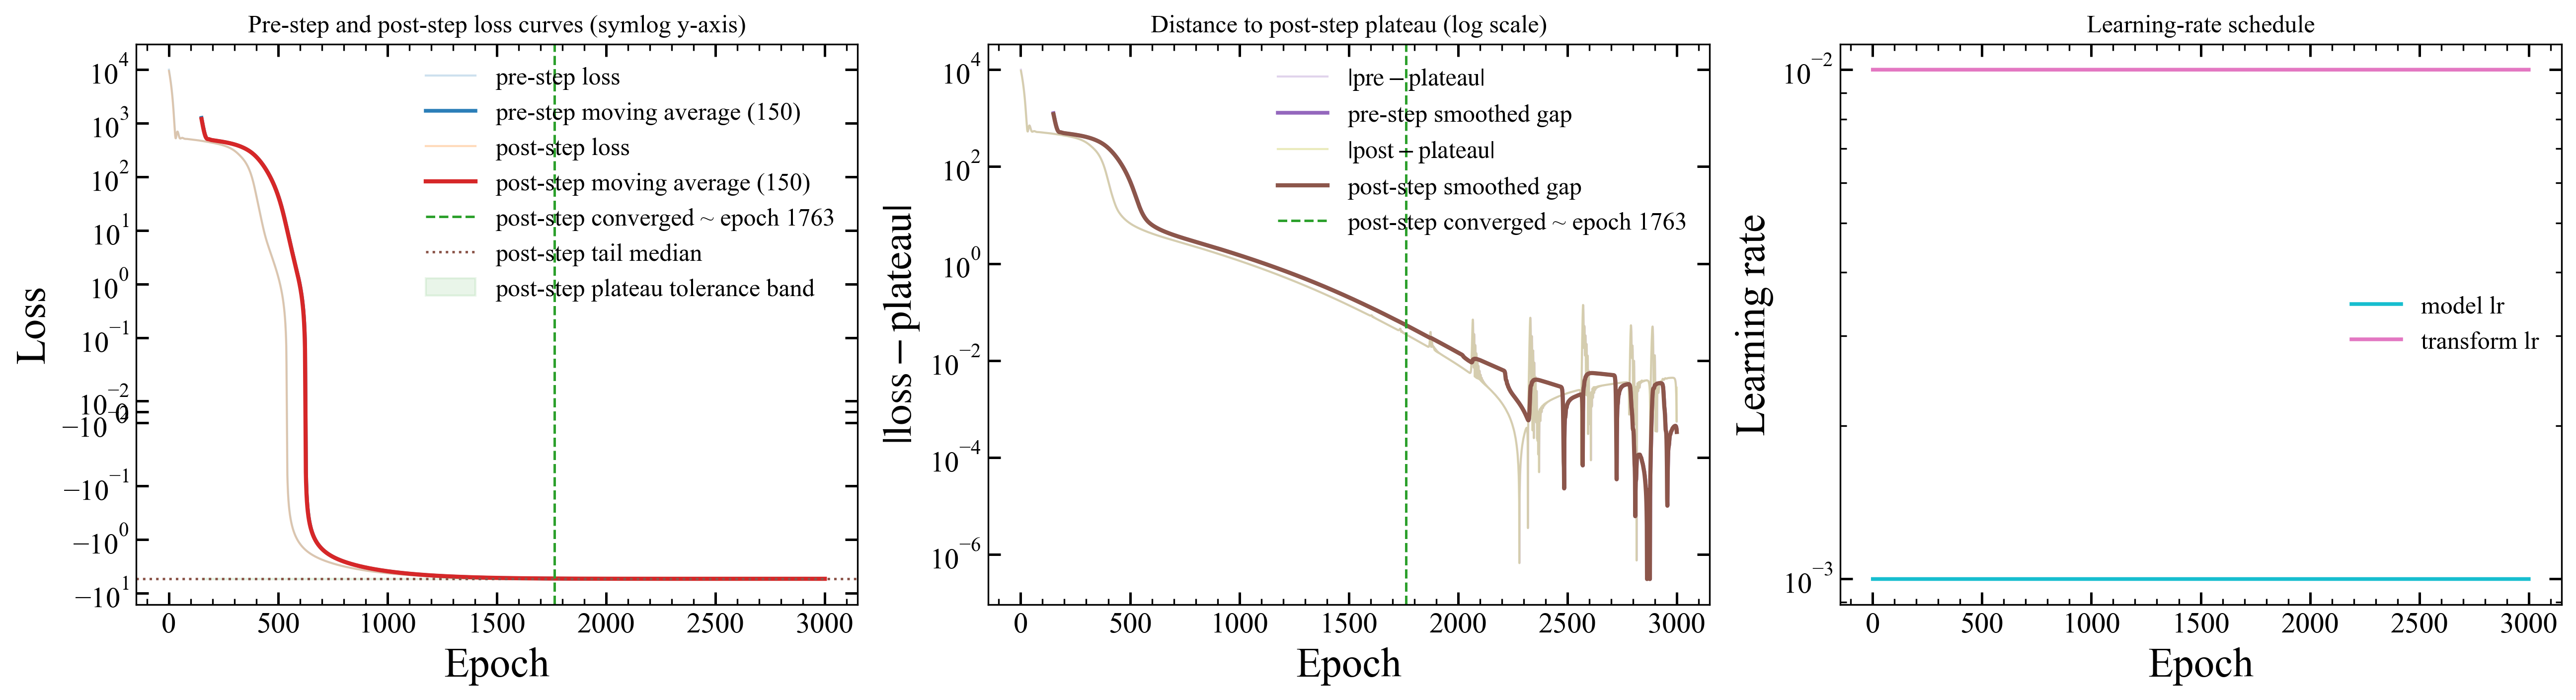

### 单次 NSA 训练的数据坍缩预览

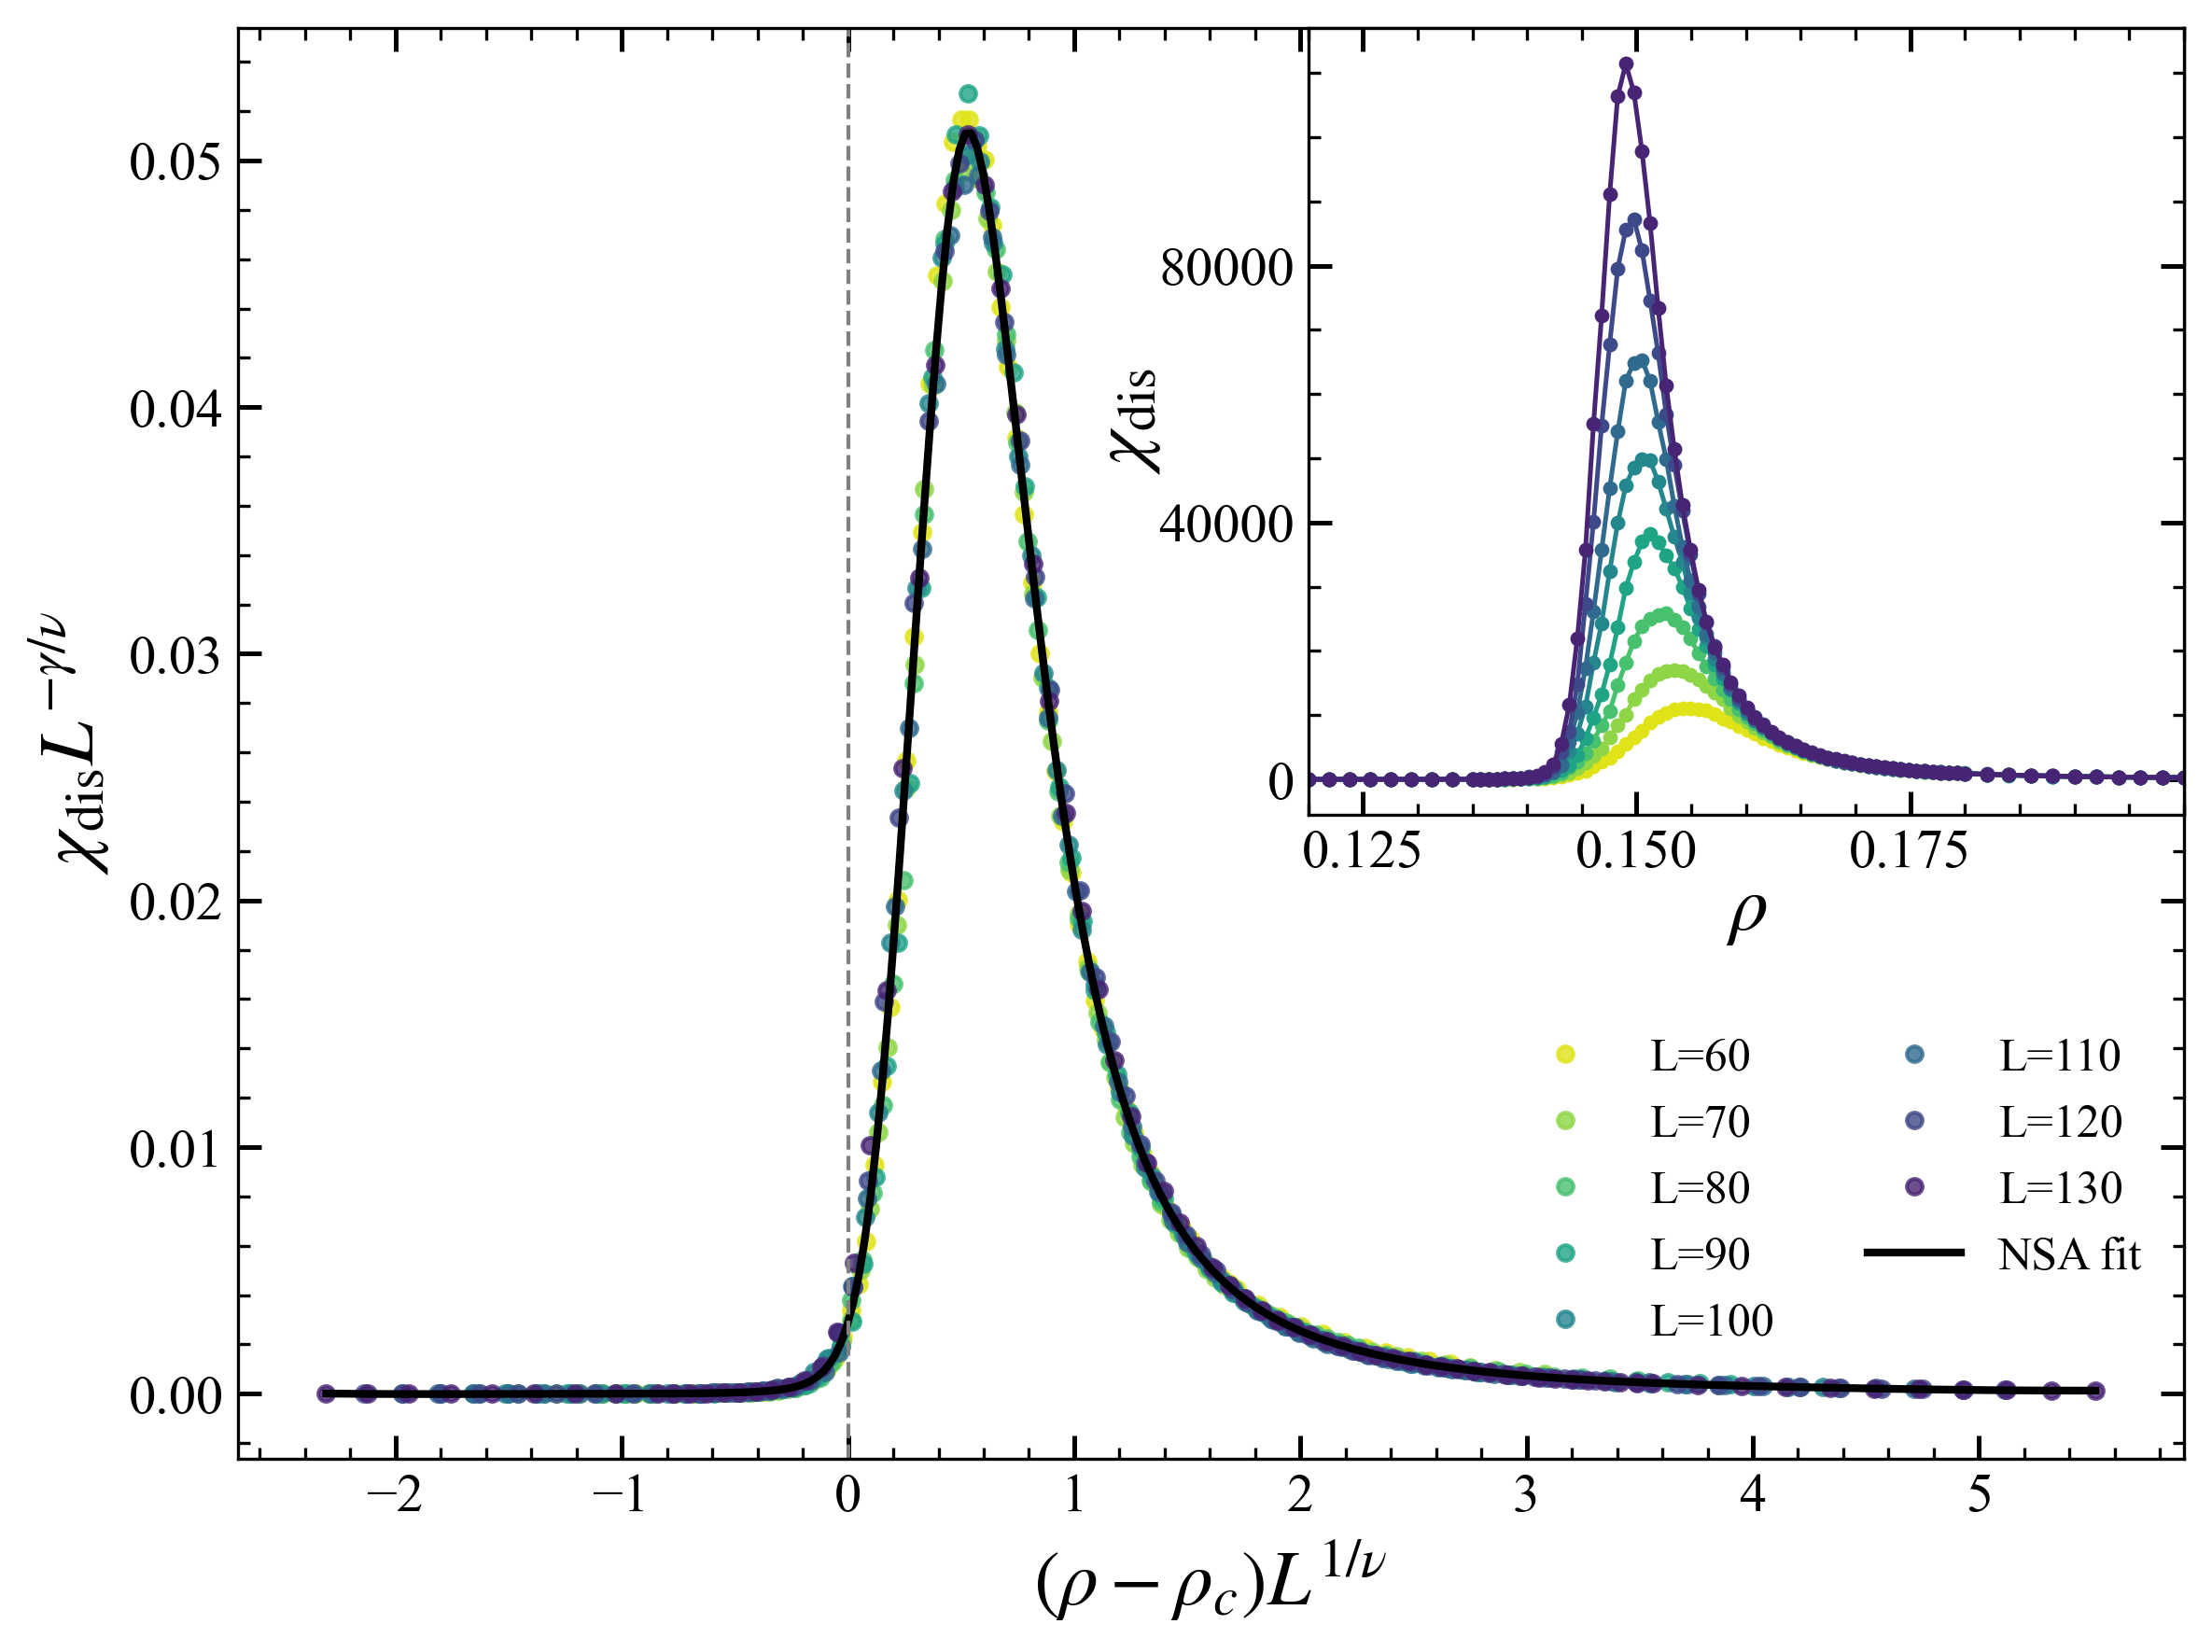

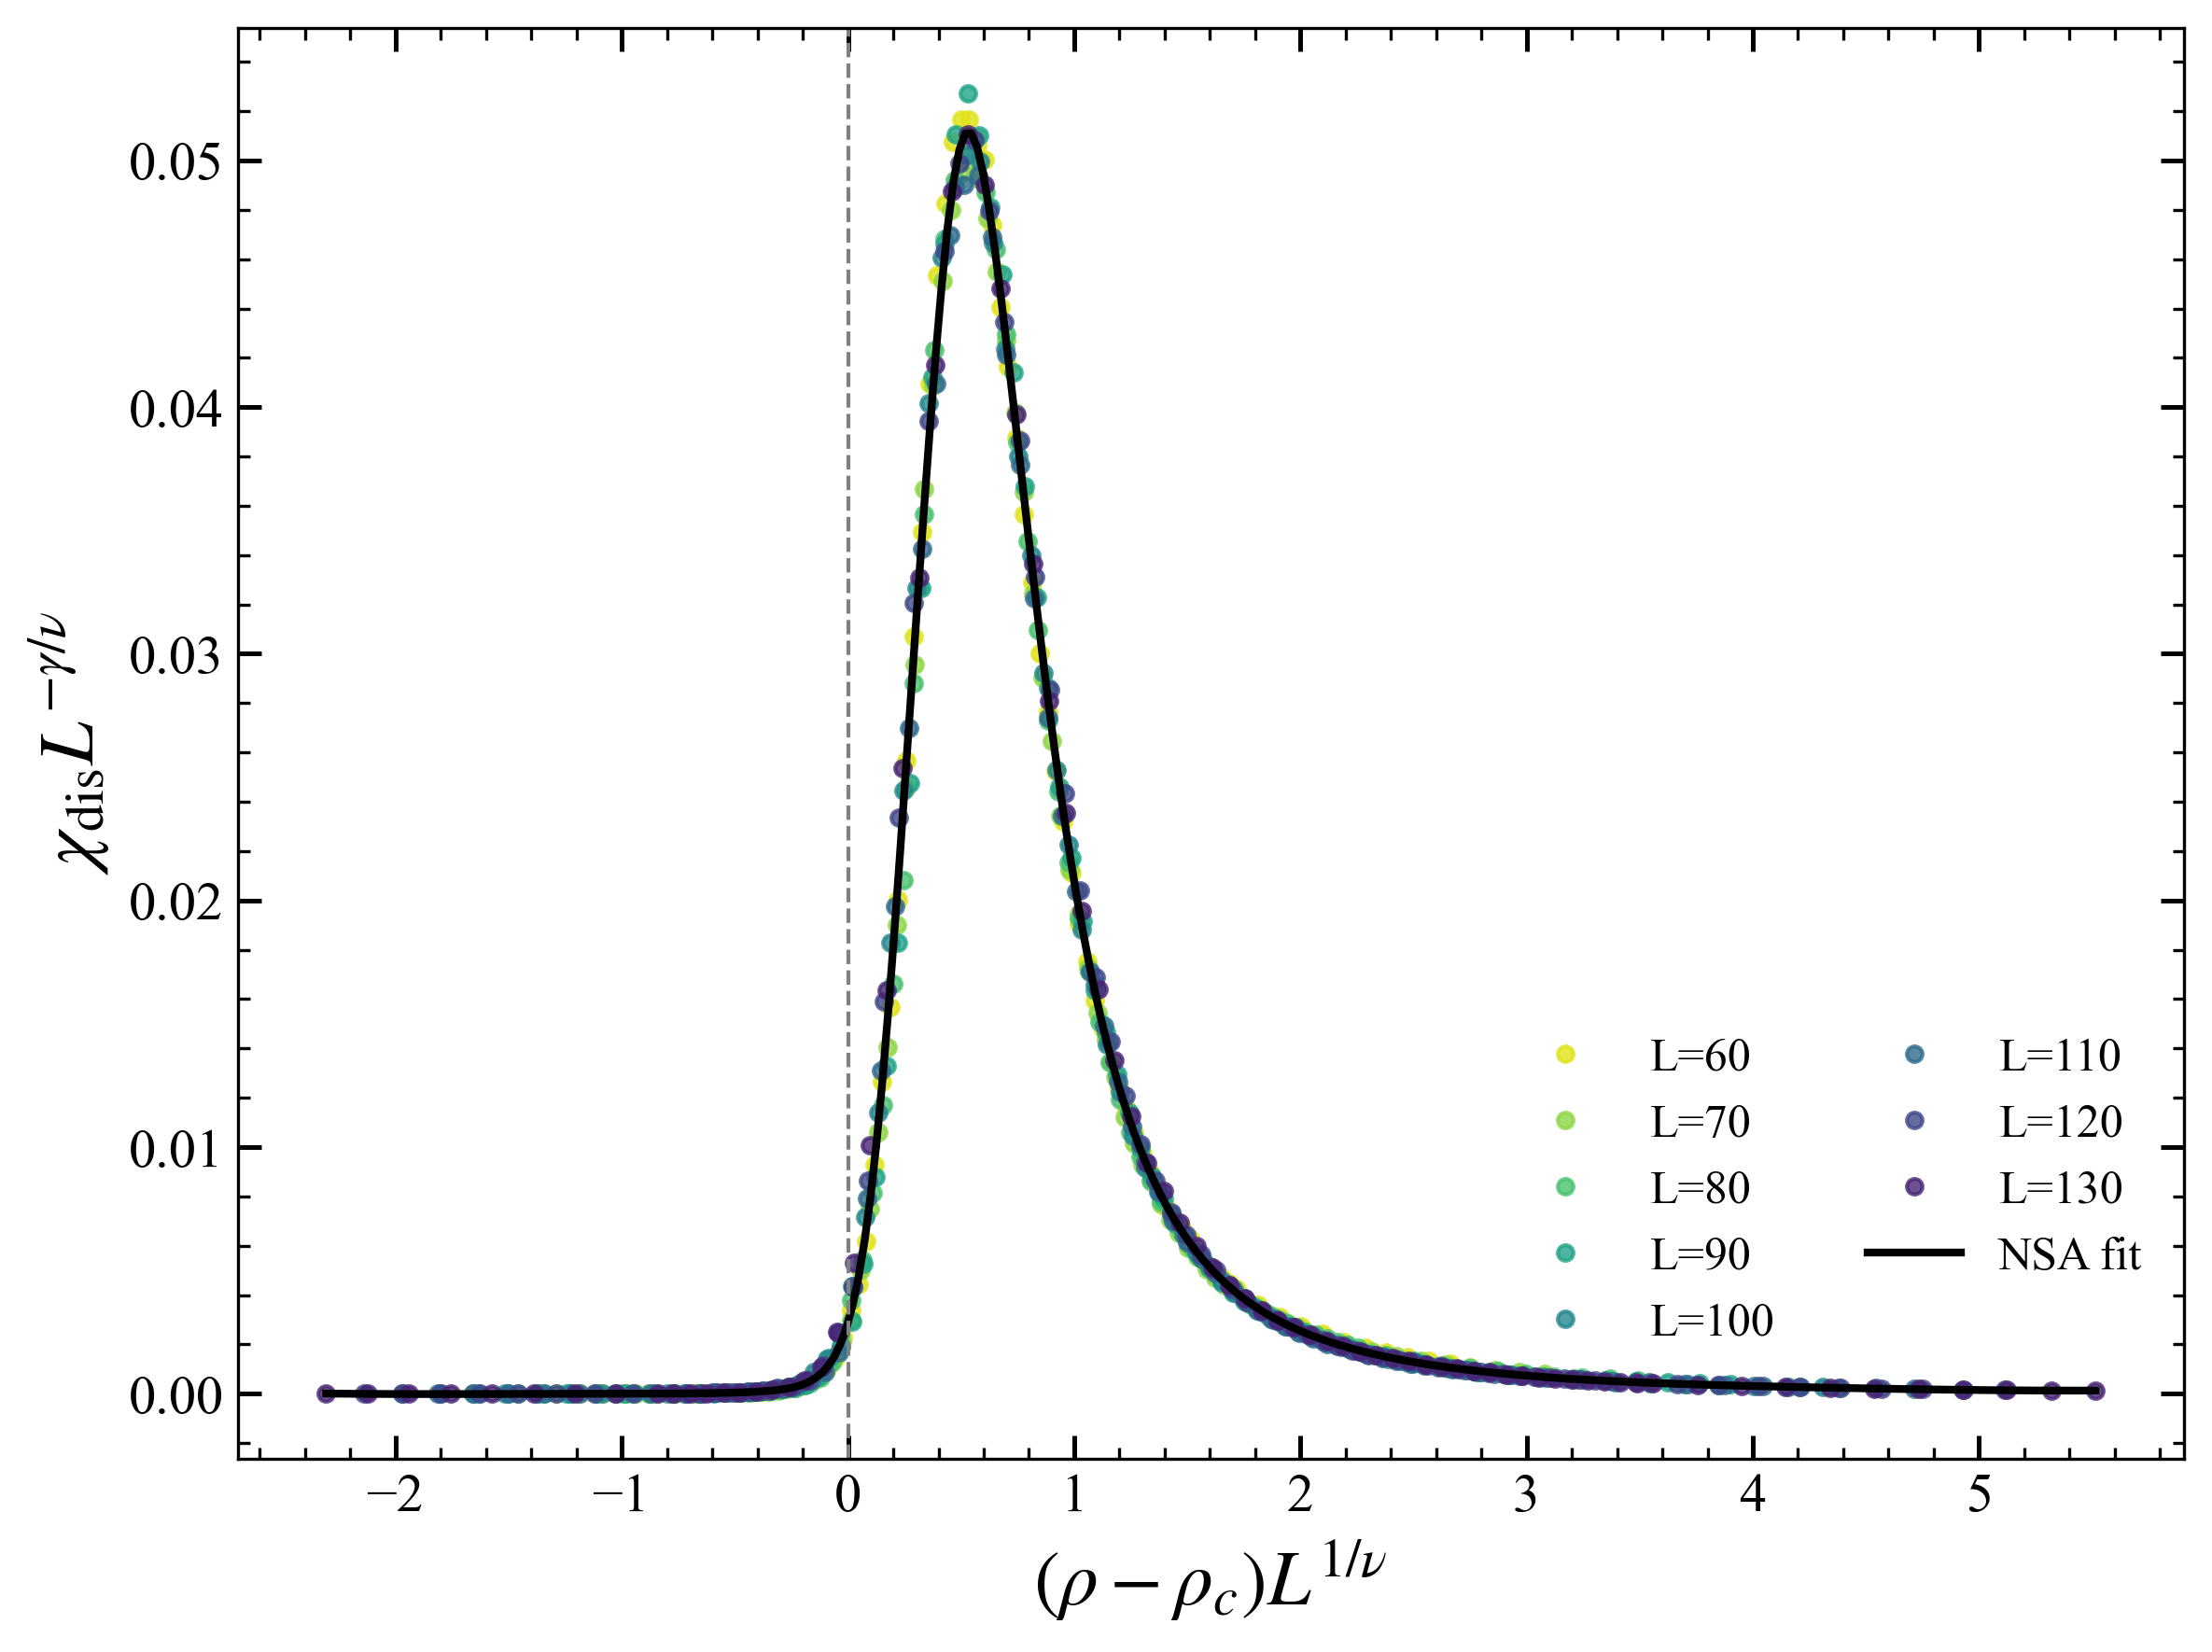

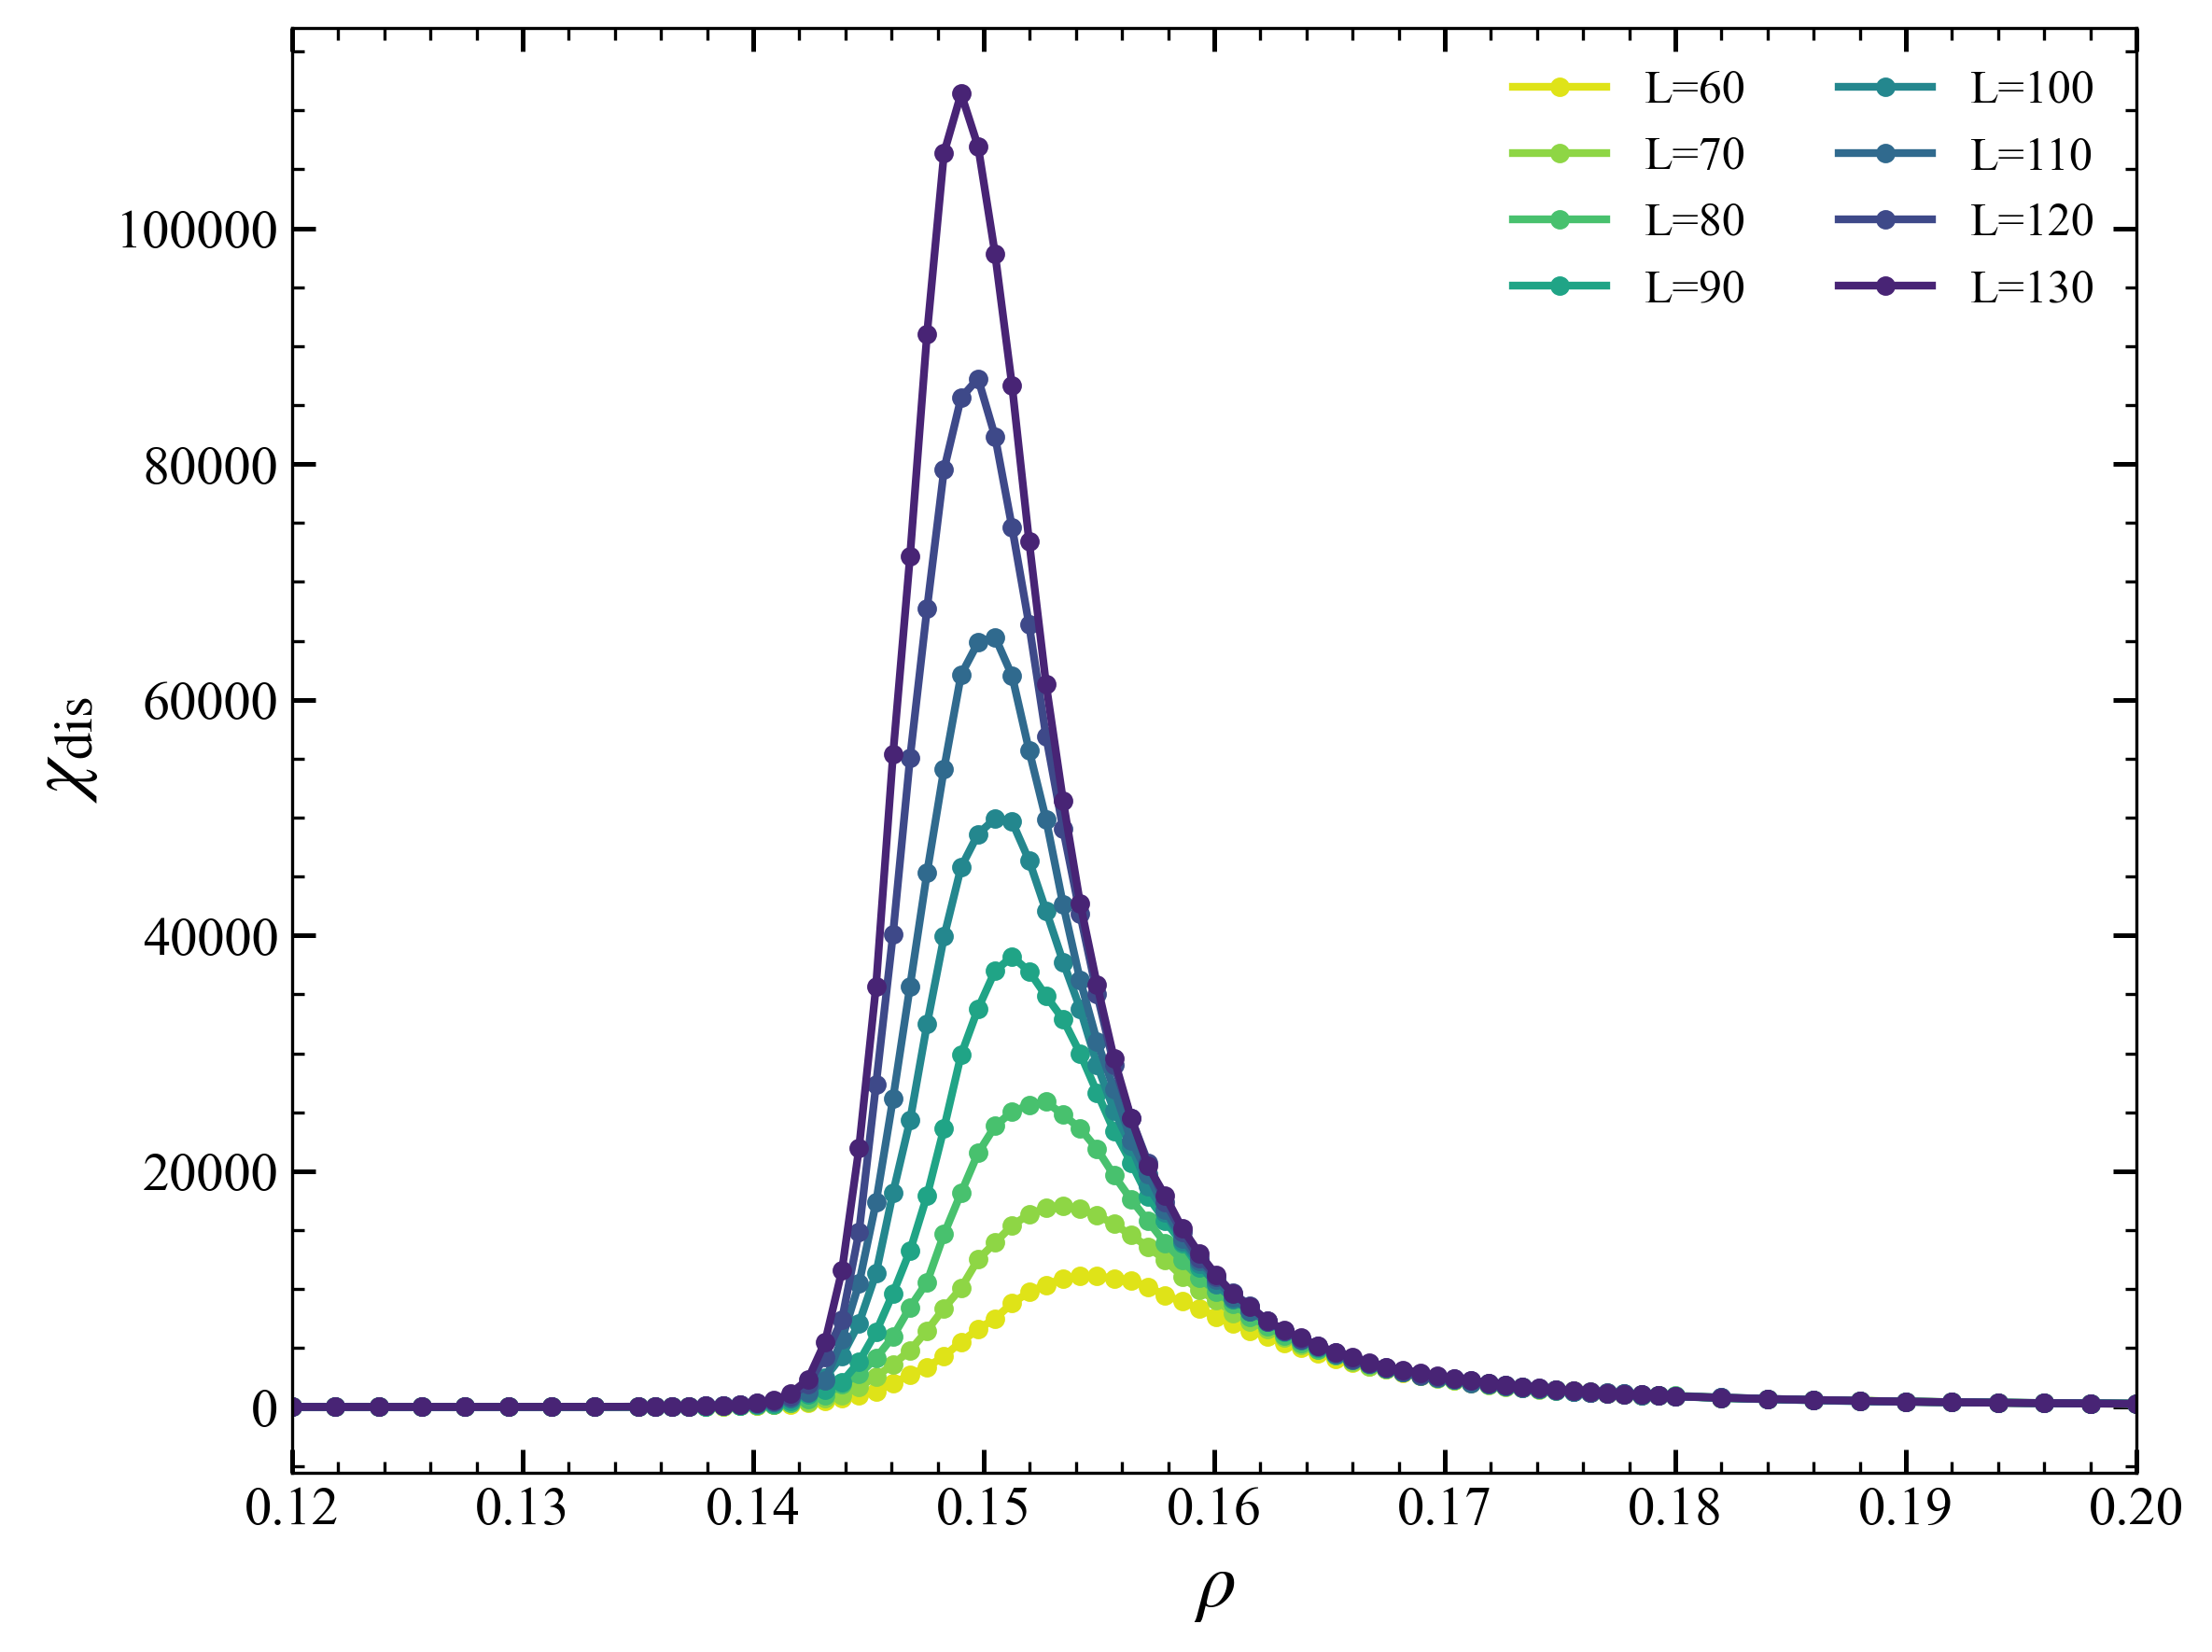

In [12]:
single_preview_results = run_single_preview()

## Full fit and bootstrap

确认单次预览效果后，再运行完整 multi-start 拟合与非参数 bootstrap 误差估计。

## chi_dis 完整拟合与 bootstrap

{'fit_window': (0.12, 0.2),
 'plot_window': (0.12, 0.2),
 'n_fit_points': 640,
 'sizes': [60, 70, 80, 90, 100, 110, 120, 130],
 'bootstrap_mode': 'nonparametric resampling of disorder-level <|m|>_th',
 'full_fit_epochs': 3000,
 'full_fit_starts': 3,
 'bootstrap_repeats': 500,
 'bootstrap_fit_epochs': 3000,
 'bootstrap_fit_starts': 2,
 'training_config': {'model_lr': 0.001,
  'transform_lr': 0.01,
  'mlp_hidden_sizes': [16, 16, 16, 16],
  'loss_mode': 'gaussian_nll',
  'use_step_lr_decay': False,
  'lr_decay_gamma': 0.5,
  'lr_decay_step_size': None,
  'full_fit_epochs': 3000,
  'full_fit_starts': 3,
  'bootstrap_repeats': 500,
  'bootstrap_fit_epochs': 3000,
  'bootstrap_fit_starts': 2,
  'preview_fit_epochs': None}}

chi_dis fit 1/3:   0%|          | 0/3000 [00:00<?, ?it/s]

chi_dis fit 2/3:   0%|          | 0/3000 [00:00<?, ?it/s]

chi_dis fit 3/3:   0%|          | 0/3000 [00:00<?, ?it/s]

...

### NSA Cache

{'cache_source': 'recomputed',
 'cache_file': 'D:\\KCM\\data\\MVS-MCMC\\nsa-chi-best-fit-chi_dis-d=3-cache.pt',
 'cache_signature': '507c4fcfca9d9e160825b2d58d6844170c46d9368ba389f3f941e95907df6723',
 'message': 'No NSA cache file was found, so a fresh fit will be computed. Saved the refreshed cache to D:\\KCM\\data\\MVS-MCMC\\nsa-chi-best-fit-chi_dis-d=3-cache.pt.',
 'cache_created_at_utc': '2026-04-02T00:43:29.091077+00:00'}

### Multi-start results

,trial_id,seed,rho_c,inv_nu,nu,ratio,physical,rmse,r2,signed_ratio,plateau_epoch,final_training_loss
0,3,1236,0.143615,0.941408,1.062239,2.998478,3.185100,0.009707,0.998893,-2.998478,967,-5.389675
1,1,1234,0.143596,0.941482,1.062155,2.998657,3.185039,0.009873,0.998855,-2.998657,1720,-5.378387
2,2,1235,0.143617,0.941841,1.061750,2.998980,3.184168,0.009932,0.998841,-2.998980,1449,-5.377977


### Full-fit trial loss histories

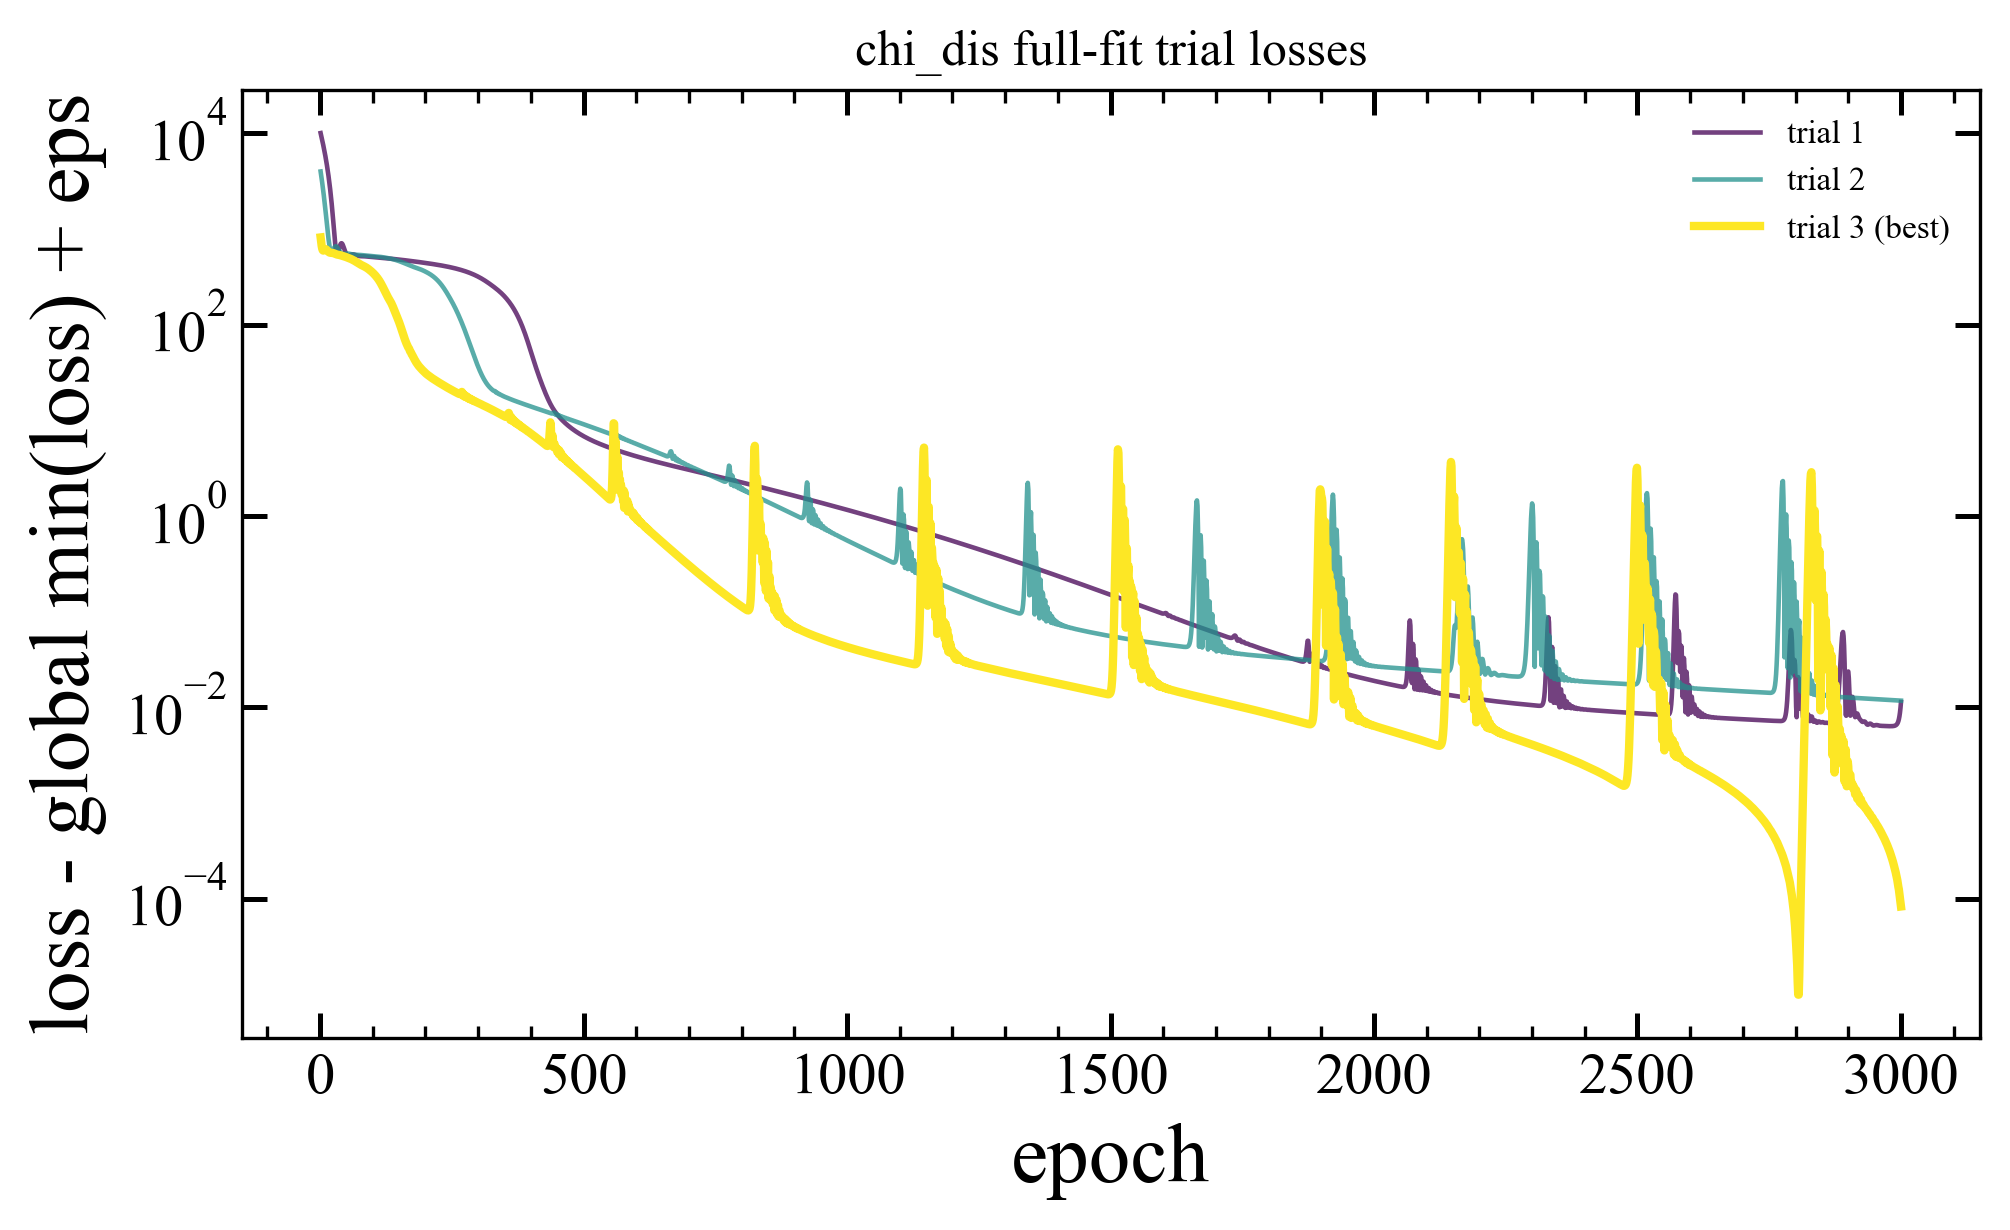

{'best_trial_id': 3,
 'estimated_plateau_epoch': 967,
 'raw_final_loss': -5.389674663543701,
 'raw_min_loss': -5.3897480964660645,
 'log_plot_baseline': -5.3897480964660645}

### Bootstrap statistics

,rho_c,inv_nu,nu,ratio,physical,rmse,r2
mean,0.143583,0.938516,1.06556,2.995271,3.191573,0.012277,0.998222
std,0.000060,0.006263,0.00718,0.011266,0.012985,0.000642,0.000185


### Academic-style Estimates

- $\rho_c = 0.143615(60)$
- $1/\nu = 0.9414(63)$
- $\gamma/\nu = 2.998(11)$
- $\gamma = 3.185(13)$
- $\nu = 1.0622(72)$
- $\mathrm{RMSE} = 0.00971(64)$
- $R^2 = 0.998893 +/- 0.000185$

### Summary Table

,$\rho_c$,$1/\nu$,$\nu$,\gamma/\nu,\gamma,RMSE,$R^2$,sizes,n_points,bootstrap_repeats
0,0.143615(60),0.9414(63),1.0622(72),2.998(11),3.185(13),0.00971(64),0.998893 +/- 0.000185,"60,70,80,90,100,110,120,130",640,500


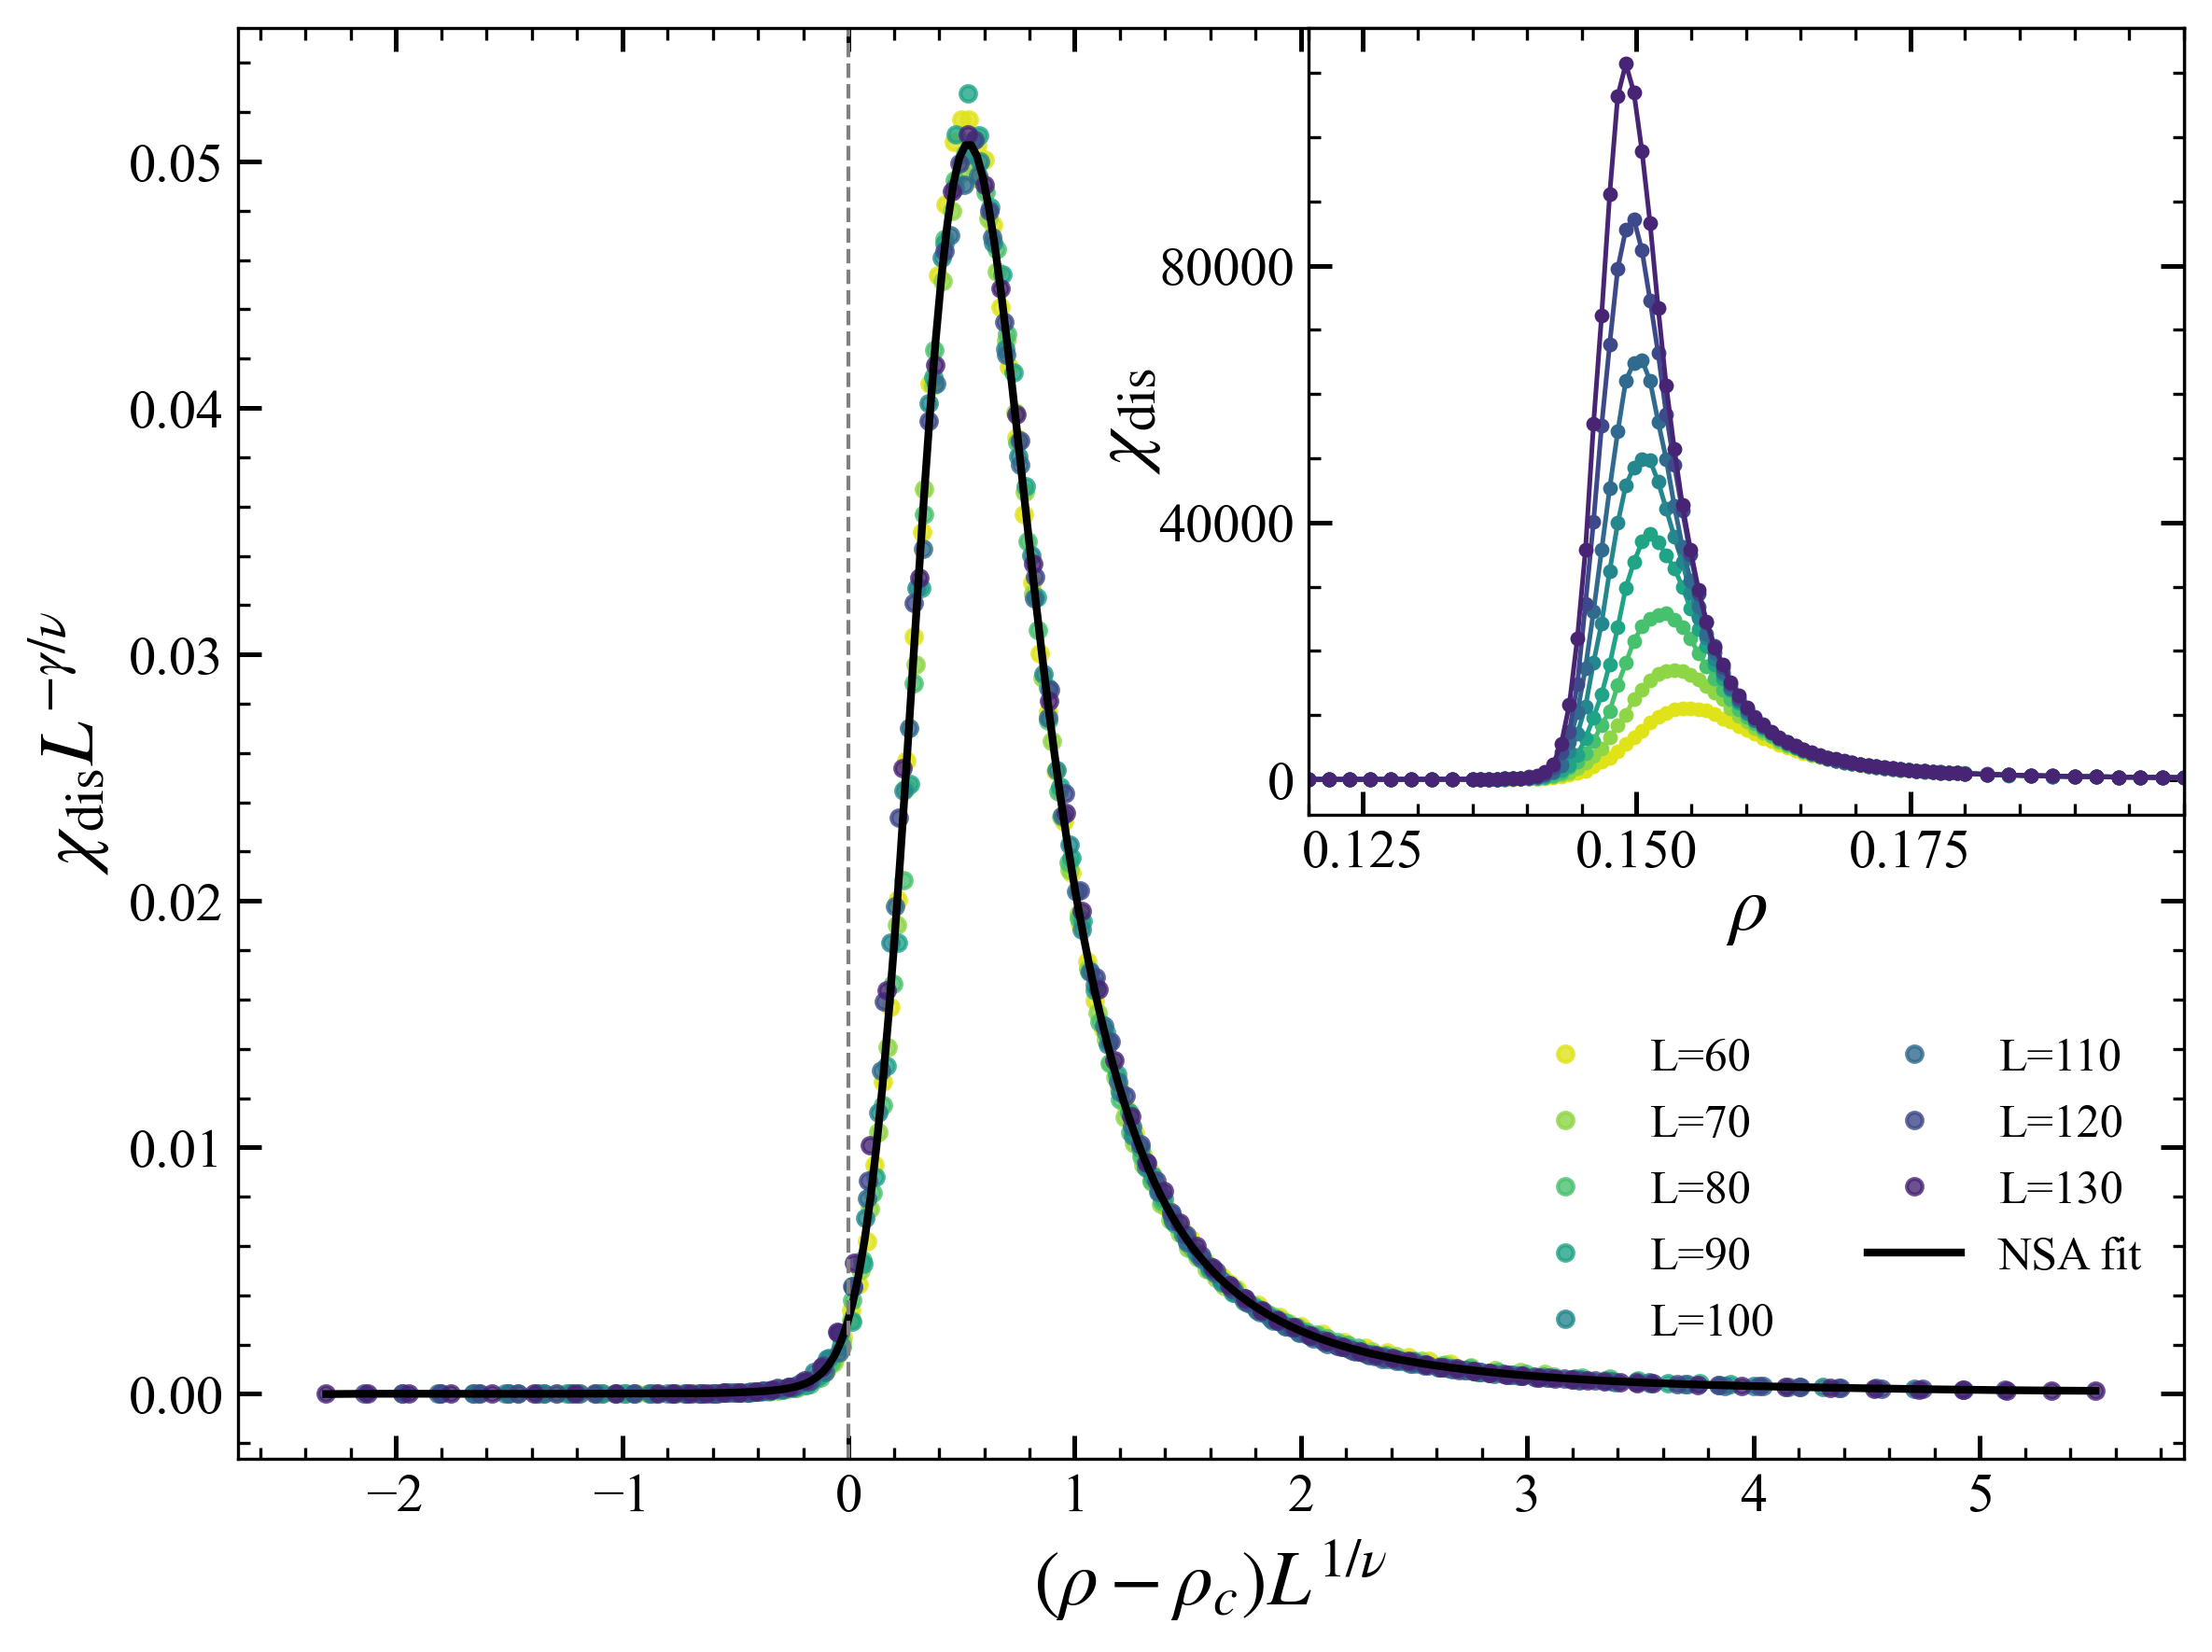

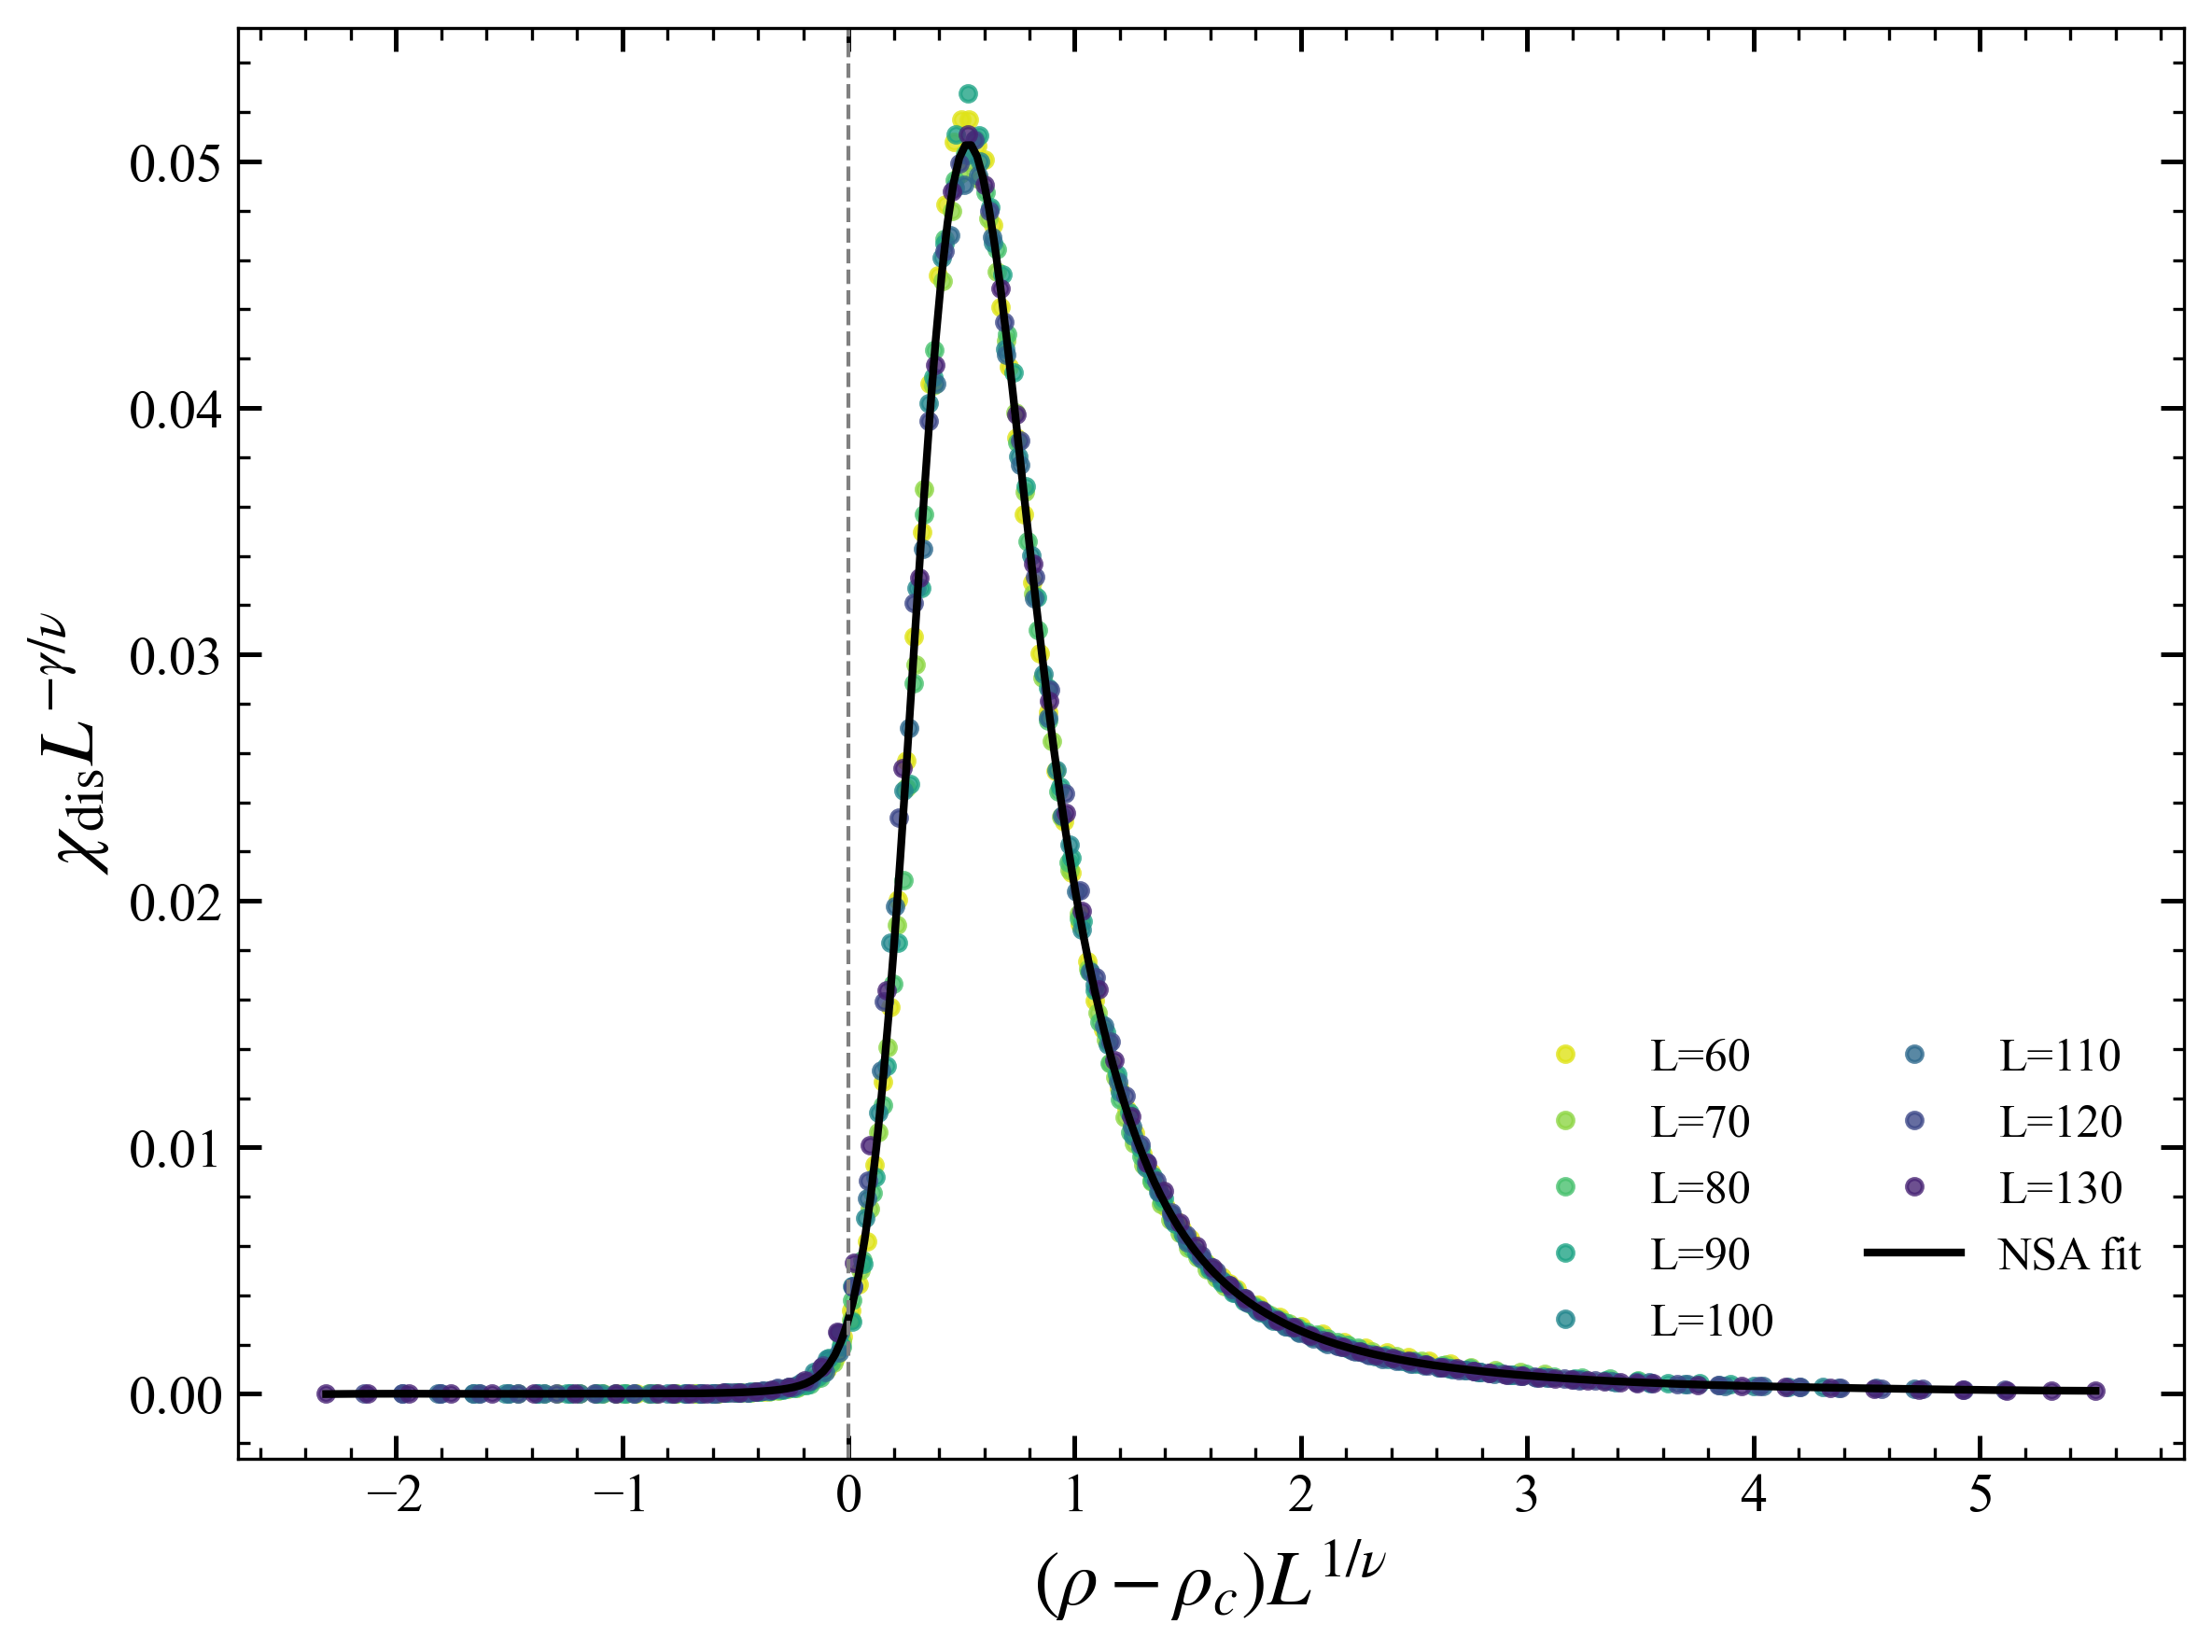

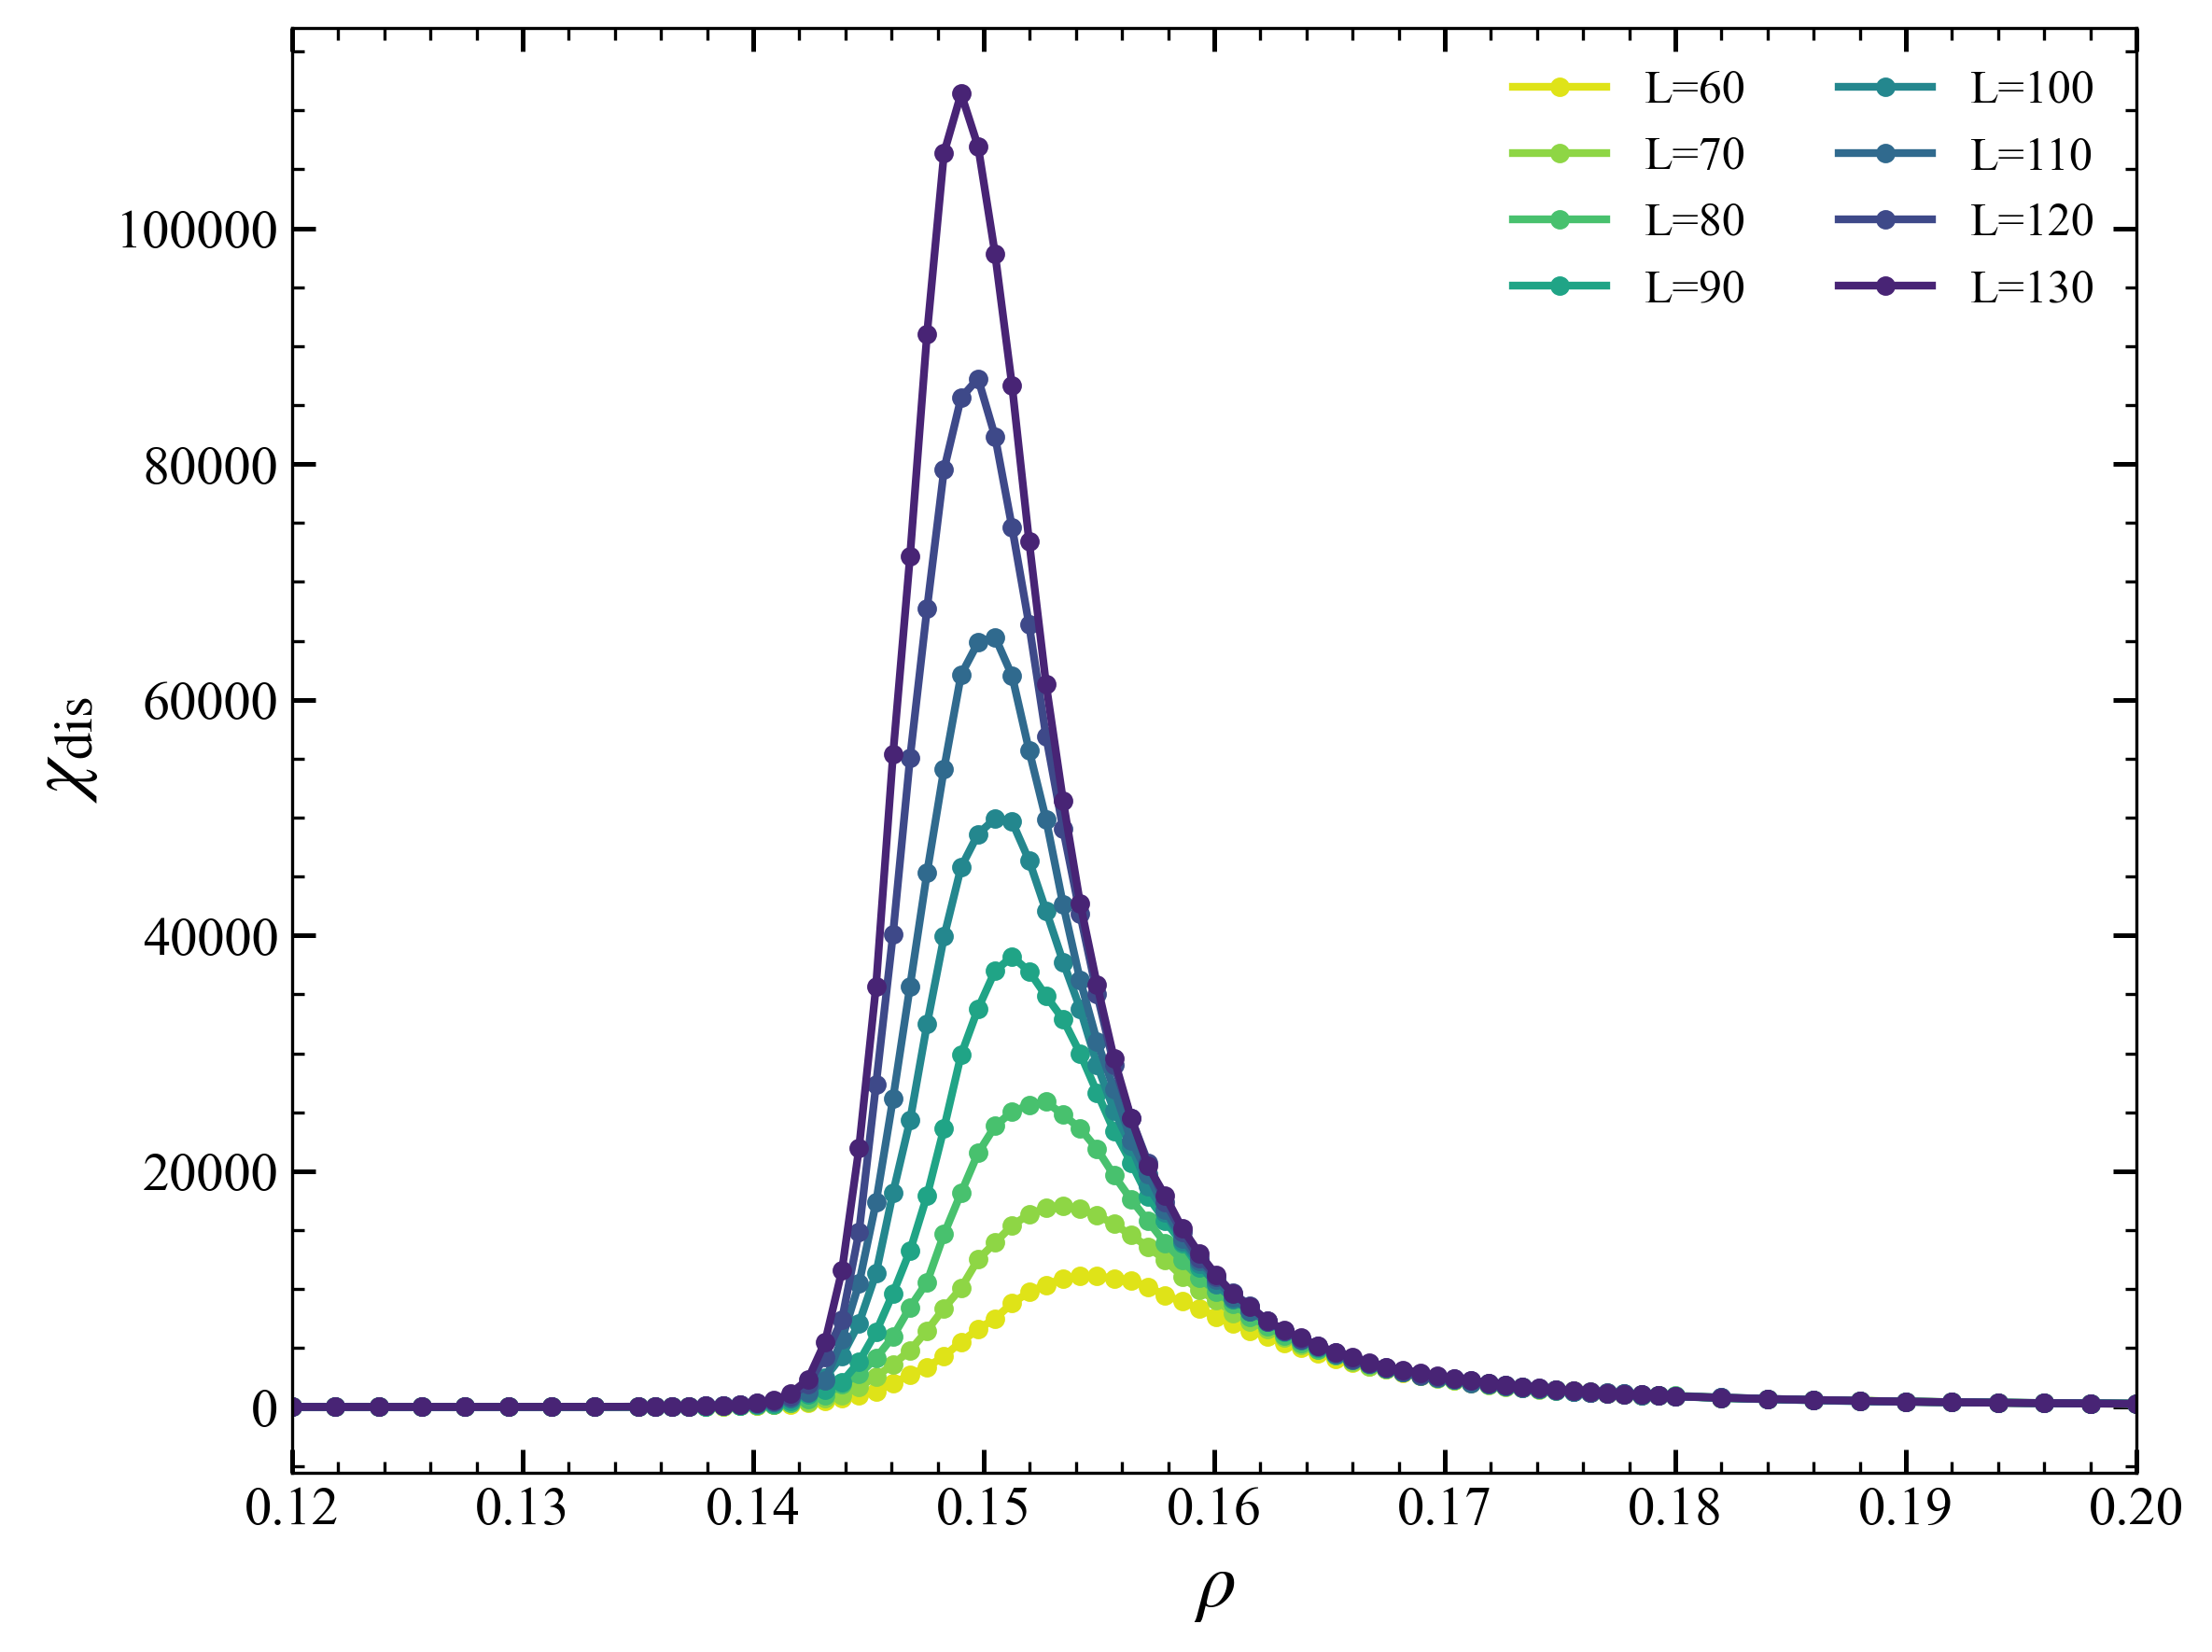

## Final summary

,observable,rho_window,rho_c,1/nu,nu,ratio,physical,RMSE,R^2,bootstrap_repeats
0,chi_dis,"[0.120000, 0.200000]",0.143615(60),0.9414(63),1.0622(72),2.998(11),3.185(13),0.00971(64),0.998893 +/- 0.000185,500


In [13]:
full_analysis_results, summary_df, summary_display = run_full_analysis(single_preview_results)